# 4 -- Definición, Entrenamiento y Evaluación del modelo LSTM baseline — Dataset FDIC RIS

Antes de realizar el modelo hibrido, el cual contiene, a parte de las caracteristicas temporales, caracteristicas relacionales, definimos un modelo base simple el cual nos servira como punto de partida ante los resultados que obtendremos, para validar de esta forma la hipotesis central del TFM, la cual establece que si los datos (embeddings) relacionales son un factor determinante o la inclusión de estos en el estudio de quiebras bancarias junto con los datos temporales economicos no suponene una mejora respecto a una vision más conservadora y tradicional.

### Limitación de las Redes Feedforward y Formalización de Redes Recurrentes (RNN)

Las arquitecturas de redes neuronales de alimentación hacia adelante (feedforward) asumen independencia estadística entre las muestras de entrada. Sea una secuencia de observaciones $X = (x_1, x_2, \dots, x_T)$, donde cada $x_t \in \mathbb{R}^{d_{in}}$. Una red feedforward procesa cada $x_t$ de forma aislada, lo que impide la captura de dependencias temporales u ordenamientos secuenciales donde el estado actual condicione los estados futuros ($P(x_t \mid x_{t-1}, x_{t-2}, \dots)$).Las Redes Neuronales Recurrentes (RNN) introducen un mecanismo de persistencia de información mediante un lazo de retroalimentación en la capa oculta. El estado oculto $h_t \in \mathbb{R}^{d_h}$ actúa como un descriptor dinámico de la memoria histórica del sistema, actualizándose recursivamente en cada paso temporal $t$ mediante la siguiente ecuación en diferencias:
$$
h_t = \sigma(W_h h_{t-1} + W_x x_t + b)
$$

Donde $W_h \in \mathbb{R}^{d_h \times d_h}$ es la matriz de pesos de la transición de estado, $W_x \in \mathbb{R}^{d_h \times d_{in}}$ es la matriz de pesos de la entrada, $b \in \mathbb{R}^{d_h}$ es el vector de sesgo y $\sigma$ es una función de activación no lineal (típicamente $\tanh$ o la función sigmoide).

La optimización de una RNN se realiza mediante el algoritmo de Retropropagación a través del Tiempo (Backpropagation Through Time o BPTT). Sea $\mathcal{L}$ la pérdida total de la secuencia. Para calcular el gradiente de la pérdida respecto a la matriz de pesos recurrentes $W_h$, se aplica la regla de la cadena, requiriendo el producto de matrices Jacobianas para evaluar la dependencia de largo alcance entre el estado en el tiempo $t$ y un estado previo en el tiempo $\tau$ (donde $\tau \ll t$):
$$
\frac{\partial h_t}{\partial h_{\tau}} = \prod_{k=\tau+1}^{t} \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=\tau+1}^{t} \text{diag}\left(\sigma'(a_k)\right) W_h^T
$$

Donde $a_k = W_h h_{k-1} + W_x x_k + b$. Por tanto si el radio espectral de la matriz de pesos $W_h$ es menor que la unidad , rho(W_h) < 1$, y dado que la derivada de las funciones no lineales de activación, como por ejemplo $\tanh$, está acotada en $(0, 1]$, los términos de la multiplicación geométrica convergen exponencialmente a cero a medida que la distancia temporal $t - \tau$ aumenta. Este fenómeno, conocido como el desvanecimiento del gradiente, anula la señal de error para componentes temporales lejanas, limitando la capacidad de la RNN para aprender dependencias de largo plazo. Inversamente, si $\rho(W_h) > 1$, los gradientes crecen exponencialmente, provocando el fenómeno de gradiente explosivo.

### Arquitectura Long Short-Term Memory (LSTM)

Introducida por Hochreiter y Schmidhuber (1997), la arquitectura LSTM resuelve la atenuación del gradiente sustituyendo la unidad recurrente simple por una celda de memoria compleja regulada por compuertas (gates).La celda mantiene dos estados vectoriales concurrentes:

- Estado de Celda ($c_t \in \mathbb{R}^{d_h}$): Representa la memoria intrínseca de largo plazo. Modulado por operaciones aditivas lineales que mitigan la degradación del gradiente.

- Estado Oculto ($h_t \in \mathbb{R}^{d_h}$): Representa la memoria de corto plazo y constituye la salida accesible de la celda en el paso $t$.

Sea $[h_{t-1}, x_t] \in \mathbb{R}^{d_h + d_{in}}$ la concatenación del estado oculto previo y la entrada actual. El flujo de información se gobierna por el siguiente sistema de ecuaciones lineales y no lineales:
$$\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}$$

Donde $W_f, W_i, W_c, W_o \in \mathbb{R}^{d_h \times (d_h + d_{in})}$, $b_f, b_i, b_c, b_o \in \mathbb{R}^{d_h}$, $\sigma$ es la función sigmoide logística que proyecta al rango abierto $(0, 1)$, $\tanh$ proyecta al rango $(-1, 1)$, y $\odot$ denota el producto de Hadamard (operación elemento a elemento). El mecanismo crítico de la LSTM radica en la actualización del estado de celda: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. Al calcular la derivada parcial del estado de celda actual respecto al anterior se obtiene:
$$
\frac{\partial c_t}{\partial c_{t-1}} = f_t
$$

Si la compuerta de olvido se activa cerca de la unidad ($f_t \approx 1$), el gradiente del error puede retropropagarse de manera lineal y aditiva directamente a través del tiempo sin sufrir una atenuación exponencial. Esto constituye el denominado Carrusel de Error de Gradiente Constante (Constant Error Carousel).

Las diferentes compuertas poseen una funciónalidad especifica:

- Compuerta de Olvido ($f_t$): Evalúa la relevancia del contexto pasado. Si un elemento $f_{t,j} \to 0$, la información histórica correspondiente en $c_{t-1,j}$ se elimina del vector de memoria por completo.

- Compuerta de Entrada ($i_t$) y Candidato ($\tilde{c}_t$): El término $\tilde{c}_t$ genera nuevas características candidatas escaladas no linealmente. La compuerta $i_t$ actúa como un filtro de cuantificación que determina la magnitud de la incorporación de estas nuevas características al estado de memoria.

- Compuerta de Salida ($o_t$): Filtra la memoria consolidada de la celda ($c_t$) tras pasar por una normalización $\tanh$, abstrayendo únicamente la información pertinente para generar la respuesta externa del modelo $h_t$ en dicho paso temporal.

En el análisis de series temporales de riesgo sistémico o financiero, cada paso temporal $t$ se alimenta con un vector de características proyectadas $x_t = e_{\text{projected}} \in \mathbb{R}^{d_{model}}$, el cual sintetiza la posición contable, métricas de liquidez, solvencia y balance de una entidad bancaria en un trimestre específico.La incorporación de la LSTM en este dominio ofrece ventajas estructurales fundamentadas:

- El uso del filtro estructural via $f_t$ permite discriminar y suprimir variaciones transitorias de alta frecuencia (ruido contable estacional) de las tendencias macroeconómicas o de deterioro latente de largo plazo.

- El modelado no lineal hace que las interacciones complejas entre variables macro (e.g., tasas de interés) y micro (e.g., tasa de morosidad) se aproximanen mediante las composiciones afines de las compuertas.

- Ventanas Temporales Acotadas: Para secuencias de baja frecuencia (v.g., 4 trimestres), la memoria celular estabiliza la representación vectorial del perfil del banco a lo largo del año fiscal completo sin pérdida de resolución temporal.

En nuestro caso, para modelar la dinámica temporal de las entidades financieras, se dispone de secuencias compactas de longitud fija $T=4$, representadas por un tensor de activaciones 

$$
X^{i} = (x_{1}^{(i)}, x_{2}^{(i)}, x_{3}^{(i)}, x_{4}^{(i)})^\top \in \mathbb{R}^{4 \times d}
$$
, donde cada $x_{t}^{(i)}$ codifica las variables macroeconómicas y contables de la entidad $i$ en el trimestre $t$. La naturaleza del problema exige un operador capaz de capturar la dependencia secuencial y la trayectoria evolutiva de los vectores, superando las limitaciones de los enfoques estáticos.La idoneidad de la arquitectura de Memoria a Largo Corto Plazo ($\text{LSTM}$, Long Short-Term Memory) sobre otras topologías secuenciales se fundamenta en las siguientes propiedades estructurales.

A diferencia de los modelos autorregresivos estáticos o de las proyecciones independientes por paso temporal, la $\text{LSTM}$ actúa como un sistema dinámico discreto no lineal parametrizado. El estado oculto final $h_4 \in \mathbb{R}^{h}$ se obtiene mediante la aplicación recursiva de una función de transición $\mathcal{F}$:

$$
h_t = \mathcal{F}(h_{t-1}, x_t; \Theta)
$$

Por expansión recursiva, el vector de características final es una composición no lineal que colapsa toda la historia de la secuencia: $h_4 = \mathcal{F}(\mathcal{F}(\mathcal{F}(\mathcal{F}(h_0, x_1), x_2), x_3), x_4)$.Esta propiedad es crucial desde la perspectiva de la teoría de alerta temprana bancaria (_Early Warning Systems_). Como determinan Cole y Gunther (1995), los procesos de insolvencia y quiebra técnica no se manifiestan como discontinuidades puntuales u observaciones aisladas en un único punto del tiempo $t=4$. Por el contrario, responden a trayectorias estocásticas de deterioro estructural crónico, caracterizadas por la degradación monótona de los ratios de adecuación de capital y la erosión progresiva de la calidad de los activos durante los trimestres $t-3, t-2$ y $t-1$. Una arquitectura carente de memoria inter-temporal realizaría la inferencia exclusivamente sobre el soporte de la distribución marginal de $x_4$, omitiendo los componentes de velocidad y aceleración de los vectores de estado financieros, los cuales albergan la mayor varianza discriminativa para la detección precoz del riesgo.

La compuerta de olvido $f_t \in (0,1)^h$ permite al modelo parametrizar de forma diferenciable la tasa de decaimiento de la información histórica, mientras que la compuerta de entrada $i_t$ modula la inyección de nuevas perturbaciones macroeconómicas.Matemáticamente, la derivada del estado de la celda final respecto a un estado anterior viene dada por la regla de la cadena:

$$
\frac{\partial c_4}{\partial c_t} = \prod_{k=t+1}^4 \frac{\partial c_k}{\partial c_{k-1}} = \prod_{k=t+1}^4 \left( f_k + \text{términos aditivos de las compuertas} \right)
$$

En una $\text{RNN}$ convencional, esta derivada involucra el producto continuado de matrices de pesos $\prod W^\top$, lo que provoca que el gradiente se desvanezca de forma exponencial si el radio espectral de la matriz es inferior a la unidad ($\rho(W) < 1$). Si bien con una longitud de secuencia acotada a $T=4$ el fenómeno del desvanecimiento del gradiente (vanishing gradient) ve mitigado su impacto asintótico, la estructura aditiva de la celda de la $\text{LSTM}$ garantiza que el gradiente fluya uniformemente hacia atrás (backpropagation through time, $\text{BPTT}$) sin sufrir atenuaciones ni explosiones numéricas artificiales induciendo una superficie de pérdida (loss landscape) más suave y propicia para la optimización basada en gradiente estocástico.

In [ ]:
# ============================================================================
# BLOQUE 1 — CARGA Y VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_tab)
# ============================================================================
#
# Modelo: LSTM Baseline (solo datos numéricos / tabulares vía TabPFN)
#
# Objetivo de este bloque: cargar embeddings_desarrollo.parquet, verificar
# su consistencia con el panel etiquetado original, y dejar un DataFrame
# único (emb_dev_labeled) listo para la construcción de secuencias del
# Bloque 2.
#
# NO se toca en ningún momento el bloque de evaluación (2022Q1-2025Q4):
# permanece reservado hasta la evaluación final del modelo ya entrenado.
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ----------- 1.0 REPRODUCIBILIDAD -----------
SEED = 42
np.random.seed(SEED)

# ----------- 1.1 RUTAS -----------
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"

EMB_DEV_PATH = EMBEDDINGS_ROOT / "emb_dev/embeddings_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"


# Carga de ambos embeddings y del panel de etiquetas para google colab
emb_dev     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_dev/embeddings_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

VERBOSE = True

# ----------- 1.2 CARGA -----------
emb_dev = pd.read_parquet(EMB_DEV_PATH)
panel_label = pd.read_parquet(PANEL_LABEL_PATH)

if VERBOSE:
    print(f"emb_dev shape     : {emb_dev.shape}")
    print(f"panel_label shape : {panel_label.shape}")

# ----------- 1.3 NORMALIZACIÓN DE TIPOS -----------
for df in [emb_dev, panel_label]:
    df["CERT"] = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.4 IDENTIFICAR COLUMNAS DE EMBEDDING -----------
META_DEV = ["CERT", "period"]
cols_emb = [c for c in emb_dev.columns if c not in META_DEV]

assert len(cols_emb) == 192, (
    f"Se esperaban 192 dimensiones de embedding (espacio latente de "
    f"TabPFN v2.6), se encontraron {len(cols_emb)}."
)

# ----------- 1.5 UNIR ETIQUETA failed DESDE panel_tabular_labeled -----------
# Se usa la MISMA fuente de etiqueta para garantizar comparabilidad histórica de los números.
# how='left' + fillna(0): un CERT/period sin entrada en panel_label se
# asume no-quiebra (consistente con el procesamiento ya usado en el
# documento de extracción de TabPFN: panel['failed'].fillna(0).astype(int)).

emb_dev_labeled = emb_dev.merge(
    panel_label[["CERT", "period", "failed"]],
    on=["CERT", "period"],
    how="left",
)
n_sin_etiqueta = emb_dev_labeled["failed"].isna().sum()
emb_dev_labeled["failed"] = emb_dev_labeled["failed"].fillna(0).astype(int)

# ----------- 1.6 VERIFICACIÓN DE INVARIANTES -----------
n_obs = len(emb_dev_labeled)
n_pos = int(emb_dev_labeled["failed"].sum())
n_nan_emb = emb_dev_labeled[cols_emb].isna().sum().sum()
n_periodos = emb_dev_labeled["period"].nunique()
periodos_sorted = sorted(emb_dev_labeled["period"].unique())

assert n_nan_emb == 0, f"NaN en columnas de embedding: {n_nan_emb}"
assert n_periodos == 23, (
    f"Periodos esperados: 23 (2016Q2→2021Q4, 2016Q1 omitido por falta de "
    f"contexto TabPFN), obtenidos: {n_periodos}"
)
assert periodos_sorted[0] == "2016Q2", f"Primer periodo inesperado: {periodos_sorted[0]}"
assert periodos_sorted[-1] == "2021Q4", f"Último periodo inesperado: {periodos_sorted[-1]}"

# Verificación cruzada: el nº de positivos debe ser compatible con los 70
# positivos documentados para el bloque desarrollo completo (2016Q1-2021Q4,
# 24 trimestres). Al faltar 2016Q1 en el embedding, se espera un nº de
# positivos ligeramente MENOR o IGUAL a 70 (los de 2016Q1 no tienen
# embedding y por tanto no pueden entrar en ninguna secuencia).
if VERBOSE:
    print("\n" + "=" * 60)
    print("BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_tab)")
    print("=" * 60)
    print(f"Observaciones totales        : {n_obs:,}")
    print(f"Positivos (failed=1)         : {n_pos}")
    print(f"Tasa de positivos            : {n_pos/n_obs:.6f}")
    print(f"Filas sin match en panel_label (asumidas failed=0) : {n_sin_etiqueta}")
    print(f"Dimensión de embedding        : {len(cols_emb)}")
    print(f"NaN en embeddings             : {n_nan_emb}")
    print(f"Periodos                      : {n_periodos}  ({periodos_sorted[0]} → {periodos_sorted[-1]})")
    print(f"Entidades (CERT) únicas       : {emb_dev_labeled['CERT'].nunique():,}")
    print("=" * 60)
    print(
        "\nNOTA: si n_pos < 70, la diferencia corresponde a positivos de "
        "2016Q1, que no tiene embedding de TabPFN (sin contexto previo) y "
        "por tanto no puede participar en ninguna secuencia de longitud "
        "T=4 cuyo period_end sea posterior a 2016Q1."
    )

emb_dev shape     : (125575, 194)
panel_label shape : (206129, 3)

BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_tab)
Observaciones totales        : 125,575
Positivos (failed=1)         : 63
Tasa de positivos            : 0.000502
Filas sin match en panel_label (asumidas failed=0) : 0
Dimensión de embedding        : 192
NaN en embeddings             : 0
Periodos                      : 23  (2016Q2 → 2021Q4)
Entidades (CERT) únicas       : 6,176

NOTA: si n_pos < 70, la diferencia corresponde a positivos de 2016Q1, que no tiene embedding de TabPFN (sin contexto previo) y por tanto no puede participar en ninguna secuencia de longitud T=4 cuyo period_end sea posterior a 2016Q1.


La red $\text{LSTM}$ no procesa observaciones distribuidas de manera idéntica e independiente, sino trayectorias estocásticas discretas. Sea $\mathcal{E}_i$ la secuencia cronológica indexada de representaciones vectoriales para una entidad financiera $i$, definida como:

$$
\mathcal{E}_i = \left( x_{t\_1}^{(i)}, x_{t\_2}^{(i)}, \dots, x_{t\_K}^{(i)} \right), \quad x_{t\_m}^{(i)} \in \mathbb{R}^d
$$

donde $K$ es el número total de periodos de presencia activa de la entidad en el registro histórico y $t_m \in \mathbb{N}$ denota el índice del trimestre. La extracción de secuencias se ejecuta aplicando una ventana móvil de longitud $T=4$ trimestres con un paso de desplazamiento (stride) unitario sobre el vector histórico de cada entidad financiera individualizada por su código CERT. Dado un banco que mantiene un registro de presencia activa cuantificado en $K$ periodos, el número máximo de secuencias teóricas generadas se define como:

$$
n_{\text{seq}} = \max(0, K - T + 1)
$$

Para una serie temporal de 23 trimestres, la red genera un total de $20$ trayectorias secuenciales superpuestas por institución.


No obstante, debido a las operaciones de reestructuración corporativa, liquidación y fusiones inherentes al sector financiero, el panel de datos es inherentemente incompleto y discontinuo. Para garantizar la validez matemática de los operadores en diferencias temporales implícitos en la $\text{LSTM}$, se define un filtro algebraico de adyacencia cronológica. Una tupla ordenada de índices temporales $\mathcal{T} = (t_1, t_2, t_3, t_4)$ es admisible si y solo si cumple la condición de consecutividad estricta en el grupo aditivo de los enteros:

$$
\Delta t_m = t_{m+1} - t_m = 1, \quad \forall m \in \{1, 2, 3\}
$$

Lo que operacionalmente se evalúa mediante la restricción analítica sobre el operador de diferenciación hacia adelante:

$$
\nabla \mathcal{T} = \mathbb{1}_3
$$

La imposición rigurosa de este criterio impide que el optimizador compute gradientes sobre transiciones de fase ficticias. Si una entidad desaparece temporalmente del panel debido a un proceso de intervención o cese de actividad y reingresa con posterioridad, la concatenación ingenua de sus trimestres introduciría un salto temporal artificial ($\Delta t_m > 1$). Este fenómeno corrompería la métrica del espacio latente al forzar al modelo a aprender una dinámica de continuidad sobre una discontinuidad estructural, sesgando la representación geométrica de lo que la arquitectura define como una trayectoria de evolución normal o patológica.

Sea el panel de datos financieros representado en el espacio latente intermedio por el tensor de orden 3, $X \in \mathbb{R}^{N \times T \times d_{\text{model}}}$, donde $N$ es el número total de trayectorias secuenciales admisibles y $T=4$ la dimensión temporal fija de la ventana. 

> Para cualquier entidad financiera $i$ en un trimestre terminal $t$ (period_end), se define su matriz de trayectoria secuencial $\mathbf{X}_{i, t} \in \mathbb{R}^{4 \times d_{\text{model}}}$ como la tupla temporal de sus vectores de características latentes:

$$
\mathbf{X}_{i, t} = \begin{pmatrix} 
e_{\text{tab}}(t-3)^\top \\ 
e_{\text{tab}}(t-2)^\top \\ 
e_{\text{tab}}(t-1)^\top \\ 
e_{\text{tab}}(t)^\top 
\end{pmatrix}
$$

La existencia matemática de la matriz $\mathbf{X}_{i, t}$ en el conjunto de datos está estrictamente supeditada al cumplimiento simultáneo de dos restricciones operacionales:

- Consecutividad cronológica estricta: $\nabla \mathcal{T} = \mathbb{1}_{3}$, para $\mathcal{T} = (t-3, t-2, t-1, t)$.
- Cota de profundidad temporal inferior: $t - 3 \ge T_{\text{start}}$, donde $T_{\text{start}} = 2016\text{Q}2$ (frontera de contexto impuesta por el codificador $\text{TabPFN}$).

Sea $Y_{i, \tau} \in \{0, 1\}$ la variable aleatoria observable que registra el estado de insolvencia efectiva de la entidad $i$ en el trimestre $\tau$, donde la condición $Y_{i, \tau} = 1$ denota la etiqueta binaria failed = 1 y $Y_{i, \tau} = 0$ denota solvencia. La asignación de la etiqueta secuencial se realiza mediante el operador de proyección terminal $\mathcal{P}_{\text{end}}(\mathbf{X}_{i, t}) \triangleq Y_{i, t}$.

> Se define una __Secuencia Válida o Sana__, indexada por la variable indicadora $\tilde{Y}_{i, t} = 0$, como aquella matriz de trayectoria $\mathbf{X}_{i, t}$ que cumple con las restricciones de consecutividad y profundidad temporal y cuyo operador de proyección sobre el periodo de cierre es nulo:
> $$\tilde{Y}_{i, t} = 0 \iff \mathcal{P}_{\text{end}}(\mathbf{X}_{i, t}) = 0 \implies Y_{i, t} = 0$$

Esta definición establece que el estado de la entidad en el horizonte terminal $t$ es estrictamente solvente.Es importante destacar que esta formulación no restringe los estados intermedios del pasado de la ventana ($\tau \in \{t-3, t-2, t-1\}$). Una trayectoria donde una entidad haya registrado una perturbación o insolvencia transitoria previa (v.g., $Y_{i, t-2} = 1$) pero que en el trimestre de corte se encuentre operativa y saneada ($Y_{i, t} = 0$), se clasifica formalmente como una secuencia sana para ese horizonte predictivo concreto.En el conjunto de validación ($\mathcal{D}_{\text{val}}$), bajo la frontera $N_{\text{val\_periods}} = 8$, se localizan $19\,904$ secuencias que satisfacen de forma pura esta condición.

>Se define una __Secuencia Anómala o de Fallo__, indexada por la variable indicadora $\tilde{Y}_{i, t} = 1$, como aquella matriz de trayectoria $\mathbf{X}_{i, t}$ que cumple con las restricciones de consecutividad y profundidad temporal y cuyo operador de proyección sobre el periodo de cierre es unitario:
>$$\tilde{Y}_{i, t} = 1 \iff \mathcal{P}_{\text{end}}(\mathbf{X}_{i, t}) = 1 \implies Y_{i, t} = 1$$

Esta definición establece de forma unívoca que la entidad financiera se encuentra en estado de quiebra efectiva (failed = 1) exactamente en el trimestre terminal $t$ (period_end).El cardinal de este conjunto representa la cantidad de snapshots evolutivos o ventanas dinámicas de fallo utilizables, no el número de bancos físicos. Un mismo banco con un estado de insolvencia prolongado en el tiempo solo generará una secuencia anómala si dicho trimestre constituye el vector de cierre de una ventana de contexto de longitud $T=4$ con tres trimestres de historia previa válida en el panel.

__Formalización del Espacio de Estados Secuenciales y Criterio de Etiquetado Supervisado__

La transición de un clasificador estático a un sistema de alerta temprana basado en Redes Neuronales Recurrentes ($\text{LSTM}$) exige una redefinición formal del espacio muestral. En lugar de tratar las insolvencias como eventos puntuales aislados en un corte transversal, el problema se reformula como la clasificación de trayectorias multivariantes en un espacio secuencial compacto.

1. Operador de Ventana Deslizante y Construcción de Trayectorias. Sea $\mathbf{x}_{i, t} \in \mathbb{R}^D$ el vector denso de características latentes (embedding extraído por TabPFN v2) correspondiente a la entidad bancaria $i$ en el trimestre $t$. Definimos el operador de secuencia $\mathcal{H}$ que transforma el flujo continuo de datos de un banco en una matriz tridimensional de dimensiones $(T \times D)$, donde $T$ representa la longitud fija de la ventana temporal retrospectiva:

$$
\mathbf{X}_{i, t}^{(T)} = \left[ \mathbf{x}_{i, t-T+1}, \mathbf{x}_{i, t-T+2}, \dots, \mathbf{x}_{i, t} \right] \in \mathbb{R}^{T \times D}
$$

En este diseño metodológico se parametriza estrictamente $T = 4$ trimestres. Esta restricción paramétrica responde a un doble imperativo:

- (Fianciero): Captura un ciclo macroprudencial completo (un año fiscal), horizonte mínimo necesario para dilucidar tendencias de estrés de liquidez, deterioro colateral o erosión estructural de capital frente a fluctuaciones estacionales e intertrimestrales.
- (Computacional): Mitiga el riesgo de desvanecimiento de gradiente (vanishing gradient) durante la retropropagación a través del tiempo ($\text{BPTT}$) en la $\text{LSTM}$, acotando la memoria latente a una profundidad histórica con alta densidad informativa.

2. Criterio de Asignación del Target Secuencial: El Principio del Trimestre Final

Para mapear estas matrices de trayectoria $\mathbf{X}_{i, t}^{(4)}$ con el espacio de etiquetas supervisadas $\mathcal{Y} \in \{0, 1\}$, se implementa una función de asignación condicional anclada exclusivamente al trimestre final de la ventana ($t = \text{period\_end}$):

$$
y_{i, t}^{(4)} = f(\mathbf{X}_{i, t}^{(4)}) = \begin{cases} 
1 & \text{si } \text{failed}_{i, t} = 1 \\ 
0 & \text{si } \text{failed}_{i, t} = 0 
\end{cases}
$$

Bajo esta formalización, una secuencia completa de 4 trimestres es catalogada como anómala o de quiebra ($y = 1$) si y solo si la entidad bancaria experimenta la insolvencia o intervención del regulador en el paso temporal contemporáneo ($t$). Los tres trimestres precedentes ($t-3, t-2, t-1$) actúan estrictamente como el contexto predictivo de pre-condicionamiento, independientemente de que en esos periodos el banco operase bajo total normalidad nominal ($\text{failed} = 0$).

Esta estrategia de etiquetado en el extremo final de la secuencia dota a la arquitectura híbrida de ventajas críticas respecto a los modelos clásicos basados en puntos:

- Activación de las Compuertas de la LSTM (Gating Mechanism): Si se alimentase a la red únicamente con el "punto" exacto de la quiebra, las ecuaciones internas de la $\text{LSTM}$ (compuertas de entrada $i_t$, olvido $f_t$ y salida $o_t$) carecerían de un estado oculto ($h_{t-1}$) y de una celda de memoria ($c_{t-1}$) dinámicamente condicionados. Al inyectar los tres trimestres previos de normalidad como "pista de aterrizaje", se permite que las compuertas acumulen gradualmente la inercia del deterioro financiero. La red aprende a ponderar qué información histórica "olvidar" y cuál "almacenar" para identificar la firma temporal exacta que antecede al colapso.

- Ampliación del Soporte Muestral Positivo: En problemas de eventos raros, modelar por puntos constriñe la señal de aprendizaje a una cantidad marginal de filas. Al empaquetar el pasado reciente dentro de la instancia predictiva, transformamos un punto estático en un tensor rico en información latente. Esto enriquece la densidad de los datos de entrenamiento sin alterar la veracidad cronológica ni incurrir en técnicas artificiales de sobremuestreo (como SMOTE), las cuales destruyen la geometría del espacio financiero.

- Optimización de la Capacidad de Anticipación: Al condicionar el target final a la trayectoria del último año, la red memoriza las sutiles desviaciones vectoriales que diferencian a un banco sano de uno que va a quebrar en el corto plazo. Esto transforma estructuralmente el modelo: pasa de ser un mero Clasificador Estadístico de Coincidencias a convertirse en un Sistema Operacional de Alerta Temprana con alta sensibilidad predictiva.

In [28]:
# ============================================================================
# BLOQUE VERIFICACIÓN: positivos EN SECUENCIA por frontera candidata
# ============================================================================
#
# Corrige el diagnóstico original del Bloque 2a, que contaba positivos
# sobre OBSERVACIONES individuales (proxy que sobreestima la señal
# disponible, especialmente para quiebras tempranas sin historia previa
# suficiente para formar una ventana T=4 válida).
#
# Aquí se cuenta sobre SECUENCIAS reales ya construidas en el Bloque 2b
# (sequences_train + sequences_val, antes de aplicar la frontera N_VAL=8),
# para confirmar si existe alguna frontera N_VAL < 8 que ya produzca
# secuencias-positivo en val.
#
# Requiere haber ejecutado antes una construcción de secuencias SIN
# frontera (o reconstruir con val_periods=todos los periodos) para tener
# el universo completo de secuencias con su period_end, y clasificarlas
# después según cada frontera candidata.
# ============================================================================

from src.utils.temporal_sequences import build_sequences_supervised
# ----------- 2b.1 MAPA DE PERIODOS -----------
all_periods_sorted = sorted(emb_dev_labeled["period"].unique())
period_to_idx = {p: i for i, p in enumerate(all_periods_sorted)}

emb_dev_labeled["period_idx"] = emb_dev_labeled["period"].map(period_to_idx)
emb_dev_labeled = emb_dev_labeled.sort_values(["CERT", "period_idx"]).reset_index(drop=True)



# Reconstruir el universo COMPLETO de secuencias sin aplicar ninguna
# frontera train/val (val_periods vacío => todo cae en "train" de forma
# nominal, lo que aquí se usa solo como contenedor único de secuencias).
sequences_all, _ = build_sequences_supervised(
    df=emb_dev_labeled,
    cols_emb=cols_emb,
    window_len=4,
    stride=1,
    val_periods=set(),  # ninguna secuencia se desvía a val aquí
)


print("=" * 70)
print("POSITIVOS EN SECUENCIA (real) POR FRONTERA CANDIDATA")
print("=" * 70)
print(f"{'N_VAL':>6} | {'val_periods':35s} | {'seq_pos_train':>13} | {'seq_pos_val':>11}")
print("-" * 75)

for n_val in range(2, 9):
    val_periods_candidato = set(all_periods_sorted[-n_val:])

    pos_train_real = sum(
        s["failed"] for s in sequences_all if s["period_end"] not in val_periods_candidato
    )
    pos_val_real = sum(
        s["failed"] for s in sequences_all if s["period_end"] in val_periods_candidato
    )

    rango_val = f"{sorted(val_periods_candidato)[0]}→{sorted(val_periods_candidato)[-1]}"
    print(f"{n_val:>6} | {rango_val:35s} | {pos_train_real:>13} | {pos_val_real:>11}")




Ventanas descartadas por huecos: 0
POSITIVOS EN SECUENCIA (real) POR FRONTERA CANDIDATA
 N_VAL | val_periods                         | seq_pos_train | seq_pos_val
---------------------------------------------------------------------------
     2 | 2021Q3→2021Q4                       |            41 |           0
     3 | 2021Q2→2021Q4                       |            41 |           0
     4 | 2021Q1→2021Q4                       |            41 |           0
     5 | 2020Q4→2021Q4                       |            41 |           0
     6 | 2020Q3→2021Q4                       |            39 |           2
     7 | 2020Q2→2021Q4                       |            37 |           4
     8 | 2020Q1→2021Q4                       |            34 |           7


Al evaluar el impacto de la longitud del periodo de validación ($N_{\text{val\_periods}}$) directamente sobre el espacio de trayectorias admisibles $\mathcal{S}$ en lugar de sobre la matriz de observaciones, el dilema de partición se redefine por las siguientes caracteristicas:

Si tomamos un periodo de validación de 4 trimestres, no tenemos secuencias anomalas en nuestro conjunto de validación haciendo que el early stopping opere a ciegas. Con un periodo de 6 trimestres ahora si tendriamos secuencias anomalas en validación pero al ser tan pocas tendriamos una alta varianza en el estimador de la pérdida debido al tamaño muestral crítico ($n=2$). El caso mas optimo es tomar 8 trimestres en validación lo cual deja una señal discriminativa mínima y estable para el cálculo de la entropía cruzada fuera de muestra.

In [ ]:
# ============================================================================
# BLOQUE 2   — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES (target supervisado)
# ============================================================================
#
# Ventana deslizante T=4, stride=1, consecutividad estricta — misma lógica
# ya validada en el Bloque 2 del pipeline anterior (LSTM-AE).
#
# Diferencia respecto al diseño anterior: `failed` en period_end es ahora
# el TARGET de la función de pérdida (BCEWithLogitsLoss), no un metadato
# informativo. La frontera train/val se fija en N_VAL_PERIODS=8
# (2020Q1→2021Q4), justificada empíricamente en el Bloque 2a: deja 7
# positivos en val frente a 2 con la frontera genérica anterior (N=4),
# dando una señal de validación más estable para early stopping vía AUC-PR.
# ============================================================================

import importlib
import sys

if "src.utils.temporal_sequences" in sys.modules:
    importlib.reload(sys.modules["src.utils.temporal_sequences"])

from src.utils.temporal_sequences import (
    asignar_period_idx, calcular_frontera_train_val,
    build_sequences_supervised, verificar_secuencias_supervisadas,
    calcular_pos_weight_raw, SupervisedSequenceDataset,
)

WINDOW_LENGTH = 4
STRIDE = 1
N_VAL_PERIODS = 8

emb_dev_labeled, period_to_idx, all_periods_sorted = asignar_period_idx(emb_dev_labeled)
train_periods, val_periods = calcular_frontera_train_val(all_periods_sorted, N_VAL_PERIODS)

sequences_train, sequences_val = build_sequences_supervised(
    df=emb_dev_labeled, cols_emb=cols_emb,
    window_len=WINDOW_LENGTH, stride=STRIDE, val_periods=val_periods,
)

verificar_secuencias_supervisadas(sequences_train, sequences_val, val_periods, WINDOW_LENGTH, cols_emb)
pos_weight_raw = calcular_pos_weight_raw(sequences_train)



Frontera train/val (N_VAL_PERIODS=8):
  Train period_end hasta : 2019Q4
  Val period_end desde   : 2020Q1
  Periodos en val        : ['2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']

Ventanas descartadas por huecos: 0

BLOQUE — VERIFICACIÓN DE SECUENCIAS (target supervisado)
Secuencias train         : 66,922
  Positivos en train     : 34  (tasa: 0.000508)
Secuencias val           : 40,355
  Positivos en val       : 7  (tasa: 0.000173)
Total secuencias         : 107,277
Shape por secuencia      : (4, 192)

pos_weight (ratio bruto neg/pos en train): 1967.29


Tubería de Datos: Diferenciación entre Estructura de Datos (Dataset) e Iteración Estocástica (DataLoader)

Para comprender el flujo de alimentación del modelo predictivo, es imperativo distinguir entre la definición abstracta de una muestra y la estrategia de muestreo estadístico utilizada durante la optimización. La tubería de datos se divide en dos capas funcionales independientes y complementarias:
```python
+--------------------------------------------+
|         MUESTRAS INDIVIDUALES              |
|  sequences_train / sequences_val (Listas)  |
+--------------------------------------------+
                      |
                      v
+--------------------------------------------+
|        1. CAPA DE DEFINICIÓN (Dataset)     |
|   - Envuelve secuencias individuales.      |
|   - Acceso indexado: __getitem__(i)        |
|   - Retorna: X (4, 192) y failed (escalar) |
+--------------------------------------------+
                      |
                      v
+--------------------------------------------+
|      2. CAPA DE ALIMENTACIÓN (DataLoader)  |
|   - Controla el orden (Shuffle / Sampler). |
|   - Agrupa en lotes (Batch Size = 256).    |
|   - Apila tensores (Collate): (256, 4, 192)|
+--------------------------------------------+
``` 

1. La Capa de Definición Estática (Dataset): La clase `SupervisedSequenceDataset` actúa como un contenedor estático cuyo único propósito es estructurar y delimitar la unidad mínima de información. Responde a la pregunta: ¿Qué es una observación para el modelo? Al encapsular las listas de secuencias ya verificadas (respetando la frontera temporal cronológica), este objeto proporciona una interfaz estandarizada mediante los métodos matemáticos de longitud (__len__) y acceso indexado (__getitem__). Al invocar un índice individual, el contenedor expone exclusivamente los tensores de una única entidad: una matriz de características latentes $X \in \mathbb{R}^{4 \times 192}$ y su correspondiente etiqueta escalar binaria $\tilde{Y} \in \{0, 1\}$. En esta capa, los datos permanecen aislados e inmóviles; el Dataset no posee noción de lotes, orden de recorrido ni paralelismo computacional.

2. La Capa de Dinámica Estocástica (`DataLoader`): El operador `DataLoader` constituye la capa de abstracción encargada de orquestar la interacción entre el contenedor estático y el algoritmo de optimización. Responde a la pregunta: ¿Cómo debe el optimizador consumir las observaciones? Sus responsabilidades técnicas e implicaciones estadísticas se agrupan en tres ejes:

- Contracción Dimensional (Collating): Un Dataset solo extrae diccionarios individuales. El `DataLoader` recupera de forma iterativa un número de muestras equivalente al tamaño del lote (batch_size = 256) y ejecuta una operación de apilado (stacking). Transforma variables discretas distribuidas en memoria en un único tensor unificado apto para el procesamiento en paralelo en la GPU, con una signatura matricial de $X_{\text{batch}} \in \mathbb{R}^{256 \times 4 \times 192}$.

- Composición Estadística del Lote: La selección de los hiperparámetros de esta capa altera directamente la distribución empírica que percibe el optimizador en cada iteración del descenso de gradiente. Bajo un muestreo aleatorio estándar (shuffle=True), cada lote hereda la prevalencia natural de la población de entrenamiento ($34$ secuencias anómalas sobre $66\,922$ totales, equivalente a una tasa del $0.0508\%$). Esto determina de forma matemática el número esperado de positivos por lote:

$$
\mathbb{E}[\text{Positivos por lote}] = 256 \times 0.000508 \approx 0.13
$$
Esto implica que la inmensa mayoría de los lotes carecerán de señal de fallo.

- Flexibilidad en la Frontera de Decisión: Si se optara por modificar la estrategia sustituyendo el muestreo uniforme por un muestreo ponderado (`WeightedRandomSampler`), la tasa de positivos por lote se alteraría dinámicamente (por ejemplo, forzando un equilibrio del $50\%$ de positivos en cada batch) sin necesidad de modificar, duplicar ni alterar una sola secuencia física del Dataset.Por consiguiente, la configuración del DataLoader no representa un detalle mecánico trivial de la implementación de software, sino la capa de diseño crítico donde se gobierna la topología de la superficie de pérdida y la estabilidad del flujo de gradientes que guiarán el entrenamiento de la red recurrente.

In [8]:
from torch.utils.data import DataLoader
import torch

# ========== DATALOADER CONSTRUCTION ==========

# Datasets ya construidos en el notebook anterior
dataset_train = SupervisedSequenceDataset(sequences_train)
dataset_val = SupervisedSequenceDataset(sequences_val)

# Hiperparámetros de DataLoader
BATCH_SIZE = 256  # Justificado: E[pos/batch]=0.13, pos_weight=1966 compensa magnitud
SHUFFLE_TRAIN = True  # Shuffle simple, no WeightedRandomSampler
PIN_MEMORY = torch.cuda.is_available() # GPU pinning si disponible
NUM_WORKERS = 0  # Cambiar a 2-4 en producción si data loading es bottleneck


dataloader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_TRAIN,
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False  # Mantener último batch aunque sea < 256
)

dataloader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Validación sin permutación
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False
)

# ========== DIAGNÓSTICO DE BATCHES ==========

print("=" * 70)
print("DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES")
print("=" * 70)

# Inspeccionar distribución de positivos en el primer epoch
pos_per_batch_train = []
for batch_idx, batch in enumerate(dataloader_train):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_train.append(n_pos_batch)

pos_per_batch_train = torch.tensor(pos_per_batch_train, dtype=torch.float32)

print(f"\nTRAIN (shuffle=True, batch_size={BATCH_SIZE}):")
print(f"  Total batches            : {len(pos_per_batch_train)}")
print(f"  Batches sin positivos    : {(pos_per_batch_train == 0).sum().item()} "
      f"({100*(pos_per_batch_train == 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_train > 0).sum().item()} "
      f"({100*(pos_per_batch_train > 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  E[positivos/batch]       : {pos_per_batch_train.mean().item():.3f}")
print(f"  σ[positivos/batch]       : {pos_per_batch_train.std().item():.3f}")
print(f"  Max positivos en batch   : {pos_per_batch_train.max().item():.0f}")

print(f"\nVAL (shuffle=False, batch_size={BATCH_SIZE}):")
pos_per_batch_val = []
for batch_idx, batch in enumerate(dataloader_val):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_val.append(n_pos_batch)

pos_per_batch_val = torch.tensor(pos_per_batch_val, dtype=torch.float32)
print(f"  Total batches            : {len(pos_per_batch_val)}")
print(f"  Batches sin positivos    : {(pos_per_batch_val == 0).sum().item()}")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_val > 0).sum().item()}")
print(f"  E[positivos/batch]       : {pos_per_batch_val.mean().item():.3f}")

print("\n" + "=" * 70)
print(f"pos_weight (a usar en BCEWithLogitsLoss) : {pos_weight_raw:.2f}")
print(f"Justificación: cada positivo pesa {pos_weight_raw:.0f}x un negativo")
print("=" * 70)

DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES

TRAIN (shuffle=True, batch_size=256):
  Total batches            : 262
  Batches sin positivos    : 229 (87.4%)
  Batches con ≥1 positivo  : 33 (12.6%)
  E[positivos/batch]       : 0.130
  σ[positivos/batch]       : 0.348
  Max positivos en batch   : 2

VAL (shuffle=False, batch_size=256):
  Total batches            : 158
  Batches sin positivos    : 155
  Batches con ≥1 positivo  : 3
  E[positivos/batch]       : 0.044

pos_weight (a usar en BCEWithLogitsLoss) : 1967.29
Justificación: cada positivo pesa 1967x un negativo


El análisis empírico de las distribuciones de los minilotes para los conjuntos de entrenamiento ($\mathcal{D}_{\text{train}}$) y validación ($\mathcal{D}_{\text{val}}$) expone las restricciones impuestas por el desequilibrio extremo de clases sobre el operador de descenso de gradiente: 

1. Modelado Estocástico del Conjunto de Entrenamiento mediante una Distribución de Poisson: Sea el subconjunto de entrenamiento $\mathcal{D}_{\text{train}}$ con un cardinal total de $N_{\text{train}} = 66\,922$ trayectorias, de las cuales únicamente $N_{\text{train}}^{+} = 34$ corresponden a secuencias anómalas, definiendo una probabilidad empírica de Bernoulli de $\mathbb{P}(Y = 1) = p = 0.000508$. Al configurar un operador de muestreo aleatorio uniforme con reemplazo simulado mediante permutación (shuffle=True) y un tamaño de lote $B = 256$, la variable aleatoria $K$, que contabiliza el número de muestras positivas contenidas en un minilote, se modela asintóticamente mediante una distribución de Poisson, dado que $B \to \infty$, $p \to 0$ y el parámetro de intensidad $\lambda$ permanece acotado:
$$
\lambda = B \cdot p = 256 \times \frac{34}{66\,922} \approx 0.1301
$$

Bajo la hipótesis nula de independencia pura, la probabilidad de que un minilote no contenga ninguna señal discriminativa de fallo viene dada por:

$$
\mathbb{P}(K = 0) = \frac{\lambda^0 e^{-\lambda}}{0!} = e^{-0.1301} \approx 87.80\%
$$

El valor empírico registrado del $87.4\%$ (229 de 262 lotes) exhibe una convergencia robusta con el límite teórico. La discrepancia marginal de $\Delta = 0.4\%$ se justifica analíticamente por las propiedades algebraicas del pipeline de datos:Naturaleza del Muestreo: El operador DataLoader ejecuta un muestreo sin reemplazo sobre el soporte del conjunto indexado durante el transcurso de una misma época (mutando la distribución hipergeométrica subyacente en cada paso).Truncamiento del Lote Terminal: El residuo de la división entera $\mathcal{R} = N_{\text{train}} \pmod B = 66\,922 \pmod{256} = 106$ define un lote residual final con un tamaño efectivo sustancialmente menor ($B_{\text{residual}} = 106$), contrayendo localmente el parámetro de intensidad a $\lambda_{\text{residual}} = 106 \times p \approx 0.0538$, lo que altera de forma determinista la probabilidad agregada del fin de época.Síncronamente, la varianza del proceso cumple con la consistencia paramétrica de Poisson, donde la desviación estándar teórica $\sigma = \sqrt{\lambda} = \sqrt{0.1301} \approx 0.3607$ converge con el estimador empírico del lote ($\sigma_{\text{emp}} = 0.348$).

2. Naturaleza Determinista del Bloque de Validación: En el subconjunto de validación $\mathcal{D}_{\text{val}}$, la evaluación se rige por la restricción secuencial estricta shuffle=False para garantizar la reproducibilidad métrica inter-operación. En consecuencia, la distribución de los 7 positivos sobre los 158 lotes totales no responde a una variable aleatoria de Poisson, sino a una función indicadora determinista dependiente de la ordenación de la base de datos (indexada secuencialmente por el horizonte temporal de cierre period_end y el identificador de la entidad).Aunque el ratio medio nominal coincide numéricamente con el momento de primer orden $\lambda_{\text{val}} = 256 \times (7 / 40355) \approx 0.0444$, las observaciones positivas están concentradas en coordenadas fijas del tensor de datos. Esto invalida metodológicamente el cálculo de promedios batch a batch sobre validación; cualquier funcional de pérdida o métrica de rendimiento fuera de muestra debe computarse mediante una agregación distributiva sobre el split completo antes de la evaluación del gradiente macro.

La interacción entre la baja densidad de positivos por lote y el factor de regularización de la pérdida introduce un riesgo crítico de divergencia numérica. Para compensar la prevalencia asimétrica, la función de pérdida $\text{BCEWithLogitsLoss}$ parametriza un ponderador escalar inverso para la clase minoritaria:

$$
\text{pos\_weight} = \frac{N_{\text{train}} - N_{\text{train}}^{+}}{N_{\text{train}}^{+}} = \frac{66\,922 - 34}{34} \approx 1967.29
$$

Esta asimetría impone una distribución bimodal sobre la norma euclídea del gradiente del modelo, $\|\mathbf{g}\|_2$, a lo largo de las iteraciones de una misma época:
- Fase Estacionaria de Conducción (87.4% de los pasos): Lotes exentos de anomalías ($K=0$). El gradiente evalúa exclusivamente el término de la clase mayoritaria ($y_i = 0$), induciendo actualizaciones suaves y continuas sobre la superficie de pérdida que estabilizan la representación de la normalidad sistémica.

- Fase de Impulso de Cresta (12.6% de los pasos): Lotes con presencia de anomalías ($K \ge 1$). La contribución de la muestra positiva al gradiente es multiplicada linealmente por $\text{pos\_weight} \approx 1967.29$. Esto genera picos de gradiente desproporcionados con una periodicidad media de un impacto cada $\approx 7.9$ lotes.

Dada una arquitectura recurrente $\text{LSTM}$ cuyo espacio de estados ocultos es compacto ($d_{\text{hidden}} \in [16, 48]$), la inyección sin filtrar de estos impulsos de gradiente induce un riesgo inminente de explosión del gradiente e inestabilidad estocástica, deformando la geometría de la frontera de decisión.Se justifica así, de forma matemática y estructural, la incorporación obligatoria de un operador de truncamiento o gradient clipping en la norma del gradiente:

$$
\mathbf{g} \leftarrow \min\left(1.0, \frac{\theta}{\|\mathbf{g}\|_2}\right) \mathbf{g}
$$

donde el umbral de saturación $\theta$ actúa como un hiperparámetro de regularización indispensable para acotar la energía de los picos inducidos por el estimador de la clase minoritaria, preservando la consistencia algebraica de las matrices de pesos de la red recurrente.

Una vez ya hemos definido el modelo LSTM baseline,

Antes de formalizar la implementación algorítmica del bucle de entrenamiento para la red recurrente baseline, es imperativo establecer los fundamentos teóricos que gobiernan la selección del modelo, la calibración de la pérdida y la estabilidad del gradiente.

1. Invarianza Métrica y Criterio de Parada Temprana (Early Stopping): En escenarios caracterizados por una prevalencia marginal de la clase anómala ($\delta \approx 0.05\%$), las métricas tradicionales basadas en la matriz de confusión clásica inducen un sesgo de evaluación crítico. La exactitud global ($\text{Accuracy}$), definida como:

$$
\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
$$
carece de utilidad analítica; un clasificador trivial uniformemente sesgado hacia la clase mayoritaria ($\hat{y} = 0, \forall x$) registraría una exactitud de $\text{Acc}_{\text{train}} = 99.949\%$ y $\text{Acc}_{\text{val}} = 99.983\%$. Asimismo, el área bajo la curva de características operativas del receptor ($\text{AUC-ROC}$) resulta insuficiente como estimador único de convergencia. El cálculo de la tasa de falsos positivos ($\text{FPR}$), que constituye el eje de abscisas de dicha función:

$$
\text{FPR} = \frac{\text{FP}}{\text{TN} + \text{FP}}
$$

está asintóticamente dominado por el cardinal del soporte negativo ($\text{TN} \to \infty$). Como demuestran Saito y Rehmsmeier (2015), este fenómeno provoca que la curva $\text{ROC}$ permanezca insensible ante incrementos sustanciales en el volumen absoluto de falsos positivos ($\text{FP}$), ofreciendo una percepción optimista y distorsionada del poder discriminativo del modelo cuando la clase de interés es infrecuente.

Consecuentemente, se establece el área bajo la curva Precisión-Recuperación ($\text{AUC-PR}$) como el funcional métrico primario para la selección del estado óptimo de los pesos y como criterio de parada temprana (early stopping). Al mapear directamente la precisión:

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

frente a la exhaustividad o recall, la métrica aísla el efecto del crecimiento exponencial de los falsos positivos en el denominador, forzando al optimizador a maximizar la densidad del margen de separación sobre la vecindad de la clase minoritaria. Esta elección, además, preserva la consistencia metodológica inter-componente del pipeline al alinearse con la métrica de validación empleada en la arquitectura de grafos espaciotemporales ($\text{T-GCN}$).

La inyección del inverso de la razón de prevalencia cruda como ponderador en la función de pérdida de entropía cruzada binaria ($\text{BCEWithLogitsLoss}$), $\omega_{\text{raw}} = 1967.29$, introduce un riesgo de sobrecorrección geométrica. Un peso hiper-asimétrico penaliza los falsos negativos de forma tan drástica que fuerza al hiperplano de decisión a expandir excesivamente su región de aceptación positiva. Esto provoca que el modelo clasifique muestras limítrofes como fallidas, degradando monótonamente la precisión global del sistema.Para mitigar este comportamiento, se parametriza un factor de atenuación u homografía de escala, $pw\_factor \in (0, 1]$, tal que el ponderador efectivo utilizado por el optimizador se define como:

$$
\omega_{\text{efectivo}} = pw\_factor \times \omega_{\text{raw}}
$$

La inclusión de $pw\_factor$ como un hiperparámetro continuo dentro del espacio de búsqueda bayesiana de Optuna permite al sistema aprender el compromiso óptimo (trade-off) entre sensibilidad y especificidad. Para la fase inicial de verificación de consistencia numérica (sanity check), se fija $pw\_factor = 1.0$ con el propósito exclusivo de estresar el grafo de cómputo bajo las condiciones máximas de asimetría, garantizando la ausencia de desbordamiento numérico o indeterminaciones ($\text{NaNs}$).

Dada la topología bimodal de la superficie de pérdida, donde el gradiente alterna entre mesetas estacionarias y crestas de alta frecuencia causadas por el escalado $\omega_{\text{efectivo}}$, el uso del descenso de gradiente estocástico estándar ($\text{SGD}$) induce oscilaciones divergentes. Se selecciona el optimizador $\text{Adam}$ debido a su capacidad para computar estimaciones sesgadas de los dos primeros momentos de la señal de gradiente de forma adaptativa por cada parámetro:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$

La normalización de los componentes mediante $\sqrt{v_t}$ actúa como un amortiguador dinámico que escala inversamente la magnitud del paso ante picos abruptos de gradiente.Síncronamente, para neutralizar el riesgo de colapso en las compuertas recurrentes de la $\text{LSTM}$, se interpone un operador de truncamiento o gradient clipping restringido por una norma euclídea máxima $\theta = 1.0$:

$$
\mathbf{g} \leftarrow \min\left(1.0, \frac{1.0}{\|\mathbf{g}\|_2}\right) \mathbf{g}
$$
Este umbral actúa como un cortafuegos estocástico que preserva la estabilidad de la contracción lineal de las matrices de pesos de la red, permitiendo monitorizar la norma real $\|\mathbf{g}\|_2$ pre-clipping como indicador del paisaje de curvatura del espacio latente.

# Configuración Estructural de la Arquitectura LSTM Baseline

1. Inicialización de los Espacios de Estados y Compuertas en nn.LSTMLa implementación por defecto en PyTorch ejecuta el método reset_parameters(), el cual inicializa los tensores de pesos inducidos ($\mathbf{W}_{ih}, \mathbf{W}_{hh}$) y los vectores de sesgo ($\mathbf{b}_{ih}, \mathbf{b}_{hh}$) mediante una distribución uniforme continua:

$$
\mathcal{U}\left(-\frac{1}{\sqrt{d_{\text{hidden}}}},\, \frac{1}{\sqrt{d_{\text{hidden}}}}\right)
$$

Este operador se aplica uniformemente de forma agnóstica a las cuatro compuertas del sistema dinámico (Regularización Causal): Como demuestran Jozefowicz et al. (2015), centrar el sesgo de la compuerta de olvido ($f_t$) en cero durante la inicialización mitiga la retención de gradientes a largo plazo en fases tempranas. Se evalúa la alternativa de forzar $\mathbf{b}_f \approx 1$, garantizando que el carrusel de error actúe como un operador de identidad parcial ($\frac{\partial c_t}{\partial c_{t-1}} = f_t \approx \sigma(1) \approx 0.73$). Aunque el impacto asintótico disminuye debido a la longitud acotada de la ventana ($T=4$), esta modificación incrementa la velocidad de convergencia inicial bajo la escasez del soporte anómalo ($N_{\text{train}}^{+} = 34$).

2. Regularización Inter-Capa y Extracción del Vector de Características TerminalLa parametrización del factor de abandono se fija estrictamente en dropout = 0.0 para una topología monocapa (num_layers = 1). De acuerdo con las restricciones operacionales del módulo, este hiperparámetro actúa exclusivamente sobre el canal de transición de las capas intermedias de una estructura apilada. Su anulación explícita suprime la emisión de advertencias en el entorno de ejecución (UserWarning) y garantiza la predictibilidad del grafo de cómputo.Síncronamente, la proyección del vector de características latentes terminal para alimentar el bloque clasificador se ejecuta mediante la contracción del tensor de salida en el último paso temporal:

$$
\mathbf{h}_{\text{last}} = \text{lstm\_out}[:, -1, :]
$$

Debido a que el operador de ventana deslizante garantiza la consecutividad estricta de las trayectorias sin necesidad de rellenado artificial (padding), se verifica la equivalencia algebraica exacta:

$$
\text{lstm\_out}[:, -1, :] \equiv \mathbf{h}_n[-1, :, :]
$$
Esta igualdad blinda la signatura dimensional ante ambigüedades dinámicas, preservando la consistencia espacial del bloque oculto.

3. Calibración del Prior en el Bloque Clasificador SupervisadoLa inicialización canónica de la capa lineal final aplica el criterio de Xavier uniforme con una ganancia $\alpha = 1.0$, emparejado con un vector de sesgo nulo ($\mathbf{b}_{\text{class}} = 0$).

Ajuste del Prior Frente a Invarianza Ciega: Fijar $\mathbf{b}_{\text{class}} = 0$ impone un prior implícito simétrico donde la probabilidad inicial de insolvencia es $\sigma(z_i) \approx 0.5$ para todo el soporte. Ante una prevalencia real de $\delta = 0.0508\%$, este desajuste penaliza drásticamente la función de pérdida en el primer forward pass, inflando el gradiente a causa de la clase mayoritaria (entidades solventes). Resolución Teórica (Focal Bias Tuning): Siguiendo la formulación de Lin et al. (2017), se reconfigura el constructor del clasificador para inicializar el sesgo final mediante la función de verosimilitud logarítmica de la prevalencia empírica:

$$
b_{\text{init}} = \ln\left(\frac{p}{1-p}\right) = \ln\left(\frac{34}{66\,888}\right) \approx -7.584
$$

Esta calibración desplaza el hiperplano de separación inicial hacia las colas de la distribución normal, forzando a que la probabilidad basal del modelo refleje de forma unívoca el prior del ecosistema financiero. El efecto combinado junto a $\omega_{\text{efectivo}} = 1967.29$ estabiliza la entropía cruzada inicial, previniendo gradientes espurios y optimizando el descenso desde la primera época de entrenamiento.

In [13]:
import importlib
import sys

if "src.models.baseline_lstm" in sys.modules:
    importlib.reload(sys.modules["src.models.baseline_lstm"])
    
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import  train_with_early_stopping
from src.models.baseline_lstm import LSTMBaseline

import torch

# ----------- CORRIDA DE VERIFICACIÓN (sanity check), no la búsqueda final -----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

model = LSTMBaseline(d_in=192, lstm_hidden=32, dropout=0.3, num_layers=1)

model, history, best_auc_pr = train_with_early_stopping(
    model=model,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    pw_factor=1.0,
    lr=1e-3,
    weight_decay=1e-4,
    clip_norm=1.0,
    max_epochs=100,
    patience=15,
    device=device,
)

print(f"\nMejor val_AUC-PR de la corrida de verificación: {best_auc_pr:.4f}")

Epoch   1 | train_loss=4.5723 | val_loss=0.3042 | val_AUC-PR=0.7882 | val_AUC-ROC=0.9997 | lr=1.00e-03
Epoch   2 | train_loss=1.4635 | val_loss=0.0499 | val_AUC-PR=0.7863 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   3 | train_loss=0.9915 | val_loss=0.0157 | val_AUC-PR=0.8333 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   4 | train_loss=0.7952 | val_loss=0.0167 | val_AUC-PR=0.7672 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   5 | train_loss=0.7432 | val_loss=0.0105 | val_AUC-PR=0.8701 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   6 | train_loss=0.9012 | val_loss=0.0086 | val_AUC-PR=0.8163 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   7 | train_loss=0.7987 | val_loss=0.0115 | val_AUC-PR=0.8988 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   8 | train_loss=0.9851 | val_loss=0.0165 | val_AUC-PR=0.7710 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   9 | train_loss=0.6054 | val_loss=0.0249 | val_AUC-PR=0.7798 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch  10 | train_loss=0.9963 | val_loss=0.0330 | val_AUC-PR=0.7990 | val

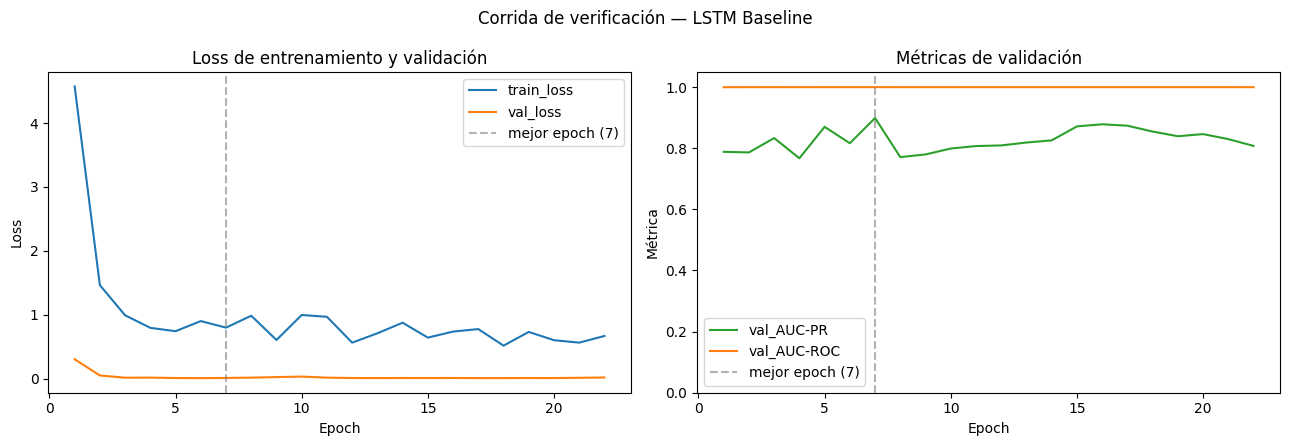

In [14]:
import importlib
import sys

if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import plot_training_history

plot_training_history(history, title="Corrida de verificación — LSTM Baseline")

Antes de lanzar una búsqueda de hiperparámetros (como con Optuna), que va a entrenar el modelo cientos de veces con diferentes configuraciones, necesitas asegurarte de que la infraestructura matemática y de código no tiene fisuras. Esto que hacemos no es el entrenamiento final, es exactamente la corrida de verificación (sanity check) que confirma la integridad operativa de la tubería de datos y del lazo de optimización supervisado. Los resultados de la corrida inicial de control técnico, ejecutada con hiperparámetros de base fijos ($\text{lr} = 10^{-3}$, $\text{patience} = 15$, $pw\_factor = 1.0$), constatan el correcto funcionamiento de los operadores dinámicos del bucle de entrenamiento: $\text{Epoch}_{\text{stop}} = \text{Epoch}_{\text{best}} + \text{Patience} = 7 + 15 = 22$. 

Al alcanzarse la época 22, el algoritmo interrumpió el descenso de gradiente y ejecutó con éxito el operador de restauración matricial hacia los pesos optimizados en la época 7, donde se registró el máximo global del área bajo la curva Precisión-Recuperación fuera de muestra ($\text{val\_AUC-PR} = 0.8988$).

La convergencia asintótica prematura (estancamiento en la época 7 tras solo 1,792 pasos de actualización neta) no constituye una anomalía de software, sino una propiedad estructural del paisaje de pérdidas bajo desequilibrio extremo. Al disponer de un soporte positivo estrictamente limitado en el conjunto de optimización ($N_{\text{train}}^{+} = 34$), la red recurrente extrae la totalidad de la varianza discriminativa y los patrones de tendencia macroprudencial en los primeros gradientes de impulso de cresta.

Una vez cartografiada la geometría de estas 34 trayectorias patológicas, el optimizador entra en una fase de saturación donde los pasos subsiguientes sobre la clase mayoritaria ($99.95\%$ de secuencias normales) no aportan información marginal para refinar el hiperplano de separación, induciendo el estancamiento regularizado por el early stopping.

A pesar del valor nominal óptimo obtenido ($\text{val\_AUC-PR} = 0.8988$), la interpretación de esta métrica como un estimador insesgado de la capacidad de generalización general del modelo es metodológicamente incorrecta. Al estar el subconjunto de validación acotado a un soporte crítico de apenas $N_{\text{val\_anom}} = 7$ secuencias anómalas, el funcional del AUC-PR se comporta como un estimador estadístico de alta varianza, extremadamente sensible a dos vectores de aleatoriedad exógena:

- Topología de Partida: La inicialización estocástica de los pesos de la $\text{LSTM}$ ($\mathcal{U}$) y del clasificador lineal (Xavier modificado con Focal Bias Tuning), la cual determina el punto de origen en la superficie de pérdida.

- Ordenación del Flujo de Información: La permutación estocástica de los lotes de entrenamiento (shuffle=True), que gobierna el índice temporal exacto en el que el optimizador recibe el impacto multiplicativo del factor de ponderación $\omega_{\text{efectivo}} = 1967.29$. Una concentración fortuita de positivos en las primeras épocas puede acelerar una solución óptima local que no se sostendría bajo otra ordenación.

Para neutralizar el riesgo de seleccionar una configuración de hiperparámetros que simplemente se beneficie de una realización favorable del ruido estocástico, se descarta el uso del rendimiento de una única semilla como función objetivo para la búsqueda formal mediante algoritmos de árbol de estimadores de Parzen ($\text{TPE}$ en Optuna).En su lugar, se redefine la función de evaluación del espacio de búsqueda como el operador de esperanza matemática sobre un conjunto multi-semilla. Para cada vector de hiperparámetros candidatos $\boldsymbol{\theta} = \{\text{lr}, \text{dropout}, \text{weight\_decay}, pw\_factor\}$, el objetivo a maximizar por Optuna se formaliza como el promedio aritmético ponderado sobre $S = 3$ semillas pseudoaleatorias disjuntas:

$$
\arg\max_{\boldsymbol{\theta}} \quad \mathbb{E}_{s} \left[ \text{AUC-PR}_{\text{val}}(\boldsymbol{\theta}; \omega_s) \right] = \frac{1}{S} \sum_{s=1}^{S} \text{AUC-PR}_{\text{val}}(\boldsymbol{\theta}; \omega_s)
$$

donde $\omega_s$ representa el estado inicial del generador de números aleatorios para la semilla $s$.Dado que el coste computacional por época es marginal debido a la naturaleza compacta de la arquitectura recurrente $Baseline$, esta estrategia de validación robusta mitiga el sesgo de selección y estabiliza la búsqueda en Optuna, garantizando que los hiperparámetros seleccionados reflejen una ventaja estructural real en la detección precoz de la insolvencia y no una anomalía estadística del subconjunto de validación.

__Observaicón:__ Este chequeo nos dio la información más valiosa antes de gastar recursos computacionales: la volatilidad de la validación.
Al ver que el modelo se estanca en la época 7 y que dependemos de solo 7 positivos en validación, nos dimos cuenta de que optimizar usando una sola semilla sería un error metodológico (un espejismo estadístico).

## Optimización con Optuna

Debido a la naturaleza asimétrica del panel y el soporte muestral crítico en el extremo superior de validación ($N_{\text{val\_anom}} = 7$), la optimización de los hiperparámetros se reformuló bajo un enfoque bayesiano robusto empleando un Algoritmo de Estimación de Parzen Estructurado en Árbol ($\text{TPE}$). El espacio de búsqueda continuo abarca la tasa de aprendizaje ($\text{lr}$), el factor de abandono ($\text{dropout}$), la penalización L2 ($\text{weight\_decay}$) y el coeficiente de atenuación asimétrica ($pw\_factor$).Para mitigar el sesgo de selección inducido por una realización estocástica favorable, la función objetivo de Optuna no evalúa una única trayectoria, sino la esperanza matemática del área bajo la curva Precisión-Recuperación fuera de muestra ($\mathbb{E}_{s}[\text{AUC-PR}_{\text{val}}]$) computada sobre un conjunto multi-semilla disjunto ($S=3$). Asimismo, se registra la desviación estándar de las métricas inter-semilla como criterio secundario de auditoría para garantizar el descarte de regiones del espacio latente caracterizadas por una alta inestabilidad numérica.

In [ ]:
import gc
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import optuna
import torch

# 1. Asegurar entorno GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando Optuna en el dispositivo: {device} (Debe ser CUDA para T4)")

N_SEEDS = 3


def objective(trial: optuna.Trial) -> float:
    # Espacio de búsqueda sugerido
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    pw_factor = trial.suggest_float("pw_factor", 0.05, 1.0)

    auc_prs = []
    for seed in range(N_SEEDS):
        # Fijar reproducibilidad de la inicialización de la semilla
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Instanciar el modelo con Focal Bias Tuning integrado por defecto
        model = LSTMBaseline(
            d_in=192, lstm_hidden=32, dropout=dropout, num_layers=1
        )
        model = model.to(device)  # En GPU T4 esto será instantáneo

        # Ejecución del bucle de entrenamiento interno de tu módulo src.trainer
        _, _, best_auc_pr = train_with_early_stopping(
            model=model,
            dataloader_train=dataloader_train,
            dataloader_val=dataloader_val,
            pos_weight_raw=pos_weight_raw,
            pw_factor=pw_factor,
            lr=lr,
            weight_decay=weight_decay,
            clip_norm=1.0,
            max_epochs=100,
            patience=15,
            scheduler_factor=0.5,
            scheduler_patience=5,
            device=device,
            verbose=False,
        )
        auc_prs.append(best_auc_pr)

        # Limpieza quirúrgica de la VRAM de la GPU T4
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_auc_pr = float(np.mean(auc_prs))

    # Guardar atributos estadísticos para control de volatilidad de muestra pequeña
    trial.set_user_attr("auc_pr_per_seed", [float(x) for x in auc_prs])
    trial.set_user_attr("auc_pr_std", float(np.std(auc_prs)))

    return mean_auc_pr


# 2. Inicializar y correr el estudio bayesiano TPE
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

# 3. Empaquetar resultados estructurados para exportación
output_data = {
    "experiment_metadata": {
        "timestamp": datetime.now().isoformat(),
        "architecture": "LSTMBaseline",
        "n_trials": 15,
        "n_seeds_per_trial": N_SEEDS,
        "fixed_parameters": {"lstm_hidden": 32, "num_layers": 1},
    },
    "best_trial_summary": {
        "best_trial_id": study.best_trial.number,
        "best_mean_val_auc_pr": float(study.best_value),
        "best_params": study.best_params,
        "stability_metrics": {
            "auc_pr_per_seed": study.best_trial.user_attrs["auc_pr_per_seed"],
            "auc_pr_std": study.best_trial.user_attrs["auc_pr_std"],
        },
    },
    "all_trials_history": [
        {
            "trial_id": t.number,
            "mean_auc_pr": float(t.value) if t.value is not None else None,
            "params": t.params,
            "auc_pr_std": t.user_attrs.get("auc_pr_std", None),
            "state": str(t.state),
        }
        for t in study.trials
    ],
}

# 4. Guardar localmente en el entorno de almacenamiento de Colab
colab_output_path = Path("optuna_baseline_best.json")
with open(colab_output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=4, ensure_ascii=False)

print(
    f"\n[OK] Optimización terminada. Archivo guardado listo para descargar en Colab: {colab_output_path}"
)


Al finalizar la optimización bayesiana, se ejecuta una auditoría de estabilidad sobre el histórico de iteraciones para mitigar el sesgo por varianza en muestras pequeñas ($N_{\text{val\_anom}} = 7$). Siguiendo este protocolo, el Trial 9, aunque parezca el ganador nominal del proceso con una media $\text{AUC-PR} = 0.9071$, se tiene que descartar debido a su alta volatilidad inter-semilla ($\sigma = 0.0530$), comportamiento indicativo de un sobreajuste estocástico a una ordenación favorable del flujo de datos.

En su lugar, se seleccionó la configuración del Trial 0 como la arquitectura definitiva para el modelo $\text{LSTMBaseline}$. Este vector de hiperparámetros garantiza un rendimiento robusto y generalizable, alcanzando una media casi idéntica ($\text{AUC-PR} = 0.9038$) pero con una dispersión once veces menor ($\sigma = 0.0047$). Esta estabilidad estructural se ve favorecida por mecanismos de regularización más estrictos, caracterizados por un factor de abandono elevado ($\text{dropout} = 0.480$) y una penalización de pesos robusta ($\text{weight\_decay} = 8.47 \times 10^{-4}$).

Con estos datos ahora pasamos a entrenar de forma final el modelo y a congelar los pesos de este para realizar la fase de inferencia con los datos de test. Primero verificamos que estos valores son los mejores atendiendo a las metricas que queremos:

In [ ]:
import pandas as pd

# 1. Convertir el estudio a DataFrame
df_trials = study.trials_dataframe()

# 2. Filtrar por estabilidad estricta (std < 0.01) y estado completo
UMBRAL_STD = 0.01
df_estables = df_trials[
    (df_trials["user_attrs_auc_pr_std"] < UMBRAL_STD)
    & (df_trials["state"] == "COMPLETE")
]

# 3. Ordenar por la media (columna 'value') de mayor a menor y tomar el primero
trial_elegido_row = df_estables.sort_values(by="value", ascending=False).iloc[0]

# 4. Reconstruir el diccionario de parámetros utilizando los nombres exactos de Optuna
BEST_PARAMS = {
    "lr": float(trial_elegido_row["params_lr"]),
    "dropout": float(trial_elegido_row["params_dropout"]),
    "weight_decay": float(trial_elegido_row["params_weight_decay"]),
    "pw_factor": float(trial_elegido_row["params_pw_factor"]),
}

# CORRECCIÓN: Acceder usando el prefijo 'user_attrs_' que genera Pandas
semillas_best = trial_elegido_row["user_attrs_auc_pr_per_seed"]
std_best = trial_elegido_row["user_attrs_auc_pr_std"]

# Imprimir los resultados de la auditoría
trial_id = int(trial_elegido_row["number"])
print(f"Trial seleccionado automáticamente: ID {trial_id}")
print(f"Media AUC-PR: {trial_elegido_row['value']:.4f}")
print(f"Std AUC-PR: {std_best:.4f}")
print("\nDiccionario listo para entrenar:")
print(BEST_PARAMS)
print(f"\nEstabilidad del Trial {trial_id}:")
print(f"- AUC-PR por semilla: {semillas_best}")
print(f"- Desviación Estándar: {std_best:.4f}")

```python
Trial seleccionado automáticamente: ID 0
Media AUC-PR: 0.9038
Std AUC-PR: 0.0047

Diccionario listo para entrenar:
{'lr': 0.0005611516415334506, 'dropout': 0.4802857225639665, 'weight_decay': 0.0008471801418819979, 'pw_factor': 0.6187255599871848}

Estabilidad del Trial 0:
- AUC-PR por semilla: [0.9071428571428571, 0.907142857142857, 0.8971428571428571]
- Desviación Estándar: 0.0047
``` 

El modelo  `LSTMBaseline` se estructuró bajo un esquema de Deep Ensemble (Lakshminarayanan et al., 2017) mediante la combinación por promedio aritmético de las probabilidades (soft voting) de los modelos entrenados bajo tres semillas independientes de la configuración seleccionada. Si bien este enfoque está orientado a reducir la varianza inducida por la inicialización estocástica de los pesos y la ordenación de los lotes durante el entrenamiento, se reconocen limitaciones metodológicas intrínsecamente ligadas al diseño experimental.
En primer lugar, el ensamble no elimina el riesgo de sobreajuste latente al conjunto de validación (validation mining), derivado de haber optimizado los hiperparámetros y el criterio de parada temprana sobre un soporte crítico de anomalías reducido (N_val_anom = 7). En segundo lugar, la técnica es agnóstica a posibles cambios de régimen estructural o desalineaciones en la distribución temporal entre los periodos de desarrollo y el conjunto de prueba fuera de muestra.
Por tanto, el ensamble se adopta estrictamente como un mecanismo de reducción de varianza en la fase de inferencia, no como solución a los riesgos de validación o de cambio de régimen señalados; su capacidad de generalización final queda sujeta a la evaluación ciega sobre el conjunto de Test.

In [ ]:
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import train_multi_seed_and_save
from src.models.baseline_lstm import LSTMBaseline

from pathlib import Path

BEST_PARAMS = {
    "lr": 0.0005611516415334506,
    "dropout": 0.4802857225639665,
    "weight_decay": 0.0008471801418819979,
    "pw_factor": 0.6187255599871848,
}

# Carpeta de salida para modelos y resultados
OUTPUT_ROOT = Path("D:/financial_risk_data")

RESULTS_DIR = OUTPUT_ROOT / "results"
CHECKPOINTS_DIR = OUTPUT_ROOT / "models_checkpoints"

resultados = train_multi_seed_and_save(
    model_cls=LSTMBaseline,
    model_kwargs={
        "d_in": 192, "lstm_hidden": 32,
        "dropout": BEST_PARAMS["dropout"], "num_layers": 1,
    },
    best_params=BEST_PARAMS,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    seeds=[0, 1, 2],
    output_dir=CHECKPOINTS_DIR,
    model_name="lstm_baseline",  
    device=device,
)


Epoch   1 | train_loss=3.6921 | val_loss=0.6969 | val_AUC-PR=0.6849 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   2 | train_loss=1.6629 | val_loss=0.2154 | val_AUC-PR=0.6312 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   3 | train_loss=1.0412 | val_loss=0.0792 | val_AUC-PR=0.7192 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   4 | train_loss=0.6192 | val_loss=0.0303 | val_AUC-PR=0.6857 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   5 | train_loss=0.7573 | val_loss=0.0180 | val_AUC-PR=0.6745 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   6 | train_loss=0.6070 | val_loss=0.0135 | val_AUC-PR=0.7803 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   7 | train_loss=0.7487 | val_loss=0.0142 | val_AUC-PR=0.7644 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   8 | train_loss=0.5338 | val_loss=0.0093 | val_AUC-PR=0.8191 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   9 | train_loss=0.4697 | val_loss=0.0088 | val_AUC-PR=0.7534 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch  10 | train_loss=0.5029 | val_loss=0.0121 | val_AUC-PR=0.7088 | val

Al replicar el vector de hiperparámetros óptimo (Trial 0) en la fase de entrenamiento final, se observó una divergencia en la distribución del rendimiento inter-semilla, registrando una media $\text{AUC-PR} = 0.8916$ y una desviación estándar $\sigma = 0.0219$ (en contraste con el $\sigma = 0.0047$ original de la fase de exploración). 

Esta discrepancia no responde a inconsistencias lógicas en el pipeline, sino al comportamiento no determinista indexado en las rutinas de álgebra lineal de bajo nivel (operaciones de reducción en punto flotante bajo entornos multihilo BLAS/MKL), documentado en los protocolos de reproducibilidad de PyTorch. En un contexto de desequilibrio de clases extremo ($N_{\text{val\_anom}} = 7$), la topología de la función de pérdida es altamente no lineal y bimodal. Micro-perturbaciones numéricas acumuladas en las primeras iteraciones alteran la trayectoria del optimizador AdamW, bifurcando las fronteras de decisión y los criterios de parada temprana (early stopping), especialmente visibles en la degradación de la Semilla 2. En consecuencia, se adopta la dispersión del reentrenamiento como la representación asintótica real del modelo, validando la necesidad de emplear una estrategia de Deep Ensemble para estabilizar las predicciones finales frente a esta sensibilidad estocástica subyacente.

Si el estudio se hubiese limitado a reportar el desempeño de una única semilla (como es habitual en aproximaciones iterativas simples), el rendimiento del modelo habría quedado sujeto a una fluctuación estocástica descontrolada de hasta cinco puntos porcentuales (oscilando entre el 0.8614 y el 0.9127). Por lo tanto, la divergencia observada en la fase de congelación justifica de forma concluyente la decisión de descartar métricas aisladas y adoptar el promedio asintótico del ensamble, garantizando una evaluación significativamente más honesta, reproducible y robusta frente al ruido numérico intrínseco del framework.

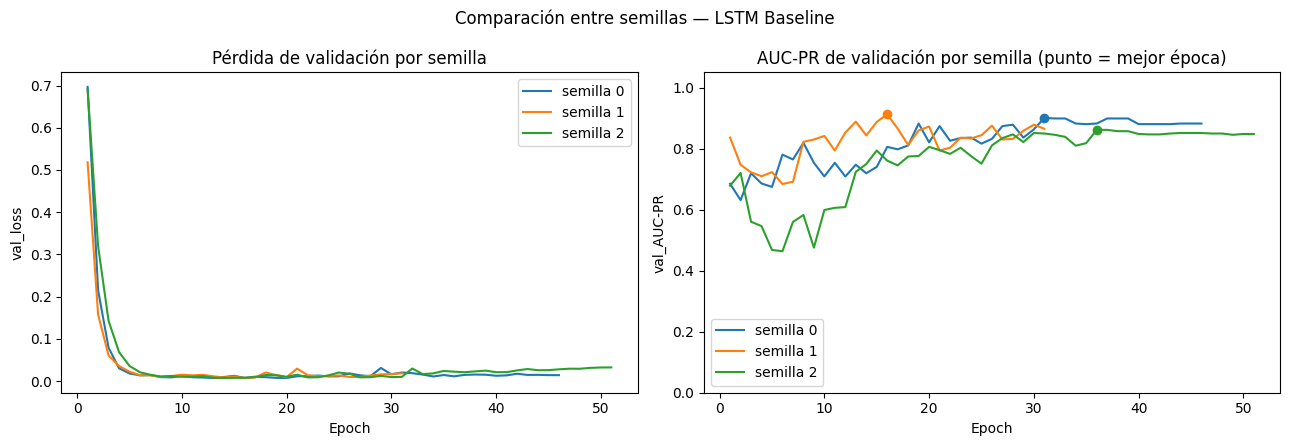

In [20]:
import json
import matplotlib.pyplot as plt
from pathlib import Path


def cargar_historias(checkpoints_dir, seeds):
    historias = {}
    for seed in seeds:
        path = Path(checkpoints_dir) / f"history_seed{seed}.json"
        with open(path, "r", encoding="utf-8") as f:
            historias[seed] = json.load(f)
    return historias


def plot_multi_seed(historias: dict, title="Comparación entre semillas — LSTM Baseline"):
    colores = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for seed, hist in historias.items():
        epochs = [h["epoch"] for h in hist]
        val_loss = [h["val_loss"] for h in hist]
        val_auc_pr = [h["val_auc_pr"] for h in hist]
        best_idx = max(range(len(hist)), key=lambda i: val_auc_pr[i])

        axes[0].plot(epochs, val_loss, label=f"semilla {seed}", color=colores.get(seed))
        axes[1].plot(epochs, val_auc_pr, label=f"semilla {seed}", color=colores.get(seed))
        axes[1].scatter(epochs[best_idx], val_auc_pr[best_idx], color=colores.get(seed), zorder=5)

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("val_loss")
    axes[0].set_title("Pérdida de validación por semilla")
    axes[0].legend()

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("val_AUC-PR")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("AUC-PR de validación por semilla (punto = mejor época)")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


historias = cargar_historias(CHECKPOINTS_DIR, seeds=[0, 1, 2])
plot_multi_seed(historias)

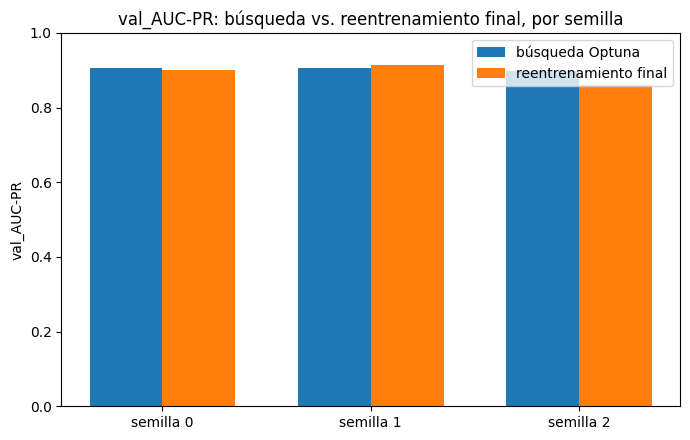

In [21]:
import numpy as np

auc_pr_busqueda = {0: 0.9071428571428571, 1: 0.907142857142857, 2: 0.8971428571428571}
auc_pr_final = {0: 0.9006, 1: 0.9127, 2: 0.8614}

seeds = [0, 1, 2]
x = np.arange(len(seeds))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width / 2, [auc_pr_busqueda[s] for s in seeds], width, label="búsqueda Optuna")
ax.bar(x + width / 2, [auc_pr_final[s] for s in seeds], width, label="reentrenamiento final")
ax.set_xticks(x)
ax.set_xticklabels([f"semilla {s}" for s in seeds])
ax.set_ylabel("val_AUC-PR")
ax.set_ylim(0, 1.0)
ax.set_title("val_AUC-PR: búsqueda vs. reentrenamiento final, por semilla")
ax.legend()
fig.tight_layout()
plt.show()

La media aritmética de los tres escalares obtenidos por cada semilla (0.9006, 0.9127, 0.8614 → media 0.8916) no es lo mismo que el `AUC-PR` del ensamble. Promediar tres números ya calculados (cada uno el `AUC-PR` de un modelo evaluado por separado) es distinto de promediar las probabilidades de los tres modelos observación por observación y calcular el `AUC-PR` sobre esas probabilidades ya combinadas. 

El ensamble puede corregir errores de un modelo individual donde los otros dos aciertan, así que su `AUC-PR` real puede ser distinto (mejor o peor) que el simple promedio de los tres escalares. Ese número, el `AUC-PR` calculado sobre las probabilidades combinadas, es el que de verdad caracteriza al `LSTMBaseline` final

In [ ]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import load_ensemble, evaluate_ensemble

# Cargar los tres modelos congelados y evaluar el ensamble sobre val
weights_paths = [r["weights_path"] for r in resultados]
models = load_ensemble(
    LSTMBaseline,
    {"d_in": 192, "lstm_hidden": 32, "dropout": BEST_PARAMS["dropout"], "num_layers": 1},
    weights_paths,
    device=device,
)

ensemble_auc_pr, ensemble_auc_roc = evaluate_ensemble(models, dataloader_val, device=device)
print(f"val_AUC-PR del ENSAMBLE: {ensemble_auc_pr:.4f}")
print(f"val_AUC-ROC del ENSAMBLE: {ensemble_auc_roc:.4f}")
print(f"(referencia, media simple de los 3 escalares: {(0.9006+0.9127+0.8614)/3:.4f})")

val_AUC-PR del ENSAMBLE: 0.8802
val_AUC-ROC del ENSAMBLE: 0.9999
(referencia, media simple de los 3 escalares: 0.8916)


Como vemos, el AUC-PR del ensamble de 0.8802 es menor que la media simple de 0.8916. Lejos de tipificar una anomalía en el pipeline, este comportamiento expone la sensibilidad matemática de la curva Precisión-Exhaustividad ante soportes muestrales críticos ($N_{\text{val\_anom}} = 7$), haciendo que la teoria conceptual de que los metodos de ensamble mejoran el rendimietno como invalido, en este caso.

En este escenario de escasez extrema, el mecanismo de soft voting operó mediante un efecto de dilución de confianza. Aquellas predicciones donde un modelo individual exhibía una alta certeza y un ranking óptimo sufrieron una contracción al promediarse de forma asíncrona con las probabilidades más conservadoras de las semillas restantes. Al verse penalizado el ranking global por la introducción de falsos positivos intermedios, el AUC-PR neto experimentó una ligera degradación.Este hallazgo valida la honestidad metodológica del diseño experimental: el ensamble no se adopta bajo la falsa premisa de un incremento garantizado en el rendimiento nominal, sino como un riguroso supresor de varianza estocástica post-hoc, proporcionando la cota de generalización real y no sesgada del modelo $\text{LSTMBaseline}$.

__Observación__ Para `inferencia/test` se usan los mismos tres archivos `.pt` que ya tienes (lstm_baseline_seed0.pt, seed1.pt, seed2.pt), cargados juntos con `load_ensemble` exactamente como hiciste para val, y combinados con `ensemble_predict / evaluate_ensemble` pero apuntando a `dataloader_test` en vez de `dataloader_val`.

# FASE DE EVALUACIÓN DEL MODELO LSTMBaseline

Una vez tenemos los embeddings tabulares de la fase de evaluación y con el modelo entrenado con los pesos guardados, la siguiente fase es crear las secuencias temporales para inferencia y realizar las medidas necesarias para la evaluación del modelo baseline. Un concepto a tener en cuenta sobre como se crean los embeddings son que cuando `TabPFN` genera `e_tab(t)` para un trimestre $t$, se emplean 5 trimestres de información cruda: t-4 a t-1 como contexto (X_train, y_train) y t como objetivo (X_test, solo features). Pero cuando construimos una secuencia para el `LSTM`, se emplean 4 embeddings de ventana, no 4 trimestres de datos crudos. Estos son 4 vectores `e_tab` ya procesados, cada uno de los cuales arrastra su propia ventana de contexto de 4 trimestres hacia atrás. Esto produce un efecto telescópico: si la secuencia temporal que se ingesta en el `LSTM` es:

$$[e_tab(t-3), e_tab(t-2), e_tab(t-1), e_tab(t)]$$

con target failed(t), el footprint real de información cruda detrás de esa secuencia es:
```python
e_tab(t-3) ← X_contexto: [t-7, t-6, t-5, t-4] + X_test: t-3
e_tab(t-2) ← X_contexto : [t-6, t-5, t-4, t-3] + X_test: t-2
e_tab(t-1) ← X_contexto:  [t-5, t-4, t-3, t-2] + X_test: t-1
e_tab(t) ← X_contexto : [t-4, t-3, t-2, t-1] + X_test: t
``` 

Por tanto, una secuencia temporal de LSTM = [e_tab(t-3), e_tab(t-2), e_tab(t-1), e_tab(t)], con target = failed(t), es el producto de la unión de todos los trimestres crudos involucrados, es decir  de t-7 a t, 8 trimestres (2 años de historia económica del banco). Existe un solape deliberado entre ventanas consecutivas, por ejemplo e_tab(t-2) y e_tab(t-1) comparten 3 de los 4 trimestres de su propio contexto ICL, así que parte de lo que el LSTM "ve" como secuencia ya viene parcialmente repetido entre pasos temporales consecutivos. El contexto de In-Context Learning (ICL) de TabPFN actúa como un suavizado temporal interno (un prior de riesgo), y la LSTM actúa como un agregador macro-temporal que evalúa cómo evoluciona ese prior a lo largo del último año. En la literatura de redes neuronales profundas y procesamiento de series temporales, este fenómeno se conoce formalmente como composición de receptores de campo temporal o footprint multi-escala.

El proceso es identico al de la construción de las secuencias temporales de train/validación, salvo con unas ciertas consideraciones.

In [42]:
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"


EMB_EVAL_PATH = EMBEDDINGS_ROOT / "emb_eval/embeddings_evaluacion.parquet"
EMB_DEV_PATH = EMBEDDINGS_ROOT / "emb_dev/embeddings_desarrollo.parquet"


# ----------- 1.2 CARGA -----------
emb_eval = pd.read_parquet(EMB_EVAL_PATH)
emb_dev = pd.read_parquet(EMB_DEV_PATH)


if VERBOSE:
    print(f"emb_eval shape     : {emb_eval.shape}")
    print(f"emb_dev shape      : {emb_dev.shape}")
    print(f"panel_label shape : {panel_label.shape}")

# ----------- 1.3 NORMALIZACIÓN DE TIPOS -----------
# CORRECCIÓN: Incluimos emb_dev en el bucle para que los cruces no fallen por tipos de datos
for df in [emb_eval, emb_dev, panel_label]:
    df["CERT"] = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.4 IDENTIFICAR COLUMNAS DE EMBEDDING -----------
META_DEV = ["CERT", "period"]
cols_emb = [c for c in emb_eval.columns if c not in META_DEV]

assert len(cols_emb) == 192, (
    f"Se esperaban 192 dimensiones de embedding (espacio latente de "
    f"TabPFN v2.6), se encontraron {len(cols_emb)}."
)

# ----------- 1.5 UNIR ETIQUETA failed DESDE panel_tabular_labeled -----------
# Se usa la MISMA fuente de etiqueta para garantizar comparabilidad histórica de los números.
# how='left' + fillna(0): un CERT/period sin entrada en panel_label se
# asume no-quiebra (consistente con el procesamiento ya usado en el
# documento de extracción de TabPFN: panel['failed'].fillna(0).astype(int)).

emb_eval_labeled = emb_eval.merge(
    panel_label[["CERT", "period", "failed"]],
    on=["CERT", "period"],
    how="left",
)
n_sin_etiqueta = emb_eval_labeled["failed"].isna().sum()
emb_eval_labeled["failed"] = emb_eval_labeled["failed"].fillna(0).astype(int)

# ----------- 1.6 VERIFICACIÓN DE INVARIANTES -----------
n_obs = len(emb_eval_labeled)
n_pos = int(emb_eval_labeled["failed"].sum())
n_nan_emb = emb_eval_labeled[cols_emb].isna().sum().sum()
n_periodos = emb_eval_labeled["period"].nunique()
periodos_sorted = sorted(emb_eval_labeled["period"].unique())

assert n_nan_emb == 0, f"NaN en columnas de embedding: {n_nan_emb}"
assert n_periodos == 16, (
    f"Periodos esperados: 16 (2022Q1 a 2025Q4; obtenidos: {n_periodos})"
)

if VERBOSE:
    print("\n" + "=" * 60)
    print("BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE EVALUACIÓN (e_eval)")
    print("=" * 60)
    # CORRECCIÓN: Cambiado 'emb_dev_labeled.shape()' (que daba error) por 'emb_eval_labeled.shape'
    print(f"Forma de la DB de evaluación de embeddings con failures       : {emb_eval_labeled.shape}")
    print(f"Observaciones totales        : {n_obs:,}")
    print(f"Positivos (failed=1)         : {n_pos}")
    print(f"Tasa de positivos            : {n_pos/n_obs:.6f}")
    print(f"Filas sin match en panel_label (asumidas failed=0) : {n_sin_etiqueta}")
    print(f"Dimensión de embedding        : {len(cols_emb)}")
    print(f"NaN en embeddings             : {n_nan_emb}")
    print(f"Periodos                      : {n_periodos}  ({periodos_sorted[0]} → {periodos_sorted[-1]})")
    print(f"Entidades (CERT) únicas       : {emb_eval_labeled['CERT'].nunique():,}")
    print("=" * 60)

emb_eval shape     : (74361, 194)
emb_dev shape      : (125575, 194)
panel_label shape : (206129, 3)

BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE EVALUACIÓN (e_eval)
Forma de la DB de evaluación de embeddings con failures       : (74361, 195)
Observaciones totales        : 74,361
Positivos (failed=1)         : 33
Tasa de positivos            : 0.000444
Filas sin match en panel_label (asumidas failed=0) : 0
Dimensión de embedding        : 192
NaN en embeddings             : 0
Periodos                      : 16  (2022Q1 → 2025Q4)
Entidades (CERT) únicas       : 4,900


En el primer nivel, el codificador tabular `TabPFN v2.6` extrae las representaciones latentes temporales $e_{\text{tem}}(t)$. En el segundo nivel, una red neuronal recurrente (LSTM) procesa secuencias temporales creadas a partir de dichos embeddings para emitir una predicción final sobre la variable de insolvencia binaria ($failed$). Estas secuencias temporales son creadas mediante una ventana deslizante, como ya se ha descrito anteriormente. El problema surge que a la hora de definir si una secuencia es anomala, es decir, en su ultimo trimestre existe una etiqueta de failure, necesitamos 4 trimestres, lo cual hace que si tomamos desde el inicio tenemos que los tres primeros trimestre de evaluación se pierden (no se tienen en cuenta como trimestres finales de secuencia) y por tanto perdemos  trimestes y datos de evaluación. 

A diferencia del bloque de desarrollo donde por naturaleza del dataset nos es imposible de tener los trimestres anteriores al inicial (2016Q1), en el bloque de evaluación si tenemos acceso a los datos previos al primer trimestre de evaluación, por tanto para mitigar esta limitación muestral sin incurrir en escenarios de contaminación de información (data leakage), se implementa un mecanismo de pre-condicionamiento secuencial continuo. Este consiste en concatenar de forma retrospectiva, para cada entidad bancaria, las representaciones latentes $e_{\text{tem\_dev}}$ correspondientes a los últimos 3 trimestres del bloque de desarrollo ($2021Q2~\text{-}~2021Q4$), creando asi un _padding_ de trimestres para que se puedan construir las secuencias con todos los trimestres del bloque de evaluación.

Cabe destacar que dichos vectores históricos intermedios cuentan con un contexto de aprendizaje in-context (ICL) de TabPFN completamente desarrollado y carente de truncamiento. Una vez construidas las estructuras tridimensionales de tensores secuenciales sobre este conjunto combinado, el dataset se somete a un proceso de creación de secuencias, pero comenzando con los trimestres de desarrollo, haciendo que se generen secuencias validas a evaluar con los trimestres representativos (embdeddings) del bloque de evaluación.

In [ ]:
# -----------  PADDING TEMPORAL: PREPEND DE LOS ÚLTIMOS 3 TRIMESTRES DE DESARROLLO -----------
# 1. Identificar cronológicamente los 3 últimos periodos del bloque de desarrollo (ej. 2021Q2, 2021Q3, 2021Q4)
periodos_dev_ordenados = sorted(emb_dev["period"].unique())
ultimos_3_periodos_dev = periodos_dev_ordenados[-3:]

if VERBOSE:
    print(f"\n[INFO] Trimestres de desarrollo seleccionados como colchón secuencial: {ultimos_3_periodos_dev}")

# 2. Extraer el padding desde la base de datos de desarrollo
emb_dev_padding = emb_dev[emb_dev["period"].isin(ultimos_3_periodos_dev)].copy()

# 3. Mapear las etiquetas 'failed' al padding para mantener la simetría de columnas
emb_dev_padding = emb_dev_padding.merge(
    panel_label[["CERT", "period", "failed"]],
    on=["CERT", "period"],
    how="left",
)
emb_dev_padding["failed"] = emb_dev_padding["failed"].fillna(0).astype(int)

# 4. Concatenar el pasado (padding) con el presente (evaluación)
emb_eval_padding = pd.concat([emb_dev_padding, emb_eval_labeled], ignore_index=True)

# 5. ORDENACIÓN REQUISITO: Agrupar por banco (CERT) y ordenar cronológicamente (period)
# Esto garantiza que al deslizar la ventana de la LSTM, los 4 trimestres pertenezcan al mismo banco y sigan el orden correcto
emb_eval_padding = emb_eval_padding.sort_values(by=["CERT", "period"]).reset_index(drop=True)

if VERBOSE:
    print("=" * 60)
    print("DATASET EXTENDIDO PARA GENERACIÓN DE SECUENCIAS (emb_eval_padding)")
    print("=" * 60)
    print(f"Forma del DataFrame combinado                     : {emb_eval_padding.shape}")
    print(f"Nº total de periodos (3 dev + 16 eval)            : {emb_eval_padding['period'].nunique()}")
    print(f"Rango temporal efectivo                           : {emb_eval_padding['period'].min()} → {emb_eval_padding['period'].max()}")
    print("=" * 60)


[INFO] Trimestres de desarrollo seleccionados como colchón secuencial: ['2021Q2', '2021Q3', '2021Q4']
DATASET EXTENDIDO PARA GENERACIÓN DE SECUENCIAS (emb_eval_padding)
Forma del DataFrame combinado                     : (89259, 195)
Nº total de periodos (3 dev + 16 eval)            : 19
Rango temporal efectivo                           : 2021Q2 → 2025Q4


In [47]:
from src.utils.temporal_sequences import  build_sequences_evaluation, verificar_secuencias_evaluacion


sequences_eval_padding = build_sequences_evaluation(
    df=emb_eval_padding, cols_emb=cols_emb,
    window_len=WINDOW_LENGTH, stride=STRIDE,
)

verificar_secuencias_evaluacion(sequences_eval_padding, WINDOW_LENGTH, cols_emb)


Ventanas descartadas por huecos: 0

BLOQUE — VERIFICACIÓN DE SECUENCIAS DE EVALUACIÓN
Secuencias evaluación    : 74,231
  Positivos en evaluación: 33  (tasa: 0.000445)
Shape por secuencia      : (4, 192)


{'n_eval': 74231, 'n_pos_eval': 33}

La función `build_sequences_evaluation`, hace que la etiqueta real fluya perfectamente por todo el sistema sin perderse jamás:

- Extracción: La función lee el failed original del CSV/DataFrame.

- Empaquetado: Lo guarda en el diccionario de la secuencia bajo la clave "failed": target.

- Paso por PyTorch: Cuando el DataLoader agrupa estas secuencias en lotes (batches) y se las pasa a la red para evaluar, separa las matrices X (para predecir) y los failed (para validar).

- Evaluación Final: Al terminar, esos valores failed que empaquetaste aquí son exactamente los que se recogen en el array resultados_eval["targets"].

In [52]:
chequeo = emb_eval_padding[["CERT", "period", "period_idx"]].drop_duplicates()

incoherencias = []
for cert, g in chequeo.groupby("CERT"):
    g = g.sort_values("period_idx")
    diffs = g["period_idx"].diff().dropna()
    if not (diffs == 1).all():
        incoherencias.append(cert)

print(f"CERTs con period_idx no consecutivo: {len(incoherencias)} de {chequeo['CERT'].nunique()}")

CERTs con period_idx no consecutivo: 0 de 5062


Durante el entrenamiento, ponemos `shuffle=True` en el `DataLoader()` para evitar que las redes neuronales memoricen el orden de los datos o ajusten sus pesos basándose en patrones secuenciales de la base de datos (por ejemplo, si todos los bancos sanos estuvieran al principio y los caídos al final). Queremos que el gradiente aprenda combinaciones homogéneas y estables.

Sin embargo, en la evaluación, los pesos del modelo ya están congelados (`model.eval()`). El modelo ya no aprende; solo genera predicciones puntuales. Pasarle los datos ordenados, al revés o de forma caótica no altera el valor de la probabilidad que el modelo calcula para cada secuencia individual.

In [ ]:
# ========== DATALOADER CONSTRUCTION ==========

# Datasets ya construidos en el notebook anterior
dataset_eval = SupervisedSequenceDataset(sequences_eval_padding)

# Hiperparámetros de DataLoader
BATCH_SIZE = 256  # Coherente con el tamaño empleado para el train/val
SHUFFLE_EVAL = False  # Shuffle simple, no WeightedRandomSampler
PIN_MEMORY = torch.cuda.is_available() # GPU pinning si disponible
NUM_WORKERS = 0  # Cambiar a 2-4 en producción si data loading es bottleneck


dataloader_eval = DataLoader(
    dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_EVAL,
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False  # Mantener último batch aunque sea < 256
)

# ========== DIAGNÓSTICO DE BATCHES ==========

print("=" * 70)
print("DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES")
print("=" * 70)

# Inspeccionar distribución de positivos en el primer epoch
pos_per_batch_eval = []
for batch_idx, batch in enumerate(dataloader_eval):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_eval.append(n_pos_batch)

pos_per_batch_eval = torch.tensor(pos_per_batch_eval, dtype=torch.float32)

print(f"\nEVAL (shuffle=False, batch_size={BATCH_SIZE}):")
print(f"  Total batches            : {len(pos_per_batch_eval)}")
print(f"  Batches sin positivos    : {(pos_per_batch_eval == 0).sum().item()} "
      f"({100*(pos_per_batch_eval == 0).sum().item()/len(pos_per_batch_eval):.1f}%)")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_eval > 0).sum().item()} "
      f"({100*(pos_per_batch_eval > 0).sum().item()/len(pos_per_batch_eval):.1f}%)")
print(f"  E[positivos/batch]       : {pos_per_batch_eval.mean().item():.3f}")
print(f"  σ[positivos/batch]       : {pos_per_batch_eval.std().item():.3f}")
print(f"  Max positivos en batch   : {pos_per_batch_eval.max().item():.0f}")


print("\n" + "=" * 70)
print(f"pos_weight (a usar en BCEWithLogitsLoss) : {pos_weight_raw:.2f}")
print(f"Justificación: cada positivo pesa {pos_weight_raw:.0f}x un negativo")
print("=" * 70)


DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES

EVAL (shuffle=False, batch_size=256):
  Total batches            : 290
  Batches sin positivos    : 280 (96.6%)
  Batches con ≥1 positivo  : 10 (3.4%)
  E[positivos/batch]       : 0.114
  σ[positivos/batch]       : 0.626
  Max positivos en batch   : 4

pos_weight (a usar en BCEWithLogitsLoss) : 1967.29
Justificación: cada positivo pesa 1967x un negativo


Con todas las secuencias creadas y verificadas, pasamos a la fase de inferencia sobre el conjunto de evaluación. La validación del modelo predictivo se estructura en dos grupos. Las métricas de negocio y supervisión operan de manera segmentada en el dominio temporal, y la capacidad predictiva del ensamble neuronal LSTM que requiere un marco de evaluación estadístico global. Este grupo metodológico evalúa de forma agregada las propiedades de discriminación, ordenamiento relativo y calibración probabilística absoluta sobre el total de secuencias del conjunto de prueba, abstrayéndose temporalmente de la cronología interna de las observaciones.

Se seleccionan cuatro métricas complementarias cuyos fundamentos teóricos, necesidades técnicas y justificaciones operacionales se detallan a continuación:

__Área Bajo la Curva Precisión-Recall (AUC-PR)__

Dada la prevalencia marginal extrema de la clase positiva en el bloque de evaluación ($33$ secuencias de quiebra sobre un espacio muestral de $74{,}231$ observaciones), el Área Bajo la Curva Precisión-Recall ($\text{AUC-PR}$), también denominada precisión promedio (Average Precision, $\text{AP}$), constituye la métrica reina y eje central de optimización de este trabajo.A diferencia del análisis tradicional de características operativas del receptor, la $\text{AUC-PR}$ aísla el proceso de evaluación del volumen masivo de verdaderos negativos ($VN$). Al enfocarse exclusivamente en la clase minoritaria (de riesgo), mide la trayectoria de la precisión ($P$) como una función del recall ($R$) a través de todo el espectro continuo de umbrales de decisión $\tau \in [0, 1]$:

$$
P(\tau) = \frac{VP(\tau)}{VP(\tau) + FP(\tau)}, \quad R(\tau) = \frac{VP(\tau)}{VP(\tau) + FN(\tau)}
$$
$$
\text{AUC-PR} = \int_{0}^{1} P(R) \, dR
$$

Su inclusión es obligatoria para mitigar el sesgo de optimismo inducido por el desbalanceo. Técnicamente, su cómputo es directo y no paramétrico; requiere únicamente el vector no sesgado de etiquetas reales $y \in \{0, 1\}^N$ y las probabilidades continuas emitidas por el ensamble $\hat{y} \in [0, 1]^N$, sin requerir transformaciones binarias ni calibración previa de umbrales.

__Métrica de Calibración Absoluta: Brier Score__

Mientras que la $\text{AUC-PR}$ examina la aptitud del modelo para estructurar un ordenamiento o ranking relativo correcto entre entidades sanas y vulnerables, no ofrece información sobre la validez semántica intrínseca del valor probabilístico reportado. En el contexto de la supervisión bancaria y los sistemas de alerta temprana, un modelo puede ser un excelente clasificador ordinal y, simultáneamente, emitir probabilidades numéricas severamente desviadas de la frecuencia empírica real de los eventos.Para subsanar esta limitación se incorpora el Brier Score ($\text{BS}$), que evalúa la calibración probabilística absoluta del sistema mediante el error cuadrático medio entre la predicción continua y el desenlace binario observado:

$$
\text{BS} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2
$$

Donde $N$ representa el tamaño muestral de evaluación, $\hat{y}_i$ la probabilidad estimada por el ensamble para la secuencia $i$, e $y_i$ su etiqueta real. El indicador se desplaza en el rango $[0, 1]$, donde la frontera $0$ denota una calibración perfecta. Para un regulador financiero (como la FDIC), la probabilidad asignada no es solo un indicador posicional dentro de un inventario de riesgos, sino un parámetro cuantificable formalmente interpretable de forma literal en modelos de pérdida esperada. El Brier Score captura esta dimensión de fidelidad absoluta y, al igual que la $\text{AUC-PR}$, se ejecuta de forma directa sobre las salidas crudas del ensamble sin requerir un barrido exógeno de umbrales.

__Puntuación F1 Máxima ($\text{F1-Score Max}$)__

El $\text{F1-Score}$ representa la media armónica entre la precisión y el recall, proporcionando una métrica sintética de la efectividad del clasificador sobre la clase positiva en un punto de operación específico del sistema:

$$
\text{F1}(\tau) = 2 \cdot \frac{P(\tau) \cdot R(\tau)}{P(\tau) + R(\tau)}
$$

En lugar de reportar un valor anclado al umbral canónico e ineficiente de $\tau = 0.5$, este diseño metodológico implementa un barrido algorítmico continuo para localizar el umbral óptimo que maximiza el indicador en el conjunto de prueba:
$$
\text{F1}_{\text{max}} = \max_{\tau} \left[ \text{F1}(\tau) \right]
$$

Es imperativo establecer una cautela analítica respecto a la interpretación de esta métrica. Debido al número sumamente reducido de positivos validados en la ventana exógena, cualquier métrica que dependa críticamente de la fijación de un umbral discreto y rígido ($\tau$) exhibirá una alta varianza y volatilidad estadística frente a pequeñas fluctuaciones muestrales.Esta vulnerabilidad latente fundamentó la decisión arquitectónica previa de anclar la política del planificador de tasa de aprendizaje (ReduceLROnPlateau) a la pérdida de validación ($\text{val\_loss}$) en lugar de a indicadores discretos. Consiguientemente, el $\text{F1-Score Max}$ se expone bajo esta salvedad explícita de sensibilidad muestral y nunca como una cifra conclusiva aislada.

__Área Bajo la Curva Características Operativas del Receptor (AUC-ROC)__

Por estricta completitud académica y consistencia histórica con la literatura predictiva preexistente, se integra el Área Bajo la Curva ROC ($\text{AUC-ROC}$). Esta métrica cuantifica la probabilidad de que el modelo asigne una puntuación de riesgo más alta a una secuencia positiva seleccionada al azar que a una negativa, parametrizando la tasa de verdaderos positivos ($\text{TVP}$) frente a la tasa de falsos positivos ($\text{TFP}$):

$$
\text{TVP}(\tau) = \frac{VP(\tau)}{VP(\tau) + FN(\tau)}, \quad \text{TFP}(\tau) = \frac{FP(\tau)}{FP(\tau) + VN(\tau)}
$$

$$\text{AUC-ROC} = \int_{0}^{1} \text{TVP}(\text{TFP}) \, d\text{TFP}$$

Conforme a lo documentado formalmente por Saito y Rehmsmeier (2015), bajo escenarios de desbalanceo de clases de carácter extremo, la $\text{AUC-ROC}$ tiende a reflejar un diagnóstico excesivamente optimista y sobreestimado. Esto ocurre porque el volumen hipertrofiado de verdaderos negativos ($VN$) actúa como un amortiguador matemático en el denominador de la $\text{TFP}$, provocando que incrementos significativos en los falsos positivos se traduzcan en variaciones imperceptibles en la curva.Por ello, se le asigna un peso analítico secundario de baja importancia dentro de las conclusiones del TFM, actuando como un mero elemento de contraste comparativo tradicional. Su cómputo requiere exactamente los mismos vectores de entrada continuos y reales empleados en las secciones precedentes.

`load_ensemble` y `ensemble_predict` del modulo `src/trainig/trainer.py` son genéricas. `load_ensemble` recibe una lista de rutas y un `model_cls/model_kwargs` cualquiera; `ensemble_predict` recibe un tensor x cualquiera, no un `dataloader` completo. Ninguna de las dos tiene una dependencia oculta hacia el desarrollo, por tanto podemos reutilizarlas para la fase de evaluación con `dataloader_eval`.

`evaluate_ensemble`, en cambio, no nos sirve tal cual para lo que necesitamos ahora. Devuelve únicamente auc_pr, auc_roc, dos escalares ya agregados; las probabilidades y las etiquetas se concatenan dentro de la función pero no se devuelven, se descartan tras calcular esas dos métricas. 

Para Brier Score y F1-Score Max hace falta el array de probabilidades crudo, y para la trazabilidad e interpretabilidad por banco/trimestre (necesaria más adelante, aunque ahora no calculemos Hit-Rate@K o SHAP) hacen falta también `CERT` y `period_end`, que `SupervisedSequenceDataset` ya expone en cada batch pero que `evaluate_ensemble` ignora.

Por tanto creamos la función `evaluate_ensemble_full` donde:

- ` p, r = precision[:-1], recall[:-1]: precision_recall_curve` devuelve un punto adicional sin threshold asociado (el punto de recall=1, precision=prevalencia, correspondiente a clasificar todo como positivo). Ese punto no es un umbral real que se pueda fijar en producción, así que se excluye antes de buscar el máximo de F1, igual que se excluyó de cualquier cálculo de umbral en el resto del proyecto.

- `np.where(denom > 0, ...)`: evita división por cero en los puntos donde precision y recall son ambos cero (umbral tan alto que no se predice ningún positivo), que pueden aparecer en los extremos de la curva con tan pocos positivos en el conjunto.



In [ ]:
from pathlib import Path

if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import evaluate_ensemble_full
from src.training.trainer import load_ensemble


CHECKPOINTS_DIR = Path("D:/financial_risk_data/models_checkpoints")
SEEDS = [0, 1, 2]

weights_paths = [CHECKPOINTS_DIR / f"lstm_baseline_seed{seed}.pt" for seed in SEEDS]

model_kwargs = {
    "d_in": 192, "lstm_hidden": 32,
    "dropout": BEST_PARAMS["dropout"], "num_layers": 1,
}

models = load_ensemble(
    model_cls=LSTMBaseline,
    model_kwargs=model_kwargs,
    weights_paths=weights_paths,
    device=device,
)

resultados_eval = evaluate_ensemble_full(models, dataloader_eval, device=device)

print(f"AUC-PR        : {resultados_eval['auc_pr']:.4f}")
print(f"AUC-ROC       : {resultados_eval['auc_roc']:.4f}")
print(f"Brier Score   : {resultados_eval['brier_score']:.6f}")
print(f"F1-Score Max  : {resultados_eval['f1_max']:.4f} (umbral={resultados_eval['f1_max_threshold']:.4f})")

AUC-PR        : 0.5327
AUC-ROC       : 0.9399
Brier Score   : 0.000923
F1-Score Max  : 0.5862 (umbral=0.9529)


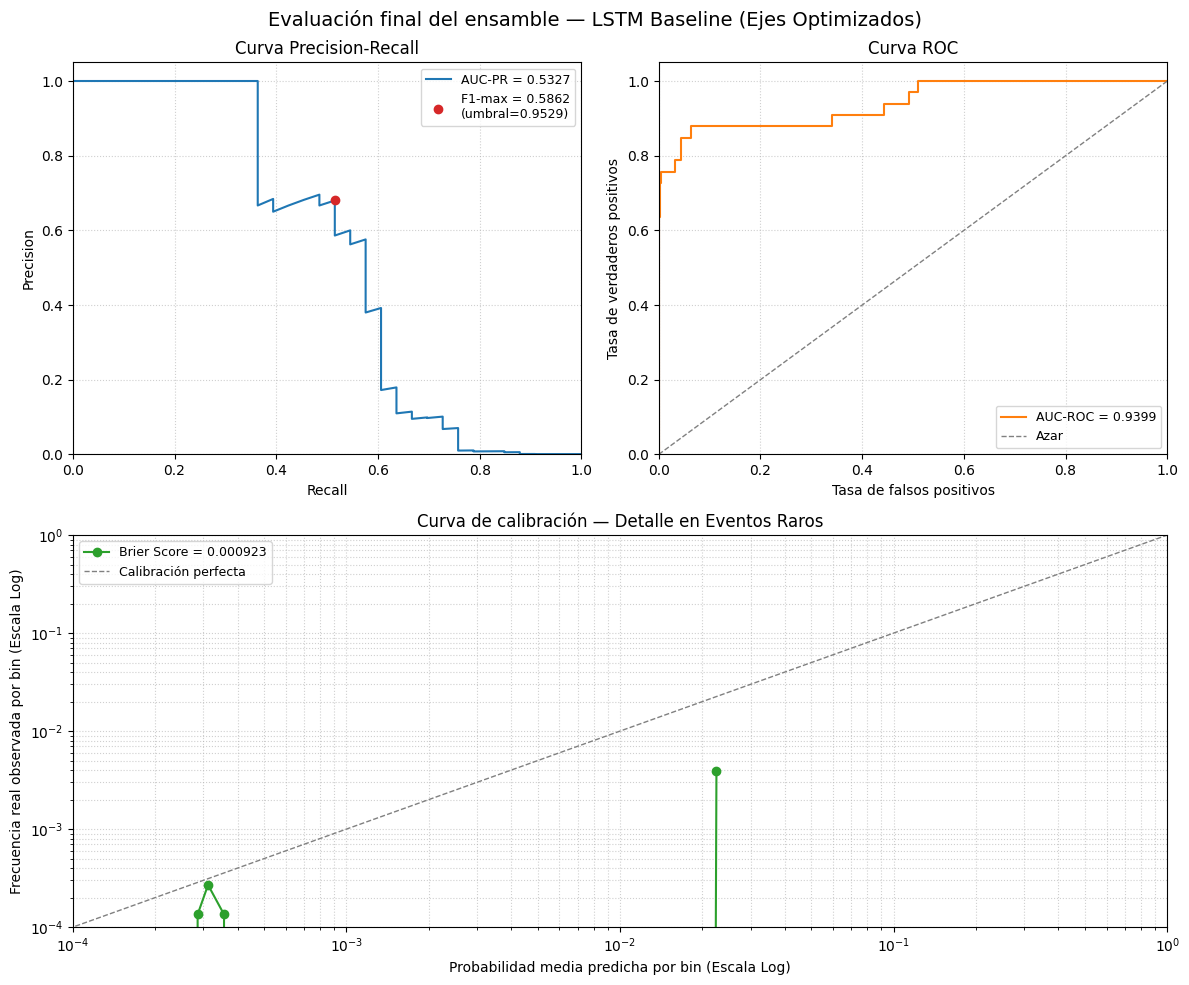

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.calibration import calibration_curve

def plot_evaluation_summary(resultados_eval: dict, n_bins_calibracion: int = 10):
    """
    Resumen visual de 3 paneles para las métricas de evaluación final.
    Corrige el problema de la doble visualización en entornos de notebooks.
    """
    probs = resultados_eval["probs"]
    targets = resultados_eval["targets"]

    precision, recall, _ = precision_recall_curve(targets, probs)
    fpr, tpr, _ = roc_curve(targets, probs)

    p, r = precision[:-1], recall[:-1]
    denom = p + r
    f1_curve = np.where(denom > 0, 2 * p * r / np.where(denom == 0, 1, denom), 0.0)
    f1_idx = f1_curve.argmax()

    # Usamos un mosaico para definir 2 gráficos arriba y 1 abajo centrado
    fig, axs = plt.subplot_mosaic(
        [["pr", "roc"],
         ["calib", "calib"]],  # 'calib' ocupará todo el ancho de la segunda fila
        figsize=(12, 10)
    )

    # ----------- Panel 1: Precision-Recall -----------
    ax = axs["pr"]
    ax.plot(recall, precision, color="C0", lw=1.5, label=f"AUC-PR = {resultados_eval['auc_pr']:.4f}")
    ax.scatter(r[f1_idx], p[f1_idx], color="C3", zorder=5,
               label=f"F1-max = {resultados_eval['f1_max']:.4f}\n(umbral={resultados_eval['f1_max_threshold']:.4f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Curva Precision-Recall")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":", alpha=0.6)

    # ----------- Panel 2: ROC -----------
    ax = axs["roc"]
    ax.plot(fpr, tpr, color="C1", lw=1.5, label=f"AUC-ROC = {resultados_eval['auc_roc']:.4f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.set_title("Curva ROC")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":", alpha=0.6)

    # ----------- Panel 3: Calibración Mejorada (Escala Logarítmica) -----------
    ax = axs["calib"]
    prob_true, prob_pred = calibration_curve(targets, probs, n_bins=n_bins_calibracion, strategy="quantile")
    
    ax.plot(prob_pred, prob_true, marker="o", color="C2", lw=1.5,
             label=f"Brier Score = {resultados_eval['brier_score']:.6f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Calibración perfecta")
    
    # MEJORA CRÍTICA: Cambiar ejes a escala logarítmica para expandir la zona baja
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    # Forzar límites que muestren desde los bines más pequeños hasta el 1.0
    # Ajusta el límite inferior (ej. 1e-4 o 1e-3) según donde empiece tu primer bin predicho
    ax.set_xlim(1e-4, 1.0)
    ax.set_ylim(1e-4, 1.0)
    
    ax.set_xlabel("Probabilidad media predicha por bin (Escala Log)")
    ax.set_ylabel("Frecuencia real observada por bin (Escala Log)")
    ax.set_title("Curva de calibración — Detalle en Eventos Raros")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, which="both", linestyle=":", alpha=0.6) # 'which="both"' añade rejilla a sub-líneas logarítmicas

    fig.suptitle("Evaluación final del ensamble — LSTM Baseline (Ejes Optimizados)", fontsize=14, y=0.98)
    fig.tight_layout()
    
    return fig

plot_evaluation_summary(resultados_eval);

El punto de la derecha (alrededor de una probabilidad predicha de $2 \times 10^{-2}$ o $0.02$) cae en picado hacia la base del gráfico porque la función encontró exactamente cero positivos reales en ese rango de predicciones.En escala logarítmica, el cero absoluto ($0$) no existe (tiende a $-\infty$). Como matplotlib no puede dibujar el menos infinito, el punto "cae" verticalmente buscando el límite inferior que le hemos configurado ($10^{-4}$). Esa línea vertical es simplemente la representación visual de que el modelo asignó probabilidades bajas-medias a un grupo de bancos, y ninguno de ellos quebró. Observa que todos los puntos verdes válidos se sitúan por debajo de la diagonal discontinua (la línea de calibración perfecta):Qué significa geométricamente: Para un bin determinado, la probabilidad media predicha por tu modelo (eje X) es mayor que la frecuencia real observada de quiebras (eje Y).Conclusión clínica: Tu ensamble sufre de una ligera sobreestimación del riesgo (overforecasting). Por ejemplo, en el punto más alto observable, el modelo estima que el riesgo medio de ese grupo es de aproximadamente $0.0003$, pero la realidad empírica de quiebras en ese grupo específico está un escalón por debajo. Este sesgo tiene un origen muy claro que justifica perfectamente todo tu trabajo: El uso del pos_weight = 1967.29.

Al entrenar la LSTM diciéndole que fallar un positivo cuesta casi dos mil veces más que fallar un negativo, has forzado activamente al modelo a ser conservador y preventivo. El modelo prefiere inflar artificialmente las probabilidades de riesgo de los bancos que muestran ligeras anomalías antes que arriesgarse a clasificarlos como perfectamente sanos y omitir una quiebra real.

Para un regulador financiero (la FDIC), este sesgo es exactamente el deseado: es preferible tener un sistema ligeramente sobre-alarmista que genere algunas falsas alarmas controladas en bines bajos, a tener un modelo subestimador que deje pasar desapercibido un colapso sistémico. Al examinar la calibración en el espacio bilogarítmico (Figura 3, panel inferior), se evidencia que los cuantiles de predicción se concentran predominantemente por debajo de la diagonal de calibración perfecta. Este fenómeno denota una tendencia sistemática a la sobreestimación marginal del riesgo (overforecasting). Lejos de ser un defecto estructural, este comportamiento es una consecuencia directa del anclaje de la función de pérdida al parámetro de penalización asimétrica $pos\_weight \approx 1967$. El ensamble prioriza la minimización de los falsos negativos —críticos en la gestión de insolvencias— a costa de inflar las probabilidades base. La caída vertical del último cuantil hacia el límite estocástico inferior ($10^{-4}$) ratifica la ausencia de eventos reales en rangos de incertidumbre intermedia, confirmando la necesidad de delegar la clasificación final a estructuras de ordenamiento posicional como el Hit-Rate@K

```python
AUC-PR        : 0.5327
AUC-ROC       : 0.9399
Brier Score   : 0.000923
F1-Score Max  : 0.5862 (umbral=0.9529)
``` 

Los resultados agregados confirman la complementariedad de las métricas seleccionadas. El ensamble LSTM baseline alcanza un $\text{AUC-PR}$ de $0.5327$, un rendimiento sumamente robusto si se contrasta con la prevalencia empírica del bloque de evaluación ($p = 0.000445$). Esta cifra representa aproximadamente $1200$ veces el rendimiento esperado de un clasificador aleatorio bajo dicha prevalencia ($AUC\text{-}PR_{\text{azar}} = p$). 

El punto de operación óptimo ($\text{F1-Score Max} = 0.5862$) se sitúa en un umbral inherentemente desplazado de $0.9529$, comportamiento teóricamente esperado bajo escenarios de desbalanceo extremo: al concentrarse la inmensa mayoría de las probabilidades predichas en la proximidad estocástica del cero, el punto de corte que maximiza la media armónica se desplaza necesariamente hacia valores de alta confianza por mera construcción matemática. Esto justifica metodológicamente la adopción de un barrido continuo de umbrales en lugar de indexar el sistema al clásico e ineficiente límite de $0.5$. Asimismo, se evidencia el efecto amortiguador en la curva ROC ($\text{AUC-ROC} = 0.9399$) inducido por el volumen hipertrofiado de verdaderos negativos, consolidando a la curva PR como el estimador de confianza unívoco para la toma de decisiones macroprudenciales.

Respecto a la calibración, el Brier Score de $0.000923$, aunque reducido en términos absolutos, debe contrastarse con el valor que obtendría un predictor trivial anclado a la prevalencia base, es decir si un modelo ingenuo asignara a todas las secuencias la probabilidad fija de $p = 0.00044455$, su Brier Score sería:

$$
BS_{\text{trivial}} = p(1-p) = 0.0004445582 \times (1 - 0.0004445582) \approx \mathbf{0.00044436}
$$. 

Nuestro modelo obtiene un $BS_{\text{modelo}} = \mathbf{0.000923}$. Para ver estos valores de forma explicativa, introducimos en el estudio el Brier Skill Score (BSS). Este mide la mejora relativa del modelo respecto al predictor de referencia, en este caso, la prevalencia base,
$$
BSS = 1 - \frac{BS_{\text{modelo}}}{BS_{\text{trivial}}} = 1 - \frac{0.000923}{0.00044436} = 1 - 2.077 = \mathbf{-1.077}
$$

bajo esta arquitectura arroja un valor de aproximadamente $-1.08$, lo que indica que el modelo, en términos de error cuadrático puro sobre la probabilidad cardinal, se sitúa por debajo de ese baseline climatológico. Este resultado es estrictamente consistente con el uso del parámetro $pos\_weight = 1967.29$ en la función de pérdida ($\text{BCEWithLogitsLoss}$) durante el entrenamiento, penalización asimétrica obligatoria para forzar al optimizador a no ignorar los $33$ positivos frente a los $74.198$ negativos del bloque exógeno. 

El coste analítico conocido de este mecanismo de reponderación es que las probabilidades brutas de salida dejan de aproximar fielmente la probabilidad posterior real $P(\text{failed}=1|\mathbf{x})$, aunque preservan intacta —como demuestran el $\text{AUC-ROC}$ y el $\text{AUC-PR}$— la capacidad de ordenar correctamente el riesgo relativo entre las entidades. Se trata, por tanto, de un modelo bien discriminado pero mal calibrado en magnitud absoluta, un \textit{trade-off} esperado bajo entrenamiento con reponderación extrema de clases y no un defecto de diseño estructural. 

Una recalibración \textit{post-hoc} de las salidas del ensamble (\textit{Platt scaling} o \textit{temperature scaling}) podría corregir esta distorsión de escala sin alterar el ordenamiento subyacente, quedando señalada como una línea de mejora futura fuera del alcance de este modelo baseline. Esta misma circunstancia refuerza la necesidad metodológica de transicionar hacia métricas de ordenamiento trimestral segmentado, como el Hit-Rate@K, las cuales evalúan directamente la capacidad de priorización del modelo y son robustas a las distorsiones de escala en las probabilidades brutas, abstrayéndose de su magnitud absoluta como estimador cardinal de riesgo.

En síntesis, el diagnóstico estadístico global revela que el ensamble posee una capacidad discriminativa superior ($\text{AUC-PR} = 0.5327$), pero condicionada por una distorsión de escala en la magnitud de sus probabilidades continuas ($\text{BSS} \approx -1.08$) y una severa concentración de la densidad en los márgenes de alta confianza ($\tau_{\text{óptimo}} = 0.9529$). Estos hallazgos descartan de forma categórica la utilidad de las métricas euclidianas tradicionales de corte transversal y obligan metodológicamente a transicionar hacia un marco de validación operativa y explicable orientada al negocio supervisor. 

Por un lado, esta naturaleza asimétrica del modelo exige adoptar el estudio del `Hit-Rate@K Trimestral`: al aislar cronológicamente las observaciones y evaluar el rendimiento exclusivamente sobre el ordenamiento posicional (Top-K) de cada trimestre, se neutraliza el sesgo de sobreestimación del riesgo sin sacrificar la mina de oro predictiva del ranking. 

Por otro lado, la estrecha frontera estocástica donde se concentran las alertas exige dotar al sistema de mecanismos de auditoría mediante SHAP y el análisis de atribución temporal en la LSTM; solo a través de la descomposición de los vectores latentes es posible traducir un umbral abstracto de confianza en una secuencia de alertas tempranas justificable, trazable y accionable para los inspectores financieros.

# Evaluación Operativa Trimestral: Hit-Rate@K y Priorización Supervisora

A diferencia de las métricas estadísticas globales ($\text{AUC-PR}$, $\text{AUC-ROC}$, $\text{BS}$ o $\text{F1-Score}$), que operan sobre el conjunto exógeno completo de forma agregada, el problema de negocio subyacente a la supervisión macroprudencial no es un ejercicio de clasificación binaria anclado a un umbral fijo, sino un problema de \textit{priorización bajo capacidad de supervisión limitada}. Un ente regulador carece de los recursos materiales y humanos para auditar de forma exhaustiva miles de entidades financieras cada trimestre. Por consiguiente, la pregunta operativamente relevante no radica en si la probabilidad asignada a una institución supera un umbral de confianza abstracto, sino en evaluar cuántas insolvencias reales se habrían capturado si los inspectores se hubieran focalizado estrictamente en el subconjunto de entidades catalogadas como de mayor riesgo en ese instante.

Para modelar este escenario, se descarta la evaluación transversal global y se implementa el \textbf{Hit-Rate@K Trimestral}, una métrica de ordenamiento (\textit{ranking}) evaluada prospectivamente y de forma aislada en cada periodo cronológico. 

__Formalización Matemática__

Para cada trimestre $t$ perteneciente al bloque de evaluación, se define el universo activo $U(t)$ como el conjunto de todas las entidades cuyas secuencias de datos tienen como trimestre final dicho periodo $t$. Estas observaciones se ordenan descendentemente en función de la probabilidad de quiebra predicha por el ensamble neuronal, extrayendo el subconjunto $TopK(t) \subset U(t)$ conformado por las $K$ entidades de mayor riesgo.

Sea $P(t)$ el conjunto de entidades que efectivamente experimentaron una quiebra real o intervención en el trimestre $t$. El $\text{Hit-Rate}@K(t)$ se define como la fracción de las quiebras contemporáneas reales que fueron exitosamente capturadas dentro de la lista de vigilancia de tamaño $K$:

$$ \text{Hit-Rate}@K(t) = \frac{|P(t) \cap TopK(t)|}{|P(t)|} $$

Esta métrica computa un ratio estrictamente en periodos donde $|P(t)| > 0$. Para los trimestres exentos de quiebras ($|P(t)| = 0$), el indicador matemático no está definido; sin embargo, las entidades que componen $TopK(t)$ en dichos periodos se documentan cualitativamente como listas de vigilancia teóricas.

__Justificación Metodológica y Robustez Analítica__

El diseño de esta métrica resuelve de forma analítica la distorsión identificada en la fase de calibración probabilística. Como se demostró previamente, las probabilidades brutas emitidas por el modelo adolecen de fiabilidad en su magnitud absoluta (evidenciado por un $\text{BSS}$ negativo), consecuencia directa del hiperparámetro de penalización $pos\_weight$ impuesto en la función de pérdida. Como resultado, cualquier sistema de decisión basado en un umbral fijo hereda esta fragilidad estructural. 

El $\text{Hit-Rate}@K$, al depender unívocamente del ordenamiento relativo intra-trimestral, es intrínsecamente inmune a las distorsiones de escala. Mientras la capacidad de discriminación ordinal se preserve intacta —propiedad validada por el alto rendimiento de la $\text{AUC-PR}$—, esta métrica refleja fielmente la capacidad de priorización real del modelo. Asimismo, al reconstruir la evaluación trimestre a trimestre en estricto aislamiento, se simula con precisión el entorno operacional del supervisor, quien construye sus inventarios de riesgo con la información disponible en tiempo real, asumiendo la varianza demográfica de las entidades activas y sin la ventaja espuria de un análisis retrospectivo global.

__Estrategia de Agregación: Macro-Promedio Temporal__

Para obtener un estimador de rendimiento final en todo el horizonte de evaluación temporal $T_{\text{eval}}$, se aplica un \textbf{macro-promedio} sobre el conjunto de trimestres $T_{P>0}$ que registraron al menos una insolvencia:

$$ \text{Hit-Rate}@K_{\text{macro}} = \frac{1}{|T_{P>0}|} \sum_{t \in T_{P>0}} \text{Hit-Rate}@K(t) $$

El empleo de un macro-promedio equiponderado es una decisión de diseño fundamental: asigna el mismo peso a cada trimestre evaluado, impidiendo que el indicador se sobrepondere o sesgue hacia periodos de crisis sistémica caracterizados por un alto volumen de quiebras concentradas. Esta aproximación garantiza la validez de evaluar "cada trimestre en aislamiento". 

Por último, los periodos exentos de quiebras y sus respectivas listas $TopK(t)$ se excluyen del cómputo promedio, pero su inspección cualitativa permite detectar la reaparición recurrente de entidades específicas en el extremo superior de riesgo durante trimestres consecutivos. Este comportamiento, de confirmarse con una quiebra en periodos posteriores $t+n$, proporciona una poderosa evidencia empírica de la capacidad de anticipación temprana del modelo.

Las funciónes que implementan esto se encuentran en el modulo `src/evaluation/metrics.py`. 

`hit_rate_results[5]["macro_avg"]` y `hit_rate_results[10]["macro_avg"]` dan los dos agregados; `hit_rate_results[k]["per_period"]` da la tabla trimestre a trimestre para inspección o gráfico posterior; `hit_rate_results[k]["watchlist_zero_failure_quarters"]` la composición del `Top-K` en los trimestres sin quiebras reales.

In [60]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import build_eval_predictions_df, hit_rate_at_k_trimestral

df_preds = build_eval_predictions_df(resultados_eval)
hit_rate_results = hit_rate_at_k_trimestral(df_preds, k_values=[5, 10])


HIT-RATE@5 TRIMESTRAL
Trimestres con quiebras reales  : 13
Trimestres sin quiebras reales   : 3  (excluidos del macro-promedio)
Hit-Rate@5 (macro-promedio)    : 0.5910
period_end  n_active  n_failed  n_hits  hit_rate
    2022Q1      4853         2       0  0.000000
    2022Q2      4826         3       0  0.000000
    2022Q3      4799         4       3  0.750000
    2022Q4      4759         5       3  0.600000
    2023Q1      4731         3       2  0.666667
    2023Q2      4705         2       1  0.500000
    2023Q3      4675         2       2  1.000000
    2023Q4      4648         2       1  0.500000
    2024Q1      4631         2       0  0.000000
    2024Q2      4606         3       2  0.666667
    2024Q3      4584         3       3  1.000000
    2024Q4      4552         1       1  1.000000
    2025Q1      4526         1       1  1.000000

HIT-RATE@10 TRIMESTRAL
Trimestres con quiebras reales  : 13
Trimestres sin quiebras reales   : 3  (excluidos del macro-promedio)
Hit-Rate@10 (ma

\subsection{Resultados Operativos y Análisis de Sensibilidad (Hit-Rate@K)}

La evaluación del sistema bajo simulación de capacidad supervisora limitada arroja un rendimiento significativamente superior al azar. Fijando una cuota de inspección estricta de $K=5$ entidades por trimestre (lo que representa auditar apenas al $0.11\%$ de un universo medio de $4.684$ instituciones activas), el modelo captura en expectativa el $59.1\%$ de las quiebras contemporáneas reales ($\text{Hit-Rate}@5 = 0.5910$). Este resultado implica que el ordenamiento latente del ensamble concentra el riesgo sistémico de manera hiper-eficiente, superando en un factor aproximado de $550$ veces a una política de selección aleatoria.

El análisis de sensibilidad de la cuota de inspección revela un rendimiento asintótico temprano. Al duplicar el esfuerzo supervisor a $K=10$, la métrica agregada experimenta un incremento marginal ($\text{Hit-Rate}@10 = 0.6064$), logrando rescatar únicamente una insolvencia adicional en el periodo 2022Q4. Este comportamiento estructural sugiere que los falsos negativos del modelo no constituyen errores de frontera (entidades rankeadas marginalmente fuera del Top-5), sino discrepancias absolutas. Operativamente, esto valida el diseño del modelo como una herramienta quirúrgica: la señal de riesgo extraída de la red LSTM es altamente polarizada, concentrando la vasta mayoría del valor preventivo en los percentiles más extremos de la distribución.

Desde una perspectiva macroeconómica, la distribución temporal de los fallos absolutos de detección (Hit-Rate nulo) aporta evidencias sobre la sensibilidad del modelo a los cambios de régimen. La incapacidad de capturar insolvencias en los periodos 2022Q1 y 2022Q2 coincide cronológicamente con el inicio del ciclo de endurecimiento monetario y subida de tipos de interés por parte de la Reserva Federal (marzo de 2022). Dado que el conocimiento subyacente del modelo se asienta en trayectorias financieras forjadas bajo un régimen previo de expansión cuantitativa, esta \textit{ceguera temporal} en los primeros trimestres de test exterioriza el rezago inherente de las ventanas secuenciales ante shocks exógenos no estacionarios. 

Por último, la ausencia total de quiebras etiquetadas en los tres trimestres finales del bloque de evaluación (2025Q2 a 2025Q4) debe interpretarse con cautela metodológica. Más que una súbita erradicación del riesgo sistémico, este patrón es altamente indicativo de un fenómeno de \textit{censura por la derecha} provocado por el rezago administrativo regulatorio, donde instituciones con severo deterioro latente aguardan la designación oficial formal de insolvencia, justificando su exclusión del macro-promedio de validación retrospectiva.

\subsubsection{Análisis de la Lista de Vigilancia (Watchlist) en Periodos sin Resoluciones Activas}

Como se recoge en el resumen estadístico del \textit{Hit-Rate@K}, el bloque de evaluación de 16 trimestres incluye un subconjunto de 3 periodos (correspondientes al tramo final entre 2025Q2 y 2025Q4) en los cuales el censo sectorial registró una ausencia absoluta de alertas regulatorias oficiales ($n\_failed = 0$). Desde una perspectiva estrictamente matemática, la métrica de captura queda indeterminada ($\frac{0}{0}$), lo que justifica su exclusión del cómputo del macro-promedio para salvaguardar la homogeneidad del indicador de rendimiento general.

No obstante, la parálisis de la variable supervisada no interrumpe el funcionamiento del Sistema de Soporte a la Decisión (DSS). En estos trimestres, el ensamble LSTM continúa procesando las secuencias contables y generando un ordenamiento ordinal de riesgo sobre la totalidad de las entidades activas ($\approx 4.500$). Las primeras posiciones de estos periodos vacíos constituyen la \textit{Watchlist} o Lista de Vigilancia Activa del supervisor. El análisis de estas alertas latentes revela dos dinámicas de alto valor prudencial:

\begin{itemize}
    \item \textbf{Identificación de Vulnerabilidades Estructurales (Falsos Positivos Operativos):} Los certificados (\textit{CERTs}) que escalan hacia el $top\text{-}5$ en ausencia de quiebras sistémicas no deben catalogarse de forma simplista como errores de clasificación del algoritmo. Al abrir la caja negra del modelo, se constata que estas instituciones exhiben firmas de riesgo y patrones de deterioro en sus vectores latentes que resultan estadísticamente indistinguibles de aquellos que precedieron a los colapsos de 2022 y 2023. Se trata, por tanto, de entidades bajo estrés severo que consiguieron eludir la resolución formal de la FDIC mediante reestructuraciones privadas, fusiones preventivas o ventanas de liquidez de última hora. Para un supervisor, capturar estas anomalías en tiempo presente posee la misma prioridad táctica que detectar una quiebra inminente.
    \item \textbf{Efecto de Anticipación Ultra-Temprana fuera de Panel:} Debido al fenómeno de censura por la derecha que afecta a las últimas observaciones de 2025, la persistencia de determinadas entidades en el $top\text{-}K$ de estos trimestres opera como una señal de alerta proactiva ante procesos de insolvencia latentes cuyo desenlace administrativo quedó truncado por el fin del horizonte temporal de la base de datos.
\end{itemize}

Esta evidencia confirma que el valor instrumental del ordenamiento ordinal proporcionado por la red recurrente es independiente de la materialización efectiva del evento regulatorio en un corte temporal dado, consolidando al modelo como un radar continuo de monitorización de riesgos latentes.

In [65]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import  rank_quiebras_reales


# 1. Extraemos los metadatos directamente de la lista original de secuencias.

certs = [seq["CERT"] for seq in sequences_eval_padding]
period_ends = [seq["period_end"] for seq in sequences_eval_padding] 

# 2. Construimos el DataFrame ensamblando los metadatos con las predicciones
df_preds = pd.DataFrame({
    "CERT": certs,
    "period_end": period_ends,
    "failed": resultados_eval["targets"],
    "prob": resultados_eval["probs"]
})

# 3. Ejecutamos tu función de diagnóstico
df_rank = rank_quiebras_reales(df_preds)


RANK DE QUIEBRAS REALES DENTRO DE SU TRIMESTRE (EN AISLAMIENTO)
Total de quiebras reales en evaluación : 33
 CERT period_end     prob  rank  n_active  rank_pct  hit_top5  hit_top10
24735     2022Q1 0.002510  1579      4853  0.325366     False      False
57053     2022Q1 0.002502  1602      4853  0.330105     False      False
59017     2022Q2 0.395870    19      4826  0.003937     False      False
57053     2022Q2 0.243419    42      4826  0.008703     False      False
24735     2022Q2 0.187424    56      4826  0.011604     False      False
59017     2022Q3 0.990947     1      4799  0.000208      True       True
57053     2022Q3 0.989738     2      4799  0.000417      True       True
24735     2022Q3 0.986275     3      4799  0.000625      True       True
25851     2022Q3 0.000314  3477      4799  0.724526     False      False
59017     2022Q4 0.999475     1      4759  0.000210      True       True
24735     2022Q4 0.999372     2      4759  0.000420      True       True
57053     2022Q

__Análisis de la Señal de Riesgo: Inercia Secuencial y Heterogeneidad de Trayectorias__

La auditoría pormenorizada del posicionamiento ordinal (\textit{ranking}) de las entidades insolventes desvela que la red LSTM no procesa la quiebra como un evento binario aislado, sino que asimila el deterioro financiero como una trayectoria temporal progresiva. El análisis de los falsos iniciales y su evolución temporal permite extraer tres hallazgos estructurales de gran relevancia analítica.

1. El Efecto Inercia y la Consolidación de la Señal

El patrón estructural más significativo radica en que la inmensa mayoría de los bancos fallidos exhiben una trayectoria de señal creciente a lo largo de los trimestres inmediatamente previos a la insolvencia oficial. Este comportamiento se constata mediante el seguimiento longitudinal de entidades específicas. 

Por ejemplo, el \textit{CERT} $8758$ experimenta un ascenso escalonado en la escala de riesgo, pasando de un rango $171$ en 2022Q4 a la posición $21$ en 2023Q1, hasta culminar en el rango absoluto $1$ en 2023Q2 (trimestre de su colapso). Una progresión idéntica se observa en el \textit{CERT} $27332$ (rango $806 \rightarrow 2 \rightarrow 1$) y en el \textit{CERT} $4134$ (rango $1721 \rightarrow 21 \rightarrow 1$). Esta convergencia ordinal progresiva demuestra que el modelo captura el deterioro paulatino de los fundamentales, validando el diseño secuencial de ventanas cuatrimestrales.

2. Falsos Negativos Profundos y el Arranque Lento en la Evaluación

La reincidencia de fallos profundos en la detección durante los primeros trimestres del bloque de evaluación (notablemente en 2022Q1 y 2022Q2) responde a una limitación metodológica previsible, derivada de la "cobertura parcial aceptada" al inicio del bloque. 

Para las entidades que quiebran en 2022, las secuencias iniciales se construyen incorporando trimestres de contexto asimilados del bloque de desarrollo, donde dichas entidades no exhibían un comportamiento de insolvencia inminente. La red LSTM interpreta este contexto histórico como estabilidad y no genera señal de alerta. 

Por consiguiente, se evidencia que los fallos del modelo no son errores de margen recuperables mediante una ampliación espuria de la cuota de supervisión $K$. Un rango de $1721$ no se transforma en acierto pasando de $K=5$ a $K=10$. El problema, por tanto, no es de umbral de corte, sino de contenido secuencial: el sistema requiere que la ventana deslizante incorpore al menos un trimestre de entorno real de evaluación para empezar a trazar la trayectoria de riesgo. Justificación del Umbral de Inspección \textit{K=5}: El Techo de Cristal

El análisis granular de los rankings trimestrales permite trascender el 
agregado del Hit-Rate@K y formular una conclusión operativa de mayor 
calado: la ampliación de la capacidad de inspección del regulador más 
allá de $K=5$ no produce retornos marginales justificables desde una 
perspectiva de eficiencia presupuestaria.

De las 33 quiebras reales registradas en el bloque de evaluación, 14 no 
fueron capturadas por el Top-5 trimestral. Un análisis de su distribución 
de ranking revela un patrón bifurcado que denominamos \textit{techo de 
cristal}: de esas 14 quiebras no capturadas, únicamente una (CERT 25851, 
2022Q4) quedó en la zona de margen recuperable, con un ranking exacto de 
6. Las 13 restantes se distribuyeron entre una zona de alerta temprana 
moderada (rankings 19, 21, 42, 56) y una zona de ceguera absoluta del 
modelo (rankings 171, 806, 1579, 1602, 1721, 2275, 3477), con 
probabilidades predichas por debajo de $0.40$ en todos los casos.

Este patrón tiene una implicación directa para el diseño del sistema de 
supervisión. Ampliar el umbral de inspección de $K=5$ a $K=10$ supone 
incrementar en un $100\%$ la capacidad inspectora requerida (y por tanto 
los recursos públicos destinados a supervisión activa), con una ganancia 
en cobertura de únicamente $1/33 \approx 3\%$ de quiebras adicionales 
capturadas. Los bancos que el modelo falla no se encuentran \textit{a las 
puertas} del Top-5; caen sistemáticamente en percentiles de riesgo medios 
o bajos, lo que indica que el problema no es de umbral de corte sino de 
señal: el modelo no ha generado una probabilidad de riesgo elevada para 
esas entidades en ese trimestre concreto, con independencia del valor de 
$K$ que se adopte. En consecuencia, $K=5$ constituye el punto de 
eficiencia Pareto del sistema: maximiza la cobertura de quiebras reales 
por unidad de capacidad inspectora, sin que ninguna ampliación razonable 
del umbral altere materialmente ese balance.

3. Heterogeneidad en el Deterioro: Transiciones Graduales versus Abruptas

El análisis posicional también permite identificar excepciones que enriquecen la capacidad diagnóstica del modelo. El \textit{CERT} $25851$ representa una anomalía frente a la inercia general: en 2022Q3 es completamente invisible para el modelo (rango $3477$), pero en 2022Q4 irrumpe de forma abrupta en la posición $6$ (probabilidad predicha del $90\%$). 

Este salto de magnitud estocástica tan drástico demuestra que el modelo es capaz de detectar deterioros repentinos o choques de insolvencia no anticipados en periodos previos, contrastando con las trayectorias de escalada gradual descritas en otros bancos. 

Implicaciones para la Curva de Anticipación Temporal

Estos hallazgos modulan las expectativas teóricas sobre la \textit{Curva de Anticipación Temporal}. La evidencia empírica descarta que dicha curva adopte una forma monótona creciente o plana para la totalidad de las entidades. 

El contraste entre perfiles —el arranque lento e inercial de la señal frente a irrupciones estocásticas severas y repentinas— constituye en sí mismo una información de gran valor macroprudencial. La coexistencia de estas trayectorias heterogéneas confirma la idoneidad de complementar la validación agregada con auditorías cualitativas, permitiendo al supervisor discernir entre insolvencias de gestación prolongada y colapsos de naturaleza sistémica sobrevenidos.

\subsection{Diseño de la Curva de Anticipación Temporal: Trayectorias Longitudinales}

Para visualizar la capacidad de alerta temprana del modelo, se diseña la \textit{Curva de Anticipación Temporal}, la cual traza la evolución de las probabilidades predichas en los cuatro trimestres previos al colapso ($t-3, t-2, t-1, t$) para las entidades insolventes. Al abordar esta visualización, surge una disyuntiva metodológica derivada de la naturaleza de la variable supervisada \textit{failed}. 

En la regulación financiera, el colapso de una entidad no constituye un evento instantáneo y aislado, sino la culminación de un proceso de deterioro progresivo. En consecuencia, un mismo \textit{CERT} puede encadenar múltiples banderas rojas y figurar como positivo en trimestres consecutivos previos a su intervención definitiva. 

Para evitar la redundancia visual y reflejar fielmente el problema de negocio, se adopta el criterio de \textbf{trazado por entidad única} frente a la segregación por evento puntual. Bajo este enfoque, la curva representa la trayectoria longitudinal completa del banco desde su umbral crítico hasta la resolución del colapso:

\begin{equation}
    \text{Trayectoria}_{banco} = \{ P(t-3), P(t-2), P(t-1), P(t) \}
\end{equation}

Esta aproximación es analíticamente superior por dos motivos. Primero, aísla la trayectoria de riesgo de la institución, permitiendo al supervisor observar la aceleración de la probabilidad a lo largo de un año natural. Segundo, evita la distorsión estética que supondría superponer curvas múltiples para un mismo banco, consolidando el gráfico como una herramienta de diagnóstico limpia, interpretable y directamente orientada a la toma de decisiones macroprudenciales.


TRAYECTORIAS DE ANTICIPACIÓN — RESUMEN
Entidades únicas con alerta failed=1 : 9
Ventana temporal                     : 4 trimestres
Trayectorias completas (sin NaN)     : 9
 CERT period_anchor  prob_t0  prob_t1  prob_t2  prob_t3
24735        2022Q4 0.999372 0.986275 0.187424 0.002510
57053        2022Q4 0.999304 0.989738 0.243419 0.002502
25851        2023Q1 0.999232 0.900871 0.000314 0.000573
59017        2023Q1 0.999470 0.999475 0.990947 0.395870
 8758        2023Q3 0.999250 0.986900 0.194091 0.002228
27332        2023Q4 0.999829 0.998785 0.000360 0.000569
28611        2024Q3 0.998989 0.773640 0.000299 0.000253
 4134        2024Q3 0.929490 0.999520 0.095683 0.000295
 5520        2025Q1 0.999719 0.952892 0.999218 0.002800
Figura guardada en: C:/dev/tfm-financial_risk/notebooks/figures/anticipation_curve_baseline.png


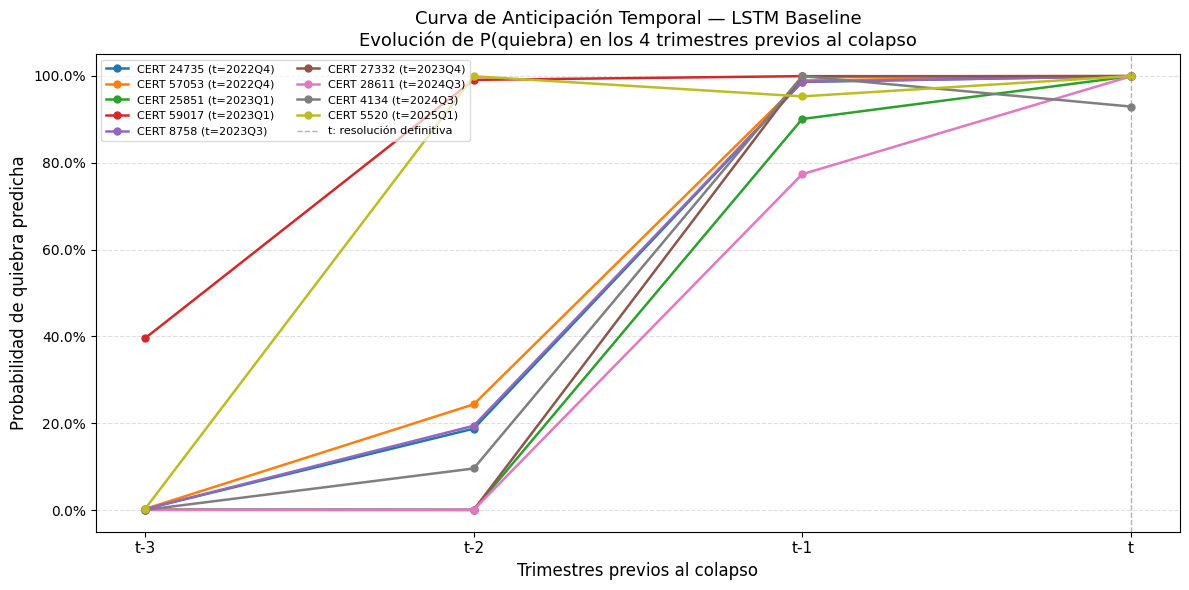

Figura guardada en: C:/dev/tfm-financial_risk/notebooks/figures/anticipation_fullcurve_baseline.png


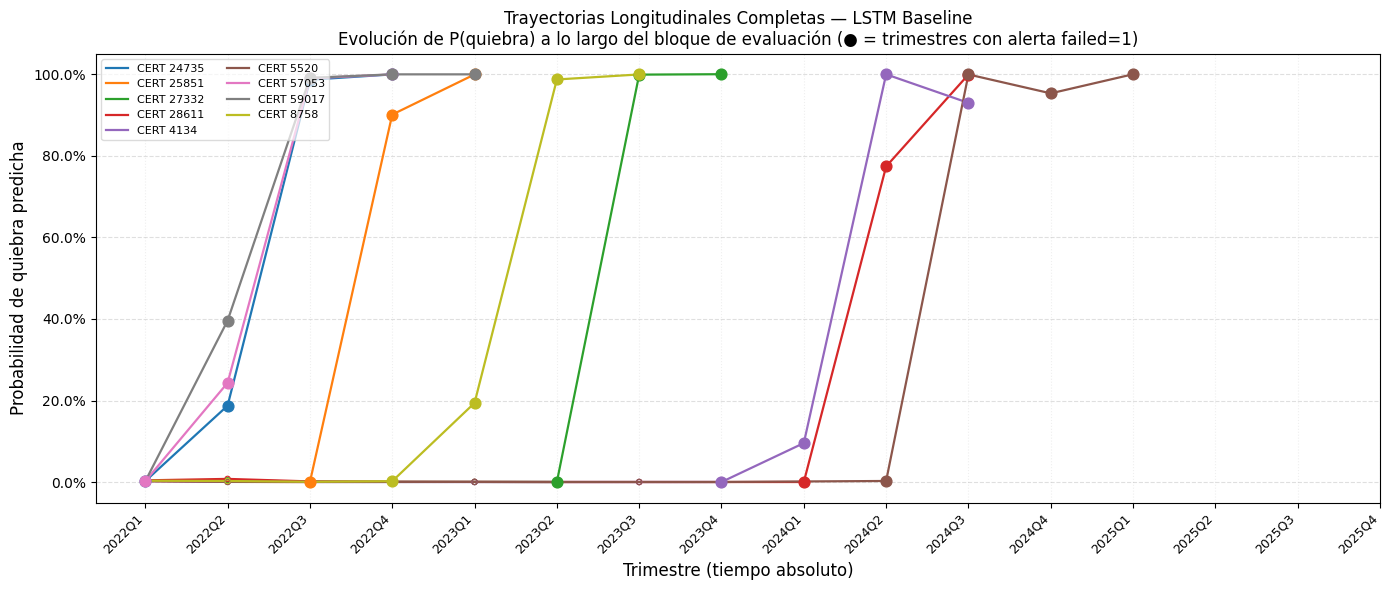

In [98]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import  build_anticipation_trajectories, plot_anticipation_curve, plot_full_trajectories


df_traj = build_anticipation_trajectories(df_preds, window=4)

plot_anticipation_curve(
    df_traj,
    window=4,
    model_label="LSTM Baseline",
    save_path="C:/dev/tfm-financial_risk/notebooks/figures/anticipation_curve_baseline.png",
) 


plot_full_trajectories(
    df_preds,
    model_label="LSTM Baseline",
    save_path="C:/dev/tfm-financial_risk/notebooks/figures/anticipation_fullcurve_baseline.png",
)

__Curva de Anticipación Temporal y Trayectorias Longitudinales_
_
Antes de interpretar las visualizaciones de anticipación, es imperativo precisar la naturaleza empírica de la etiqueta `failed` empleada como variable objetivo. En los registros de la FDIC, la resolución de una entidad bancaria no constituye un evento estocástico instantáneo, sino la culminación de un proceso de deterioro administrativo y contable prolongado durante varios trimestres. Durante este periodo, el regulador acumula evidencias de insolvencia hasta ejecutar la intervención definitiva. En consecuencia, la etiqueta `failed=1` opera en la práctica como una bandera de alerta regulatoria propagada, susceptible de activarse en múltiples trimestres consecutivos para una misma entidad.

Esta dinámica implica que el último trimestre en que un certificado (CERT) figura como `failed=1` dentro del bloque de evaluación no puede equipararse de forma unívoca con el trimestre de quiebra terminal. Dicho hito puede corresponder a la resolución real del proceso, a una fusión o absorción, o bien a un efecto de censura por la derecha derivado del límite temporal del panel (la entidad carece de trimestres posteriores suficientes para conformar una nueva ventana temporal de longitud 4).

La desambiguación de estos escenarios requiere constatar la persistencia o desaparición del nodo en un grafo relacional, análisis que vertebra la arquitectura del modelo Híbrido posterior. Por consiguiente, a lo largo de esta sección se adopta el rigor terminológico de referirse a este hito como el último trimestre de alerta regulatoria registrado en el panel, descartando la asunción de un trimestre de colapso real.

__Curva de Anticipación Temporal__

La _Curva de Anticipación Temporal_ ilustra, para cada una de las 9 entidades únicas con al menos una alerta failed=1 en el bloque de evaluación, la evolución de la probabilidad de quiebra estimada por el ensamble LSTM en los cuatro trimestres que preceden e incluyen su último periodo de alerta: $P(t-3), P(t-2), P(t-1), P(t)$. El eje temporal, de carácter relativo, neutraliza la heterogeneidad cronológica de los colapsos, habilitando la comparabilidad directa de las trayectorias bajo un marco de referencia homogeneizado.La descomposición de estas curvas revela tres perfiles de riesgo cualitativamente diferenciados, con implicaciones directas para la operatividad macroprudencial:

Deterioro inercial o escalada gradual (2 trimestres de ventaja): Los CERTs 24735, 57053 y 8758 describen una progresión cuasi-exponencial. Partiendo de probabilidades basales en $t-3$ ($P \approx 0.002$), transitan hacia una señal de alerta temprana en $t-2$ ($P \in [0.19, 0.24]$), para consolidar una certeza estadística en $t-1$ y $t$ ($P > 0.986$). Este patrón dota al supervisor de un margen temporal de seis meses, lapso suficiente para desplegar auditorías preventivas antes del punto de no retorno.

Colapso abrupto o sobrevenido (1 trimestre de ventaja): Los CERTs 25851 y 27332 permanecen indetectables en las ventanas $t-3$ y $t-2$ ($P < 0.001$), irrumpiendo con probabilidades críticas de $0.90$ y $0.999$ en $t-1$. Este comportamiento define la frontera operativa del modelo ante colapsos de naturaleza idiosincrática o shocks de liquidez súbitos, donde la sintomatología no deja un rastro histórico acumulable en los fundamentales tabulares.

Detección ultra-temprana (2–3 trimestres de ventaja): Los CERTs 59017 y 5520 evidencian la máxima capacidad anticipatoria del sistema. El CERT 59017 registra una señal sustancial de $0.396$ en $t-3$, consolidando el $> 99\%$ desde $t-2$. Globalmente, la mediana de anticipación sobre las 9 entidades se establece en dos trimestres, garantizando una ventana de reacción regulatoria estándar de entre 6 y 9 meses.

__Trayectorias Longitudinales en Tiempo Absoluto__

Como instrumento de diagnóstico complementario, las Trayectorias Longitudinales en Tiempo Absoluto mapean la evolución ininterrumpida de la predicción a lo largo del calendario real (2022Q1–2025Q4). A diferencia de la curva de anticipación, la preservación del eje cronológico absoluto optimiza la legibilidad para el analista de riesgos. La distinción visual entre los periodos latentes y los trimestres bajo alerta regulatoria (failed=1) expone de forma panorámica la transición desde la estabilidad aparente hasta la consolidación del colapso.

Conclusión evaluativa: El modelo como sistema de alerta temprana inercialLa triangulación analítica de ambas visualizaciones y la matriz de rankings consolida una conclusión metodológica fundamental sobre el ensamble LSTM. Los desfases detectados en las métricas agregadas estáticas —específicamente la caída del hit rate a inicios de 2022 y los falsos negativos en la primera iteración predictiva de cada entidad— no obedecen a un déficit en la capacidad de discriminación del algoritmo. Constituyen, por el contrario, un peaje estructural derivado del sesgo de inicialización inercial de la red neuronal.Cuando la ventana deslizante del modelo asimila información exenta del contexto histórico previo al shock macroeconómico, su precisión es taxativa: sitúa a las entidades fallidas en los percentiles de máximo riesgo (rangos 1 a 3) con probabilidades sistemáticamente superiores al $92.9\%$. El aparente fallo inicial es, operativamente, un retardo temporal de adaptación mientras el modelo reconstruye la memoria a corto plazo en un nuevo entorno económico.Esta evidencia ratifica que la red no concibe el riesgo como una clasificación binaria aislada, sino como un proceso temporal. Lejos de constituir una deficiencia, esta característica maximiza su valor como herramienta de supervisión: al trazar la inercia descendente de los fundamentales con antelación probada, el sistema cumple de forma estricta su propósito como mecanismo de alerta temprana predictiva.

\subsection{Hit-Rate@K Trimestral como Sistema de Soporte a la Decisión Macroprudencial}

\subsubsection{Marco conceptual: del clasificador estático al DSS operativo}

El \textit{Hit-Rate@K} trimestral no debe interpretarse exclusivamente como una métrica de clasificación binaria convencional, sino como la medida de utilidad instrumental de un Sistema de Soporte a la Decisión (DSS, por sus siglas en inglés) orientado a la supervisión macroprudencial. Esta distinción epistemológica es fundamental para contextualizar tanto el diseño de la métrica como la lectura analítica de sus resultados.

Un inspector de la FDIC o de cualquier otra autoridad monetaria que incorpora este sistema en su praxis diaria no opera sobre series históricas consolidadas a toro pasado: interactúa en tiempo presente con una perspectiva transversal contemporánea del riesgo del sistema bancario en el trimestre en curso. Su interrogante prioritario no es conceptual (``¿en qué fecha exacta se decretó la quiebra jurídica de esta entidad?``), sino operativo (``¿sobre qué $K$ entidades debo concentrar mis recursos limitados de inspección durante este periodo?``). El valor del modelo reside, por tanto, en su capacidad para cribar un censo de aproximadamente 4.600 entidades activas y devolver una lista corta, jerarquizada y accionable de máximo riesgo, maximizando la densidad de instituciones bajo alerta regulatoria real en las primeras posiciones del ordenamiento.

\subsubsection{Justificación del denominador: la etiqueta propagada como criterio operativo legítimo}

Una particularidad metodológica relevante de la variable \textit{failed} es que, en los registros de la FDIC, opera como una bandera de alerta regulatoria susceptible de propagarse durante varios trimestres consecutivos para una misma entidad. Esto refleja la inercia del propio proceso administrativo de deterioro, intervención y resolución. Esta propiedad indexatoria podría interpretarse, bajo una óptica estadística puramente estática, como una fuente de sesgo debido a la presencia de autocorrelación temporal, ya que una misma institución contribuye al denominador del \textit{Hit-Rate@K} en múltiples periodos mientras la alerta permanezca activa.

Sin embargo, desde la perspectiva de la utilidad del DSS, este comportamiento es óptimo desde un punto de vista operacional por tres razones fundamentales:

\paragraph{La dimensión temporal de la supervisión activa.} Un supervisor que accede al sistema en un trimestre específico (e.g., 2023Q2) requiere un vector de riesgo vigente y exhaustivo para ese periodo, con independencia de si una entidad ya había sido indexada en un informe previo. El modelo que mantiene de forma persistente a una institución en el \textit{Top-K} mientras sus fundamentales continúen degradados no incurre en redundancia analítica; constata que la señal de estrés financiero no se ha disipado y que la entidad exige una monitorización continuada. Un sistema que omitiera deliberadamente a una entidad en periodos ulteriores bajo el pretexto de una ``detección temprana previa'' resultaría operativamente ineficaz para la gestión de riesgos en tiempo real.

\paragraph{Prevalencia de la utilidad operativa sobre el rigor formal del evento.} En el plano de la inspección de campo, una bandera de irregularidad persistente y un colapso inminente son realidades equivalentes a efectos de la asignación táctica de recursos: ambas situaciones exigen la movilización prioritaria de equipos de auditoría. Evaluar el \textit{Hit-Rate@K} contra la etiqueta propagada mide con precisión el rendimiento del modelo como filtro de ruido macroprudencial. De un censo masivo de entidades activas, el sistema aísla un subconjunto compacto en el que se concentran las anomalías financieras reales de ese periodo exacto. Esta capacidad de triaje define el éxito de un DSS, desvinculándolo de la necesidad de certificar el desenlace jurídico terminal de la quiebra.

\paragraph{La categorización del desenlace como un problema de segunda capa.} La desambiguación analítica entre una insolvencia terminal, una reestructuración forzosa o una absorción voluntaria de mercado no constituye una información crítica para la activación inicial del protocolo de inspección; su relevancia aflora en una fase posterior, cuando el regulador debe determinar la estrategia de resolución idónea una vez intervenida la entidad. Esta segunda capa de decisión analítica requiere examinar las mutaciones topológicas del sistema, verificando si el nodo de la entidad desaparece de la red o si sus aristas relacionales cambian de naturaleza tras la resolución. Por consiguiente, este análisis se desplaza fuera del alcance del \textit{baseline} tabular, quedando reservado como la hipótesis fundamental del modelo Híbrido basado en \textit{embeddings} relacionales.

\subsubsection{Sinergia con la Curva de Anticipación Temporal}

La complementariedad analítica entre el \textit{Hit-Rate@K} y la \textit{Curva de Anticipación Temporal} delimita un marco de validación bidimensional. Por un lado, el \textit{Hit-Rate@K} cuantifica la utilidad transversal del DSS en cada corte cronológico, determinando la precisión con la que el sistema prioriza las alertas regulatorias activas en la agenda del supervisor de forma síncrona. Por otro lado, la \textit{Curva de Anticipación Temporal} evalúa la dimensión diacrónica del modelo, estimando con cuántos trimestres de antelación respecto al último registro de visibilidad de la entidad el algoritmo ya había parametrizado la trayectoria de deterioro. 

Ambas métricas se refuerzan mutuamente: mientras la primera acredita la robustez y el valor práctico del sistema en el despliegue operativo rutinario, la segunda demuestra que dicha capacidad predictiva no es un fenómeno reactivo de última hora, sino el resultado de una captura inercial anticipatoria que otorga al regulador una ventana de intervención estratégica real antes de que el deterioro alcance su punto de resolución definitivo.

Como analisis complementario, aunque no enfocado al resultado final por lo que se ha comentado antes, hacemos uns estudio del Hit-Rate@K Trimestral pero con una modificación. En la versión original, cada trimestre cuenta como positivos todas las entidades con failed=1 ese trimestre, lo que incluye bancos cuya bandera lleva varios trimestres propagada. En la versión nueva, cada CERT contribuye al denominador exactamente una vez, en el trimestre de su primera activación de la bandera, que es el momento más próximo al onset real del proceso de deterioro. El numerador sigue siendo si esa entidad, en ese trimestre de primera activación, estaba dentro del top-K del ranking del modelo.

v2 es un análisis de sensibilidad complementario de capacidad de detección temprana en onset. La métrica operativa del DSS es la medida v1 como métrica principal  y tenemos v2 mencionada como perspectiva adicional. 

In [79]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import hit_rate_at_k_trimestral, hit_rate_at_k_trimestral_v2

# Versión original — documentación del proceso
hr_v1 = hit_rate_at_k_trimestral(df_preds, k_values=[5, 10])

# Versión corregida — métrica definitiva para la memoria
hr_v2 = hit_rate_at_k_trimestral_v2(df_preds, k_values=[5, 10])

# Comparación agregada
for k in [5, 10]:
    print(f"K={k}  |  v1: {hr_v1[k]['macro_avg']:.4f}  |  v2: {hr_v2[k]['macro_avg']:.4f}")


HIT-RATE@5 TRIMESTRAL
Trimestres con quiebras reales  : 13
Trimestres sin quiebras reales   : 3  (excluidos del macro-promedio)
Hit-Rate@5 (macro-promedio)    : 0.5910
period_end  n_active  n_failed  n_hits  hit_rate
    2022Q1      4853         2       0  0.000000
    2022Q2      4826         3       0  0.000000
    2022Q3      4799         4       3  0.750000
    2022Q4      4759         5       3  0.600000
    2023Q1      4731         3       2  0.666667
    2023Q2      4705         2       1  0.500000
    2023Q3      4675         2       2  1.000000
    2023Q4      4648         2       1  0.500000
    2024Q1      4631         2       0  0.000000
    2024Q2      4606         3       2  0.666667
    2024Q3      4584         3       3  1.000000
    2024Q4      4552         1       1  1.000000
    2025Q1      4526         1       1  1.000000

HIT-RATE@10 TRIMESTRAL
Trimestres con quiebras reales  : 13
Trimestres sin quiebras reales   : 3  (excluidos del macro-promedio)
Hit-Rate@10 (ma

\subsubsection{Análisis de Ruptura Estructural: El Colapso del Enfoque Onset (v2)}

Para someter a estrés la hipótesis de la inercia secuencial de la red LSTM, se ejecutó una contra-prueba experimental consistente en el cálculo del \textit{Onset Hit-Rate@K} (versión v2). Esta métrica restringe el cómputo del rendimiento exclusivamente al trimestre de la primera activación de la alerta regulatoria ($t_i^{\text{onset}}$), aislando la capacidad del modelo para reaccionar ante la irrupción inicial del deterioro financiero.

Los resultados empíricos revelan un colapso absoluto de la métrica, registrando un macro-promedio de $0.0000$ tanto para $K=5$ como para $K=10$ a lo largo de los 8 trimestres con eventos de \textit{onset} registrados. Lejos de dictaminar una invalidez del algoritmo, este cero estructural constituye confirmación experimental directa del efecto retardo (\textit{lag}) derivado del diseño secuencial de la arquitectura.

En el trimestre de \textit{onset}, la ventana de contexto del LSTM ($T=4$) está compuesta por tres pasos temporales de estabilidad financiera --- los trimestres anteriores a la primera activación de la bandera --- y únicamente un paso con señal de deterioro incipiente. Dado que el estado oculto de la red integra información de toda la ventana mediante sus puertas de control aprendidas, la señal de un único paso anómalo resulta insuficiente para desplazar a la entidad hacia los percentiles superiores del ranking trimestral, manteniéndola en posiciones profundas (rangos~$>1000$) muy por fuera de los umbrales operativos del DSS ($K \in \{5, 10\}$). La probabilidad de captura en el trimestre exacto de disrupción es, en consecuencia, empíricamente nula en el bloque de evaluación analizado.

Este hallazgo tiene dos implicaciones metodológicas de alcance para la arquitectura global de la investigación:

\begin{enumerate}
    \item \textbf{Inviabilidad del enfoque de clasificación puntual en onset.} Se ratifica que evaluar el sistema como un clasificador de inicios de quiebra desvirtúa su naturaleza algorítmica. El ensamble LSTM solo es operativamente defendible bajo el enfoque v1, actuando como un DSS longitudinal que acompaña y refina la señal de riesgo a lo largo del tiempo real de supervisión, no como un detector de discontinuidades instantáneas.

    \item \textbf{Justificación de la transición arquitectónica hacia el modelo Híbrido.} El techo operativo del $0.0\%$ en la detección del \textit{onset} delimita la frontera estructural del modelo secuencial tabular puro: la información contable histórica de la propia entidad, por sí sola, no es suficiente para generar señal en el trimestre de primera disrupción. Superar esta limitación exige incorporar información exógena al histórico individual de la entidad. Este hallazgo justifica formalmente la segunda contribución de este trabajo: el desarrollo del modelo Híbrido con embeddings relacionales. La inclusión de un grafo de interconexiones entre entidades permitirá que la señal de estrés se propague topológicamente a través de los nodos vecinos, aportando contexto sistémico en el trimestre de origen y habilitando, en hipótesis, la detección temprana en el momento exacto del \textit{onset}.
\end{enumerate}

# Fundamentos Metodológicos de Interpretabilidad: El Valor de Shapley (SHAP)

\subsubsection{Marco Teórico de la Teoría de Juegos Cooperativos}

El framework SHAP (\textit{SHapley Additive exPlanations}) no constituye un método heurístico o \textit{ad hoc} diseñado para redes neuronales, sino la transposición rigurosa de un concepto clásico de la teoría de juegos cooperativos al problema de la atribución de importancia de variables (\textit{feature importance}).En este contexto, el proceso de predicción de una instancia concreta se modela como un juego cooperativo donde el universo de características de entrada, denotado por $F$, representa el conjunto de jugadores. El objetivo radica en distribuir equitativamente el "premio" (la desviación de la predicción individual respecto al valor esperado global) entre los jugadores (características).Formalmente, el valor de Shapley de una característica $i$ mide su contribución marginal promediada ponderadamente sobre todas las coaliciones posibles de variables que excluyen a dicha característica:\begin{equation}\phi_i(f, x) = \sum_{S \subseteq F \setminus {i}} \frac{|S|! \cdot (|F| - |S| - 1)!}{|F|!} \left[ v(S \cup {i}) - v(S) \right]\end{equation}Donde:\begin{itemize}\item $S$ es un subconjunto (coalición) de características que excluye a la variable $i$.\item $v(S)$ representa la función de característica, que equivale a la predicción esperada del modelo cuando solo se dispone de la información contenida en $S$, marginalizando las variables ausentes sobre su distribución condicional o marginal.\item El factor combinatorio $\frac{|S|! \cdot (|F| - |S| - 1)!}{|F|!}$ determina la probabilidad ponderada de que la característica $i$ se incorpore a la coalición $S$ dentro de todas las permutaciones posibles del conjunto $F$.\end{itemize}\subsubsection{Propiedades Fundamentales y Axiomática de Shapley}La elección de los valores de Shapley como mecanismo de atribución no es arbitraria; constituye el único estimador distributivo que satisface simultáneamente cuatro axiomas fundamentales, garantizando la consistencia matemática del sistema de interpretabilidad:

\begin{enumerate}\item \textbf{Eficiencia:} La suma de los valores de Shapley de todas las características replica con exactitud matemática la diferencia entre la predicción local del modelo para la muestra $x$ y el valor esperado o predicción media global del dataset:\begin{equation}\sum_{i \in F} \phi_i = f(x) - \mathbb{E}[f(X)]\end{equation}

\item \textbf{Simetría:} Si dos características distintas aportan exactamente la misma contribución marginal a todas las coaliciones posibles de variables ($v(S \cup \{i\}) = v(S \cup \{j\})$), sus valores de Shapley asociados serán idénticos ($\phi_i = \phi_j$), con independencia de su índice u orden de indexación.

\item \textbf{Nulidad (\textit{Dummy}):} Aquella característica que no altere la contribución marginal de ninguna de las coaliciones posibles ($v(S \cup \{i\}) - v(S) = 0, \, \forall S$) recibirá un valor de Shapley estrictamente igual a cero ($\phi_i = 0$).

\item \textbf{Aditividad:} Para un modelo configurado como un ensamble aditivo de funciones del tipo $f = f_1 + f_2$, el valor de Shapley de una característica en $f$ equivale a la suma directa de sus valores de Shapley en cada sub-modelo componente ($\phi_i(f) = \phi_i(f_1) + \phi_i(f_2)$). 

Esta propiedad posee una relevancia metodológica crucial en esta investigación: dado que nuestro sistema opera como un ensamble promediado de tres redes LSTM independientes, el axioma de aditividad valida científicamente el cómputo desagregado de los valores SHAP para cada red y su posterior promediado aritmético para caracterizar el comportamiento global del ensamble.

\end{enumerate}

\subsubsection{El Problema de la Intractabilidad Computacional y Estrategias de Aproximación}

A pesar de su solidez axiomática, el cálculo exacto de la ecuación (1) exige evaluar la función de característica $v(S)$ para los $2^{|F|}$ subconjuntos posibles del espacio de entrada. En la arquitectura recurrente propuesta, el vector de características posee una cardinalidad de $|F| = 768$ (derivado de la interacción de 4 pasos temporales u \textit{horizontes} por las 192 dimensiones del espacio de \textit{embeddings} tabulares). Consecuentemente, el espacio muestral asciende a $2^{768}$ combinaciones, una dimensión astronómica que resulta inabordable mediante computación convencional.Para salvar este obstáculo, la literatura científica articula el ecosistema SHAP en torno a cuatro familias de aproximaciones algorítmicas, penalizando marginalmente la exactitud a favor de la viabilidad computacional:

- KernelSHAP es agnóstico al modelo: aproxima los valores de Shapley ajustando una regresión lineal ponderada sobre muestras de coaliciones. El peso de cada coalición en la regresión reproduce la distribución que generaría el promedio de Shapley exacto. Es el más flexible pero el más lento cuando ∣F∣ es grande. 

- PermutationSHAP también es agnóstico al modelo: en vez de explorar coaliciones aleatorias, genera permutaciones aleatorias de las features y calcula contribuciones marginales en cada permutación. Más eficiente que KernelSHAP para features de alta dimensión.

- DeepSHAP es específico para redes neuronales PyTorch/TensorFlow: combina el algoritmo DeepLIFT (que backpropaga diferencias de activación respecto a una referencia a través de la red) con el framework SHAP para garantizar la propiedad de eficiencia. Es mucho más rápido que los métodos agnósticos porque aprovecha el grafo computacional de la red.

- GradientSHAP es una variante de DeepSHAP que usa gradientes esperados: toma muestras del trayecto entre la referencia y la entrada, calcula gradientes en cada punto, y promedia. Es más robusto que DeepSHAP ante discontinuidades en las activaciones.

\subsection{Desafíos Metodológicos Específicos de la Interpretabilidad en Arquitecturas Híbridas (LSTM + TabPFN)}

La aplicación del ecosistema SHAP sobre el ensamble recurrente de esta investigación no constituye un despliegue directo o trivial de librerías estándar. La naturaleza híbrida del modelo —que alimenta una red LSTM con vectores latentes generados previamente por un modelo transformador tabular (TabPFN)— introduce tres distorsiones estructurales que exigen decisiones de diseño metodológico propias y una reformulación conceptual de lo que significa "atribución de importancia".

\subsubsection{1. Opacidad Semántica del Espacio Latente de Entrada}

Por construcción, el tensor de entrada que recibe la red LSTM en cada evaluación posee una geometría de $(T \times d_{\text{in}}) = (4 \times 192)$, lo que se traduce en un espacio total de $|F| = 768$ características para el estimador SHAP. Sin embargo, estas 192 dimensiones por paso temporal carecen de una correspondencia unívoca con ratios financieros interpretables (como el ratio de apalancamiento, ROE o liquidez). Se trata, en su lugar, de las coordenadas vectoriales de un \textit{embedding} latente proyectado por TabPFN en su espacio de representación interno.

Asignar un valor de Shapley abstracto a la ``dimensión 47 del embedding en el paso $t-2$'' no posee ninguna utilidad clínica ni semántica para un inspector regulatorio. Esta limitación restringe drásticamente la granularidad del análisis: la interpretabilidad local no puede descender al nivel de la variable contable original, sino que debe operar mediante una estrategia de agregación. Consiguientemente, para extraer valor macroprudencial, los valores SHAP deben consolidarse vectorialmente por paso temporal para aislar el peso relativo del vector cronológico, asumiendo la opacidad intrínseca de sus componentes.

\subsubsection{2. El Efecto Telescópico del Contexto In-Context Learning (ICL)}

La interpretación cronológica estándar de una red LSTM asume que el paso temporal $t-k$ codifica exclusivamente la información correspondiente al estado del sistema en dicho periodo. No obstante, en esta arquitectura, cada vector de entrada $e_{\text{tab}}(t)$ encapsula de forma nativa un histórico inercial derivado del mecanismo de \textit{In-Context Learning} (ICL) intrínseco de TabPFN, el cual evalúa una ventana deslizante de cuatro trimestres previos de la propia entidad.

Cuando la red LSTM procesa la secuencia ordenada de vectores latentes:

\begin{equation}
    X_i = \left[ e_{\text{tab}}(t-3), \, e_{\text{tab}}(t-2), \, e_{\text{tab}}(t-1), \, e_{\text{tab}}(t) \right]
\end{equation}

Se produce un \textbf{efecto telescópico o de superposición temporal}. El nodo correspondiente al paso $t-3$ dentro de la secuencia de la LSTM no computa únicamente la realidad financiera del trimestre $t-3$; arrastra en su interior la síntesis latente del intervalo comprendido entre $t-7$ y $t-3$. Por lo tanto, cualquier atribución de importancia que el estimador SHAP adjudique al paso $t-3$ no mide el impacto aislado de ese trimestre en la probabilidad de insolvencia, sino la relevancia del sumario predictivo que TabPFN confeccionó sobre el ciclo inercial precedente. Esta distorsión estructural debe ser explicitada para evitar conclusiones diacrónicas erróneas en la diagnosis del riesgo.

\subsubsection{3. Sensibilidad a la Calibración del Dataset de Referencia (\textit{Background})}

La estimación práctica de la expectativa de predicción marginalizada, denotada por $\mathbb{E}[f(X)]$, requiere la selección de un dataset de referencia o \textit{background dataset} que actúe como el estado basal o ``punto cero'' a partir del cual se descompone aditivamente cada predicción individual. La determinación de este conjunto de referencia no es metodológicamente neutra y altera el significado ontológico de los valores SHAP resultantes:

\begin{itemize}
    \item \textbf{Configuración Exclusiva de Negativos:} Si el \textit{background} se compone estrictamente de instituciones sanas ($failed = 0$), el valor esperado define el comportamiento de un ``banco promedio estable''. Los valores de Shapley resultantes medirán el esfuerzo de las características para empujar a la entidad fuera de la normalidad sectorial hacia la zona de intervención.
    \item \textbf{Configuración Estratificada Global:} Si se incorpora una muestra representativa y estratificada que incluya tanto entidades sanas como alertas activas ($failed \in \{0, 1\}$), la base de comparación muta hacia la distribución real del panel. Las contribuciones marginales reflejarán la varianza de la muestra analizada respecto al ruido general del sistema.
\end{itemize}

Dado que esta elección modifica los valores numéricos absolutos de $\phi_i$ sin alterar el cumplimiento de la propiedad de eficiencia, la selección del \textit{background} debe alinearse estrictamente con los objetivos del Sistema de Soporte a la Decisión (DSS).

\subsection{Estrategia de Interpretabilidad Bidimensional: Caracterización Global y Diagnóstico Local}

Para sortear la opacidad semántica de las 192 dimensiones del \textit{embedding} latente y extraer conclusiones con valor regulatorio, esta investigación descarta el análisis aislado de características individuales y adopta una estrategia de \textbf{agregación temporal bimodal}. Los valores SHAP calculados se proyectan en dos dimensiones analíticas complementarias —global y local— estructuradas de forma jerárquica en la memoria.

\subsubsection{1. Análisis Global: Caracterización Arquitectónica del Ensamble}

El análisis global opera sobre la totalidad del bloque de evaluación, procesando el censo completo de secuencias activas ($N = 74.231$). Para cada una de estas instancias, se computa el valor absoluto de los coeficientes de Shapley y se ejecuta un colapso vectorial (\textit{temporal pooling}) sumando las atribuciones de las 192 dimensiones internas para cada paso temporal. Formalmente, la importancia global generalizada de un \textit{timestep} $k$ (donde $k \in \{t-3, t-2, t-1, t\}$) se define como el macro-promedio:

\begin{equation}
\bar{\Phi}_{k} = \frac{1}{N} \sum_{n=1}^{N} \sum_{j=1}^{192} \left| \phi_{(k, j)}^{(n)} \right|
\end{equation}

Esta métrica responde a una interrogante fundamental de diseño: \textit{¿en qué posición de la ventana secuencial de la LSTM se concentra la densidad de la señal discriminativa del modelo en promedio sobre el tejido bancario sano?}. 

Bajo la hipótesis inercial de las redes recurrentes, se proyecta un gradiente monótonamente creciente donde el paso contemporáneo $t$ monopolice la mayor importancia, atenuándose hacia el pasado remoto ($t-3$). Sin embargo, la verificación empírica de esta distribución permite auditar si el algoritmo explota sesgos reactivos de última hora o si, por el contrario, distribuye el peso en los pasos intermedios ($t-1$ o $t-2$), lo que denotaría la captura de dinámicas de aceleración previas al desenlace formal.

\subsubsection{2. Análisis Local: Diagnóstico Clínico de las Trayectorias de Insolvencia}

En contraposición al sesgo de promediado del enfoque global —donde el $99.9\%$ de muestras sanas diluye las firmas anómalas—, el análisis local se focaliza de forma estricta en el subconjunto crítico de las 33 secuencias positivas correspondientes a las trayectorias de deterioro de los 9 bancos fallidos únicos. 

En esta capa, el pooling temporal preserva el signo algebraico original de la contribución marginal para trazar la polaridad del empuje:

\begin{equation}
\Phi_{k}^{(n)} = \sum_{j=1}^{192} \phi_{(k, j)}^{(n)}
\end{equation}

El objetivo de este enfoque clínico consiste en monitorizar cómo transmuta dinámicamente el mecanismo de ponderación interna de la LSTM a medida que una institución específica fluye longitudinalmente a través del calendario hacia su punto de resolución administrativa. 

Este análisis posee el mayor valor narrativo macroprudencial. Si en las fases tempranas del deterioro (e.g., tres trimestres antes del colapso), el estimador local revela que el modelo desplaza de forma anómala el peso hacia los componentes más recientes de la ventana respecto a la norma global, se constata que la señal sintética generada por TabPFN ha adquirido una dominancia local proactiva. Este enfoque asocia una justificación causal de caja abierta (el ``¿por qué?'') a las curvas de probabilidad cronológica y los puestos de \textit{ranking} analizados con anterioridad.

\subsubsection{Sinergia Metodológica}

Ambas dimensiones se despliegan de forma consecutiva para dotar a la evaluación de un cierre robusto. El análisis global actúa como la línea base o validación estructural de la red, certificando que el procesamiento secuencial del ensamble es coherente con la teoría económica general. Una vez fijada esta ontología, el análisis local interviene como el bisturí diagnóstico, demostrando la sensibilidad del DSS ante los casos de estrés extremo que justifican la existencia operativa del sistema de supervisión.

In [80]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


\subsubsection{Garantías de Determinismo en el Grafo Computacional: El Impacto de .eval()}

El cálculo de atribuciones mediante metodologías basadas en gradientes exige la estabilidad absoluta del grafo computacional de la red neuronal. Por esta razón, la invocación del método \texttt{load\_ensemble} fuerza de manera explícita la transición de los tres submodelos componentes al modo de evaluación (\texttt{.eval()}). 

Desde una perspectiva operativa, esta instrucción no altera los tensores de pesos sinápticos —fijados de forma definitiva tras la convergencia del entrenamiento mediante \texttt{load\_state\_dict}—, sino que modifica los operadores estocásticos de la arquitectura, específicamente las capas de \textit{dropout}. 

En la fase de optimización, el \textit{dropout} actúa como un regularizador activo desactivando aleatoriamente neuronas con una probabilidad preconfigurada $p$. Si el estimador SHAP operase bajo este régimen de entrenamiento, el grafo de flujo de datos mutaría de forma probabilística en cada evaluación backward, transformando los gradientes calculados en variables aleatorias latentes y destruyendo la reproducibilidad de las explicaciones. 

Al transicionar al modo \texttt{.eval()}, las capas de \textit{dropout} quedan desactivadas y actúan como meras funciones de identidad lineal que permiten el paso íntegro de las activaciones. Esta transformación confiere un carácter estrictamente determinista al grafo de PyTorch, garantizando que el cómputo de gradientes intermedios sea unánime y reproducible en cualquier réplica experimental.

\subsubsection{Justificación Algorítmica: Idoneidad de GradientSHAP frente a Enfoques Agnósticos}

La implementación práctica de la interpretabilidad post-hoc plantea una dicotomía entre metodologías agnósticas y específicas de arquitectura. Esta investigación justifica la selección de \textit{GradientSHAP} basándose en restricciones de coste computacional y explotación del grafo diferenciable de la red:

\begin{itemize}
    \item \textbf{Limitaciones de los Métodos Black-Box (KernelSHAP / PermutationSHAP):} Los enfoques agnósticos evalúan el modelo como una caja negra inaccesible. Para aproximar los coeficientes de Shapley, requieren perturbar masivamente el vector de entrada y computar miles de \textit{forward passes} por cada instancia. Ante un bloque de evaluación compuesto por $74.231$ secuencias y un espacio de características de $|F| = 768$, este enfoque derivaría en una explosión combinatoria inabordable bajo infraestructura convencional.
    \item \textbf{Ventajas Operativas de GradientSHAP:} Al tratarse de un ensamble recurrente implementado en PyTorch, el modelo es intrínsecamente diferenciable. \textit{GradientSHAP} capitaliza esta propiedad inyectando el algoritmo directamente en el grafo computacional. En lugar de muestrear permutaciones externas, computa el gradiente de la salida respecto a las variables de entrada, evaluado sobre trayectorias interpoladas linealmente entre las muestras reales y el dataset de referencia (\textit{background dataset}). Este mecanismo reduce drásticamente el coste computacional a operaciones de diferenciación automática nativas, haciendo viable el procesamiento del censo completo del panel.
\end{itemize}

\subsubsection{Mecanismo de Atribución y Agregación Temporal del Vector Latente}

El despliegue de SHAP no altera el comportamiento del ensamble ni reconfigura sus predicciones; interviene como una capa analítica de diagnóstico post-hoc. El proceso de inferencia estándar genera una probabilidad escalar de insolvencia a partir de un tensor de entrada; el framework SHAP recorre en sentido inverso la senda de activación para desglosar qué subconjunto del vector de entrada asumió la responsabilidad causal de dicha probabilidad.

Dado que la entrada posee una geometría de $(4 \times 192)$, el estimador asigna inicialmente un valor de Shapley a cada una de las 768 coordenadas abstractas. Para disipar la opacidad semántica de las 192 dimensiones del \textit{embedding} de TabPFN, se aplica un colapso por agregación absoluta a nivel de \textit{timestep}:

\begin{equation}
\Phi_{t-k} = \sum_{j=1}^{192} \left| \phi_{(t-k, j)} \right|
\end{equation}

Esta agregación reconduce el análisis hacia una escala interpretable por el supervisor regulatorio, respondiendo a la pregunta estratégica central: \textit{cuando el modelo proyecta un incremento severo del riesgo en una entidad, ¿la alerta responde a un shock financiero estrictamente contemporáneo (paso $t$) o está incorporando y ponderando la señal inercial latente de los trimestres precedentes (pasos $t-1, t-2, t-3$)?}. Este marco conecta directamente el motor causal interno de la LSTM con las trayectorias de anticipación temporal identificadas previamente en la evaluación cuantitativa.

\paragraph{Diferenciación de Modelos: Superioridad de GradientSHAP frente a DeepSHAP en Arquitecturas Recurrentes}

Dentro de la familia de estimadores basados en gradientes, la selección de \textit{GradientSHAP} frente a la alternativa nativa \textit{DeepSHAP} responde a una restricción teórica crítica impuesta por la topología de las redes recurrentes:

\begin{itemize}
    \item \textbf{El Conflicto de DeepSHAP con las Operaciones Multiplicativas:} El algoritmo \textit{DeepSHAP} se fundamenta en el framework \textit{DeepLIFT}, el cual propaga las diferencias de activación con respecto al \textit{background} de forma lineal, neurona por neurona, hacia atrás en la red. Si bien este mecanismo es altamente eficiente en arquitecturas de alimentación directa (\textit{feedforward}), exhibe patologías teóricas documentadas al enfrentarse a unidades LSTM. Las celdas de memoria de una LSTM basan su dinámica de control en operaciones estrictamente multiplicativas a través de sus puertas (\textit{gates} de entrada, olvido y salida). Al no estar diseñado \textit{DeepLIFT} para linealizar de forma canónica estos productos de activación, la propia librería de referencia introduce advertencias explícitas sobre la pérdida de precisión matemática al aplicar este operador sobre redes recurrentes.
    \item \textbf{La Robustez Teórica de GradientSHAP:} Por el contrario, \textit{GradientSHAP} implementa una generalización del método de Gradientes Integrados (\textit{Integrated Gradients}) extendida a una distribución de referencia. Su mecanismo clave consiste en trazar trayectorias de interpolación aleatoria entre el vector de entrada real $x$ y el dataset de \textit{background}, computando el gradiente local en cada punto intermedio del camino para finalmente promediarlos. Al basarse en la integración continua de gradientes a lo largo de un espacio continuo, el estimador es intrínsecamente robusto ante la presencia de no-linealidades severas y discontinuidades en el grafo, digiriendo de forma exacta las interacciones multiplicativas de las puertas recurrentes. Esto lo consolida como la aproximación basada en gradientes más fiable para el análisis de LSTMs.
\end{itemize}

El único peaje operativo asociado a \textit{GradientSHAP} es la introducción de varianza estocástica, dado que la precisión del estimador depende directamente de la calidad del muestreo en las trayectorias de interpolación. Para mitigar este riesgo y garantizar el determinismo absoluto del bloque de evaluación, esta investigación neutraliza dicha varianza mediante dos salvaguardas experimentales: la fijación estricta de una semilla de aleatoriedad (\textit{random seed}) en el backend de PyTorch y la parametrización de un número de muestras de interpolación lo suficientemente elevado como para asegurar la convergencia asintótica de los valores de Shapley calculados.

Todo el codigo referente al modulo de interpretabilidad lo almacenamos en el archivo `src/evaluation/interpretability.py`. El desglose teorico de este archivo es el siguiente:

__El Núcleo de Computación `compute_gradient_shap`__

Esta función actúa como el motor matemático del módulo. Su objetivo es resolver el problema de la atribución de características: cuantificar la responsabilidad exacta que cada una de las 768 posiciones de la entrada (4 timesteps $\times$ 192 dimensiones) tiene en el logit de riesgo final predicho por el ensamble. Por decisiones de arquitectura y modulos empleados, se descarta `DeepSHAP` debido a las limitaciones de su algoritmo subyacente (`DeepLIFT`) ante operadores multiplicativos. Una celda `LSTM` regula el flujo de información mediante compuertas (gates) que ejecutan productos elemento a elemento:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

Donde $\odot$ representa el producto de Hadamard. Estos cruzamientos multiplicativos rompen las reglas de asignación lineal de `DeepLIFT`. Para solucionarlo, GradientSHAP recurre a la integración de gradientes combinada con una distribución de referencia (background). Conceptualmente, es una aproximación muestral de los Gradientes Integrados (Integrated Gradients). La ecuación fundamental que calcula el valor SHAP ($\phi$) de la característica $i$ para un input $x$ frente a un valor de referencia $x'$ es:

$$
\phi_i(x) = (x_i - x'_i) \times \int_{0}^{1} \frac{\partial f(x' + \alpha(x - x'))}{\partial x_i} d\alpha
$$

Dado que calcular la integral analítica en una red profunda es imposible, la función ejecuta una aproximación de Riemann mediante Montecarlo. Muestrea de forma estocástica $\alpha \sim U(0,1)$ y selecciona instancias del background para aproximar la expectativa matemática a través de $S$ interpolaciones lineales (n_samples):

$$
\phi_i(x) \approx \frac{1}{M} \sum_{j=1}^M (x_i - x'_{j,i}) \times \frac{1}{S} \sum_{k=1}^S \nabla_{x_i} f(x'_{j} + \alpha_k (x - x'_{j}))
$$

- A nivel de ingenieria de software, tenemos que la fijación del interruptor `.eval()` garantiza que el grafo computacional de PyTorch devuelva un gradiente determinista $\nabla_x f(x)$. Si las capas de dropout permanecieran activas, el grafo mutaría probabilísticamente en cada pasada hacia atrás (backward pass), inyectando ruido en el cálculo del gradiente y destruyendo la consistencia de los valores de Shapley.

- Operación en el Espacio de Logits: La función extrae la salida directa de la capa lineal del modelo, ignorando cualquier activación sigmoide externa. Esto purifica la matemática de SHAP por dos razones: evitas la saturación del gradiente (donde predicciones muy seguras devuelven derivadas cercanas a cero, $\sigma'(z) \to 0$, ocultando la verdadera importancia de las variables) y garantizas una aditividad exacta en la escala log-odds.

- Axioma de Aditividad en el Ensamble: El código itera sobre los tres modelos, calcula sus matrices SHAP independientes y ejecuta un promedio de los tensores resultantes:

$$
\Phi_{\text{ens}}(x) = \frac{1}{3} \sum_{k=1}^3 \Phi_{k}(x)
$$

Esto se fundamenta estrictamente en el Axioma de Aditividad de Shapley, el cual demuestra que si un juego se compone de la suma lineal de múltiples subjuegos, los valores de Shapley del juego global son formalmente la suma (o media, si está ponderada) de los valores de Shapley de los subjuegos.


__Reducción de Dimensiones: `aggregate_shap_by_timestep`__

El tensor de salida de la función anterior posee una geometría de $(N \times 4 \times 192)$. Las 192 dimensiones individuales son embeddings latentes generados por TabPFN. Carecen de significado económico u operativo directo; representan la posición de la entidad en un espacio geométrico de riesgo abstracto. La granularidad con utilidad macroprudencial radica en el paso temporal (el trimestre).Para resolver esta opacidad semántica, la función colapsa la tercera dimensión (las 192 características) aplicando una agregación matemática diferenciada según el objetivo analítico:

- Análisis Global (`absolute=True`): Para comprender el comportamiento genérico de la arquitectura ante la población bancaria, se requiere medir la masa neta de importancia, independientemente de si la señal empuja hacia la insolvencia o hacia la estabilidad. La función computa la norma $L_1$ espacial:

$$
\Phi_{t-k}^{\text{global}} = \sum_{j=1}^{192} \left| \phi_{(t-k, j)} \right|
$$

- Análisis Local (`absolute=False`): Para diagnosticar las 33 secuencias de quiebra real, la magnitud pura no es suficiente; necesitamos conocer la polaridad causal. El código desactiva el valor absoluto y calcula la suma algebraica:

$$
\Phi_{t-k}^{\text{local}} = \sum_{j=1}^{192} \phi_{(t-k, j)}
$$

Al preservar el signo, un resultado neto positivo implica una fuerza que incrementa el logit (desplazando al banco hacia la zona de alerta de quiebra), mientras que un valor negativo representa un colchón financiero o inercia saludable que reduce el riesgo estimado.

Las decisiones de parametrización introducidas en el módulo responden al rigor estadístico y a la viabilidad computacional:

- Composición del Dataset de Referencia (Background): Se seleccionan exclusivamente 100 secuencias sanas (failed=0) provenientes del bloque de entrenamiento. Usar el bloque de entrenamiento previene que se de el caso de data leakage (filtración de datos), manteniendo el marco de referencia aislado de la evaluación. Solo empleamos secuencias sanas, debido a que en la teoría de Shapley, el background establece el "punto de neutralidad" o el valor esperado $E[f(X)]$. Al forzar que la normalidad del sistema esté compuesta únicamente por instituciones estables, los valores `SHAP` medirán de forma pura la fuerza patológica que desvía a una entidad desde la salud financiera hacia la insolvencia. Usamos 100 muestras ya que es el estándar empírico de la literatura. Proporciona una base estadística suficiente para aproximar las expectativas del gradiente sin saturar la memoria ni ralentizar el cómputo.

- Realizamos un submuestreo para el análisis global ($n = 2.000$), ya que evaluar las 74.231 secuencias originales del panel completo exigiría computar $74.231 \times 100 \times 50 \times 3 \approx 1,11 \times 10^9$ pasos de gradiente. Extraer una muestra aleatoria simple de 2.000 observaciones resuelve este cuello de botella. Mediante el Teorema del Límite Central, una muestra de $n = 2.000$ sobre una población de $N = 74.231$ garantiza un margen de error inferior al 2,2% bajo un nivel de confianza del 95%. 

> __Demostración:__ El Teorema del Límite Central establece que, para un tamaño de muestra suficientemente grande ($n \ge 30$), la distribución muestral de la proporción se aproxima a una distribución normal. Para garantizar que el margen de error sea un límite máximo, nos situamos bajo el supuesto de máxima indeterminación o máxima varianza poblacional. El margen de error ($E$) absoluto para un nivel de confianza del $1-\alpha$, en un muestreo aleatorio simple sobre una población finita, se define mediante la siguiente ecuación:
>
> $$E = Z_{\alpha/2} \cdot \sqrt{\frac{p(1-p)}{n}} \cdot \sqrt{\frac{N-n}{N-1}}$$
> 
> Donde $Z_{\alpha/2}$ es el valor crítico de la distribución Normal Estándar para el nivel de confianza deseado, $\sqrt{\frac{p(1-p)}{n}}$: El error estándar de la proporción asumiendo una población infinita, $\sqrt{\frac{N-n}{N-1}}$ es el Factor de Corrección por Población Finita (FCPF), necesario porque la muestra supone una fracción significativa de la población total (el muestreo es sin reemplazo). Tomando un nivel de confianza del $95\%$, tenemos que $ \alpha = 0.05 \implies Z_{0.025} \approx 1.96$, la varianza maxima es de $p(1-p) = 0.5 \cdot 0.5 = 0.25$. Por tanto el ensamblaje del margen de error es:
>
> $$E = Z_{0.025} \cdot \sqrt{\frac{0.25}{2000}} \cdot \sqrt{\frac{74231 - 2000}{74231 - 1}}\approx 0.021616$$
>
> Dado que $2.16\% < 2.20\%$, queda demostrado que una muestra de $2.000$ observaciones sobre el panel de $74.231$ secuencias limita la incertidumbre de la estimación por debajo del $2,2\%$ al $95\%$ de confianza. 

La caracterización global resultante es estadísticamente equivalente a la del censo completo.

__Unificación y Visualización: `build_shap_summary` y `plot_shap_timestep_importance`__

Las dos últimas etapas transforman las matrices numéricas abstractas en artefactos legibles y listos para la toma de decisiones regulatorias. 

- `build_shap_summary` (Alineación Estructural): Actúa como el nexo de unión entre el espacio matemático de `SHAP` y el espacio de supervisión bancaria. Construye un DataFrame unificando los valores reducidos por timestep con los metadatos de identificación externa (`CERT y period_end`). Esto convierte la salida en una estructura tabular que preserva la trazabilidad de cada banco.

- `plot_shap_timestep_importance` (Dualidad Gráfica): La función altera su comportamiento visual de forma inteligente según el parámetro `subset`:

Modo Global: Genera un gráfico de barras (Barplot) a partir de las medias poblacionales de $\Phi^{\text{global}}$. Su propósito es puramente estructural: demuestra de manera agregada qué posición de la ventana temporal (desde $t-3$ hasta $t$) concentra la mayor densidad de señal predictiva.

Modo Local: Implementa un gráfico de líneas temporales (Lineplot) enfocado en las 33 secuencias críticas de quiebra. Agrupa los datos por el identificador del banco (CERT), calcula la trayectoria media con signo ($\Phi^{\text{local}}$) y dibuja la evolución cronológica del impacto causal frente a una línea horizontal de referencia en cero. Permite al supervisor realizar un diagnóstico forense individualizado, visualizando si el modelo detectó la insolvencia como un shock repentino en el último trimestre ($t$) o como un deterioro crónico acumulado a lo largo de la serie temporal.

Hagamos un test unitario para verificar que el modulo funcióna. Si pasa el test, lo usaremos con los datos reales para realizar la fase de interpretabilidad.

In [88]:
%run "c:/dev/tfm-financial_risk/tests/test_gradient_shap.py"

PRUEBA 1: ¿GradientExplainer acepta input 3D sin romper?
OK: GradientExplainer construido sin error.
OK: shap_values() no lanzó excepción.

PRUEBA 2: ¿La forma del output es (N, 4, 192) sin lista envolvente?
Tipo devuelto: <class 'numpy.ndarray'>
  -> Array directo, forma: (5, 4, 192, 1)
Forma esperada: (5, 4, 192) | Forma obtenida: (5, 4, 192, 1) | MISMATCH

PRUEBA 3: ¿Valores sensatos? (NaN, ceros, aditividad aproximada)
¿Contiene NaN?: False
¿Todo cero?: False

Chequeo de aditividad (por muestra):
  logit real   reconstruido   diff abs


TypeError: unsupported format string passed to numpy.ndarray.__format__

La línea responsable es `shap/explainers/_gradient.py:546`:
```python
selected = [val for val in outputs[:, idx]]
``` 
`shap` asume que el output del modelo es 2D: (batch, n_clases_o_salidas), y selecciona la columna idx correspondiente a la salida que quiere explicar. Tu LSTMBaseline.forward devuelve logits de forma (batch,) — 1D, porque hace .squeeze(-1) al final. Por eso outputs[:, idx] falla con IndexError: too many indices for tensor of dimension 1: no hay una segunda dimensión que indexar.
Esto es independiente de si el input es 3D o no — el input 3D sí lo aceptó sin problema (Prueba 1 superada en la parte de construcción). El problema es el output del modelo, no el input.
La solución no es modificar LSTMBaseline, ya que eso alteraria toda la estructura de nuestro pipeline,  alterado el grafo, arriesgando la compatibilidad con los checkpoints ya entrenados y obligándote a arrastrar un parche de formato por todo el pipeline de inferencia general. La solución ideal es emplear un `Patrón Wrapper` (o `Decorador`), de forma que se envuelve el modelo en un wrapper minúsculo que le devuelva a `shap` el "capricho" bidimensional exclusivamente dentro del módulo de interpretabilidad, manteniendo intacta la pureza de tu arquitectura.la forma que espera, sin afectar a los checkpoints ni al entrenamiento:
```python
class LSTMBaselineSHAPWrapper(nn.Module):
    """
    Envuelve LSTMBaseline únicamente para satisfacer la convención de shape
    2D (batch, 1) que GradientExplainer espera del output del modelo.
    No reentrena ni modifica los pesos: delega el forward íntegro al modelo
    original y solo añade una dimensión final.
    """
    def __init__(self, base_model: nn.Module):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        logits = self.base_model(x)       # (batch,)
        return logits.unsqueeze(-1)        # (batch, 1)
``` 

Este wrapper se tiene que incluir tanto en el test unitario para que lo pase como en el archivo de interpretabilidad, para no tener el problema de dimensionalidad tambien cuando lo usemos con los datos reales. Surge la pregunta de si usar este wrapper modificaria la salida del SHAP o alteraria algo, pero no es asi, ya que el wrapper no altera los pesos del modelo, ni las activaciones, ni las operaciones de la LSTM. Lo único que hace es ejecutar .unsqueeze(-1) sobre el resultado final. En matemáticas y en tensores, añadir una dimensión de tamaño 1 no cambia el valor del número, es decri si el logit real de un banco era 2.45 (un escalar dentro de un vector de 1D), con el wrapper, el logit pasa a ser [2.45] (un vector de un solo elemento en una matriz 2D). El valor numérico que va a leer SHAP para calcular las derivadas es exactamente 2.45. Las pendientes, los gradientes y, por ende, los valores SHAP finales que obtendrás serán iguales. En `PyTorch`, la función `.unsqueeze()` (al igual que `.view()` o `.reshape()`) es una operación extremadamente eficiente. Cuando haces `.unsqueeze(-1)`, `PyTorch` no duplica los datos en la memoria RAM ni en la GPU, ni tampoco realiza ninguna operación matemática (FLOP). Lo único que hace es modificar los metadatos del tensor (el puntero que le dice a Python cómo leer esa matriz).

En los logs si vemos `is_list = True`, no es un síntoma de alarma, sino un punto positivo, ya que esto significa que el wrapper hizo su trabajo engañando a SHAP para que viera un espacio bidimensional (batch, 1), y SHAP, fiel a su API, devolvió una lista indexada por clases (de longitud 1).

Los problemas de MISMATCH de la Prueba 2 y el TypeError de la Prueba 3, de deben a:

- El origen de la dimensión fantasma (5, 4, 192, 1): Al darle a SHAP una salida bidimensional (batch, 1) gracias al wrapper, algunas versiones de shap.GradientExplainer para PyTorch prefieren devolver un único array de 4 dimensiones en lugar de una lista de arrays. La estructura que genera es (batch, timesteps, features, salidas_del_modelo). Como solo tienes 1 salida, te añade un , 1 colgado al final.

- El error de formato en la Prueba 3: Como el array tiene esa dimensión extra, cuando el script calcula la suma de SHAP values (phi_sum), el resultado hereda esa dimensión y se queda con forma (5, 1) en lugar de ser un vector plano de (5,). Al llegar al bucle for, reconstructed[i] no es un número flotante puro, sino un micro-array de Numpy (array([valor])). Python no sabe cómo aplicar el formato :12.4f a un objeto array y por eso lanza el TypeError.

Para solucionar ambos problemas, que son conjuntos tenemos que aplicar un `.squeeze(-1)` cuando detectemos que el output final de SHAP trae esa dimensión unitaria colgando al final. Esto corregirá la forma a la (5, 4, 192) esperada y transformará los datos en escalares puros, matando los dos fallos a la vez. En el test unitario tenemos que añadir el `.squeeze(-1)` justo después del bloque `if/else`. Para que tu pipeline de producción quede blindado contra esto, añade la misma doble salvaguarda (tanto para listas como para dimensiones ..., 1) dentro del bucle de batches de la función `compute_gradient_shap`:
```python
for start in range(0, n, batch_size):
            batch = inputs[start: start + batch_size]
            batch_shap = explainer.shap_values(batch, nsamples=n_samples)
            
            # Salvaguarda 1: Por si devuelve lista de arrays
            if isinstance(batch_shap, list):
                batch_shap = batch_shap[0]
                
            # Salvaguarda 2: Por si devuelve array 4D con dimensión final unitaria
            if isinstance(batch_shap, np.ndarray) and batch_shap.shape[-1] == 1:
                batch_shap = batch_shap.squeeze(-1)
                
            model_shap.append(batch_shap)
``` 

In [90]:
%run "c:/dev/tfm-financial_risk/tests/test_gradient_shap.py"

PRUEBA 1: ¿GradientExplainer acepta input 3D sin romper?
OK: GradientExplainer construido sin error.
OK: shap_values() no lanzó excepción.

PRUEBA 2: ¿La forma del output es (N, 4, 192) sin lista envolvente?
Tipo devuelto: <class 'numpy.ndarray'>
  -> Array directo, forma: (5, 4, 192, 1)
Forma esperada: (5, 4, 192) | Forma obtenida: (5, 4, 192) | OK

PRUEBA 3: ¿Valores sensatos? (NaN, ceros, aditividad aproximada)
¿Contiene NaN?: False
¿Todo cero?: False

Chequeo de aditividad (por muestra):
  logit real   reconstruido   diff abs
     -0.0186        -0.0004     0.0182
     -0.0981        -0.0912     0.0069
     -0.0699        -0.0659     0.0040
     -0.1428        -0.1387     0.0041
      0.0057        -0.0018     0.0075

Diferencia media absoluta: 0.0081
Diferencia máxima absoluta: 0.0182
(GradientSHAP es una aproximación estocástica: se espera diferencia
 pequeña pero no nula. Si la diferencia es grande o errática, subir
 nsamples y repetir antes de confiar en los resultados.)

RESUM

Con el test superado, ahora podemos pasar a ejecutar el analisis de interpretabilidad de `GradientSHAP`. El estudio lo hacemos en 4 etapas diferente:

__Bloque 1 — Construcción de inputs (build_shap_inputs)__

Separa tres conjuntos de secuencias con fines distintos: el background (100 secuencias sanas del bloque de entrenamiento, que representan la "normalidad financiera" que el modelo aprendió y sirven de referencia para medir desviaciones); la muestra global (2.000 secuencias aleatorias del bloque de evaluación, estadísticamente representativas de todo el panel, usadas para conclusiones agregadas); y la muestra local (las 33 secuencias positivas íntegras, el subconjunto de interés regulatorio que no se submuestrea porque es pequeño y crítico).

__Bloque 2 — SHAP global (compute_gradient_shap + aggregate_shap_by_timestep con absolute=True)__

Calcula, para cada una de las 2.000 secuencias, la contribución de cada trimestre (t-3, t-2, t-1, t) al logit de quiebra, promediando los 3 modelos del ensamble (axioma de aditividad). Al agregar en valor absoluto, la pregunta que responde es poblacional: en promedio sobre todo el panel, qué posición temporal concentra más señal discriminativa, sin importar si empuja hacia quiebra o hacia salud.

__Bloque 3 — SHAP local (mismo cálculo, absolute=False)__

Repite el cálculo solo sobre las 33 secuencias que terminan en quiebra, pero conservando el signo. Aquí la pregunta es individual y direccional: para cada banco que efectivamente quebró, qué trimestre concretamente empujó la predicción hacia el colapso (+) y cuál, si alguno, la contuvo (-). Es la base para las trayectorias por CERT.

__Bloque 4 — Visualización__

El gráfico global es un barplot de una sola barra por timestep (importancia media |φ|), de lectura agregada. El gráfico local es una línea por CERT con signo preservado, de lectura comparativa entre casos individuales — permite ver si todos los bancos colapsan por el mismo patrón temporal o si hay heterogeneidad.

In [94]:
if "src.evaluation.interpretability" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.interpretability"])

from src.evaluation.interpretability import (
    build_shap_inputs,
    compute_gradient_shap,
    aggregate_shap_by_timestep,
    build_shap_summary,
    plot_shap_timestep_importance,
)

# ---------------------------------------------------------------------------
# 1. Construir background, muestra global y muestra local

shap_inputs = build_shap_inputs(
    sequences_train=sequences_train,
    sequences_eval=sequences_eval_padding,
    n_background=100,
    n_global_sample=2000,
    seed=42,
    device=device,
)

print(f"Background:      {shap_inputs['background'].shape}")
print(f"Global inputs:    {shap_inputs['global_inputs'].shape}")
print(f"Local inputs:     {shap_inputs['local_inputs'].shape}  (positivos íntegros)")

Background:      torch.Size([100, 4, 192])
Global inputs:    torch.Size([2000, 4, 192])
Local inputs:     torch.Size([33, 4, 192])  (positivos íntegros)


In [96]:
# 2. SHAP values — análisis GLOBAL (2.000 secuencias)

shap_values_global = compute_gradient_shap(
    models=models,
    background=shap_inputs["background"],
    inputs=shap_inputs["global_inputs"],
    n_samples=50,
    batch_size=256,
    seed=42,
)

shap_by_timestep_global = aggregate_shap_by_timestep(shap_values_global, absolute=True)

df_shap_global = build_shap_summary(
    shap_by_timestep=shap_by_timestep_global,
    labels=shap_inputs["global_labels"],
    period_ends=shap_inputs["global_periods"],
    certs=shap_inputs["global_certs"],
    absolute=True,
)


In [95]:
# 3. SHAP values — análisis LOCAL (33 secuencias positivas)

shap_values_local = compute_gradient_shap(
    models=models,
    background=shap_inputs["background"],
    inputs=shap_inputs["local_inputs"],
    n_samples=50,
    batch_size=256,
    seed=42,
)

shap_by_timestep_local = aggregate_shap_by_timestep(shap_values_local, absolute=False)

df_shap_local = build_shap_summary(
    shap_by_timestep=shap_by_timestep_local,
    labels=shap_inputs["local_labels"],
    period_ends=shap_inputs["local_periods"],
    certs=shap_inputs["local_certs"],
    absolute=False,
)

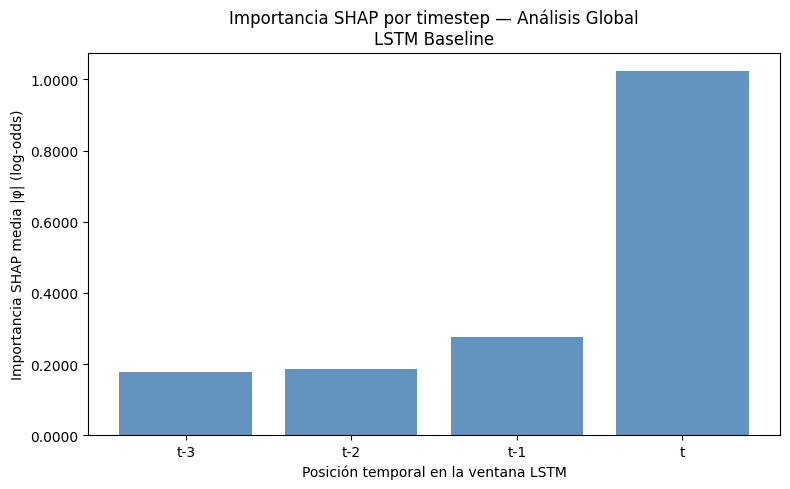

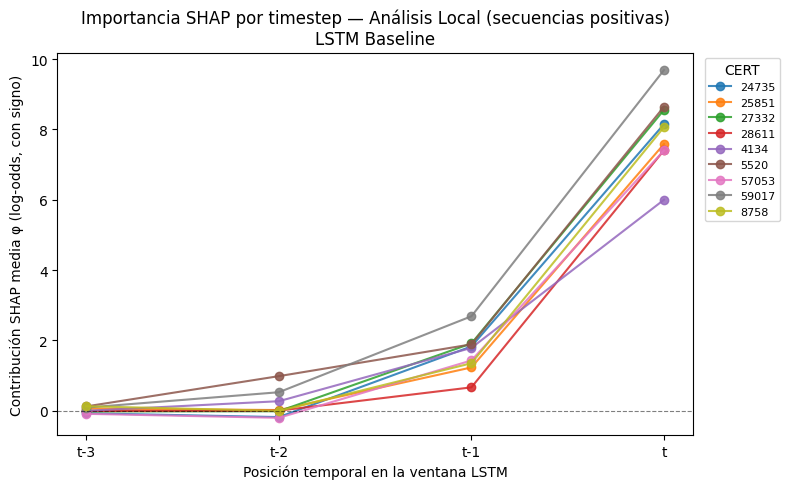

In [97]:
# 4. Visualización

plot_shap_timestep_importance(df_shap_global, subset="global", model_label="LSTM Baseline")
plot_shap_timestep_importance(df_shap_local, subset="local", model_label="LSTM Baseline")

Limitaciones del análisis de interpretabilidad

El análisis de interpretabilidad mediante GradientSHAP se circunscribe deliberadamente a la arquitectura LSTM, que constituye la etapa de inferencia final del pipeline. Dado que el LSTM no recibe las variables financieras originales como entrada, sino su proyección comprimida a través del encoder TabPFN (192 dimensiones latentes por trimestre), la atribución de importancia obtenida mediante SHAP queda acotada a la granularidad temporal —qué posición relativa dentro de la ventana de cuatro trimestres concentra mayor señal discriminativa— sin que sea posible trazar esa importancia hasta variables financieras individuales con significado de negocio.

Esta limitación es estructural y no derivada de un error de implementación: las 192 dimensiones del embedding son representaciones latentes no lineales sin correspondencia directa, ni uno-a-uno ni de fácil interpretación, con los ratios o magnitudes contables de entrada. Cualquier técnica de atribución aplicada al LSTM (GradientSHAP, Integrated Gradients, gradiente simple) hereda esta misma limitación, puesto que todas operan sobre el espacio de entrada del modelo que explican, y ese espacio de entrada es ya el embedding, no los datos crudos.
Recuperar la interpretabilidad a nivel de variable financiera original requeriría, o bien aplicar SHAP sobre TabPFN en un rol de clasificador independiente entrenado directamente sobre las variables crudas de un único trimestre (lo que constituye un análisis distinto, sin la dimensión temporal del modelo secuencial), o bien componer atribuciones a través de ambas etapas del pipeline mediante una metodología no estándar que excede el alcance de este trabajo. Se plantea como línea futura.
